(mmm_brand_metrics_long_term)=
# Long-Term Brand Effects in MMMs with Brand Metrics and a Bayesian VARX

Media mix models are very good at one thing: quantifying the short-term sales response to performance media. They are structurally blind to another: the slow accumulation of demand that brand marketing builds through mindset metrics such as awareness and consideration. Brand campaigns rarely trigger immediate purchases, so when brand spend enters an MMM as a regular channel the model usually reports a relatively low direct effect. The brand-driven demand does not disappear, though. It shows up as a slow drift in *base sales*, which the MMM absorbs into its intercept and never attributes to anything.

This is a measurement failure, not a marketing failure, and it has a well-established remedy in the marketing science literature: model the purchase funnel explicitly and let brand marketing act on sales *through* the brand metrics. In this notebook we implement a two-stage Bayesian workflow to recover the full effect:

1. **Stage 1**: fit a PyMC-Marketing {class}`~pymc_marketing.mmm.mmm.MMM` with a **time-varying intercept** (a Hilbert Space Gaussian Process, as in {ref}`mmm_tv_intercept`). The model recovers the short-term channel contributions as usual, and the evolving intercept becomes an explicit estimate of the *dynamic baseline* where brand effects live.
2. **Stage 2**: extract the baseline and model the system {baseline, awareness, consideration} with a **Bayesian vector autoregression with exogenous inputs (VARX)** using the [impulso](https://github.com/thomaspinder/impulso) package, treating brand spend as the exogenous driver. The VARX's *dynamic multiplier* tells us how a unit of brand spend propagates through the funnel into the baseline, week by week, with full posterior uncertainty.

The total return on brand marketing is then the short-term effect (from the MMM, approximately zero here) plus the long-term effect (from the VARX dynamic multiplier). We work with simulated data so we can validate every estimate against a known ground truth.

The approach follows the purchase-journey framework of Cain (2022), and this notebook is a PyMC-Marketing port of the workflow popularized by Ryan O'Sullivan's post [Capturing the long-term causal effect of brand marketing](https://medium.com/@raz1470/capturing-the-long-term-causal-effect-of-brand-marketing-bc577621a627) and by 1749.io's [Measuring Marketing Effectiveness Over the Long-Term](https://1749.io/learn/f/measuring-marketing-effectiveness-over-the-long-term).

> Cain, P. M. (2022). "Modelling short- and long-term marketing effects in the consumer purchase journey." *International Journal of Research in Marketing*, 39(1), 96-116. [doi:10.1016/j.ijresmar.2021.06.006](https://doi.org/10.1016/j.ijresmar.2021.06.006)

```{note}
How does this notebook relate to its siblings?

- {ref}`mmm_var_budget_optimization` also couples an MMM with an impulso VARX, but for *budget allocation* over fast-moving engagement indicators. Here the VARX is used for *measurement*: quantifying long-term brand effects transmitted through mindset metrics into the MMM baseline.
- {ref}`mmm_tv_intercept` introduces the time-varying intercept machinery we use in Stage 1.
- {ref}`mmm_upper_funnel_causal_approach` and {ref}`mmm_funnel_mueffect` handle funnel mediation *inside* a single nested model. The two-stage approach here trades that elegance for the VARX's explicit treatment of persistence, feedback, and long-run dynamics.
```

## Prepare Notebook

In [1]:
import warnings

import arviz as az
import graphviz as gr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor
import pytensor.tensor as pt
import xarray as xr
from impulso import (
    VAR,
    MinnesotaPrior,
    VARData,
    integration_order,
    johansen_test,
    lag_matrices,
    select_lag_order,
)
from impulso.samplers import NUTSSampler
from pymc import do
from pymc_extras.prior import Prior
from tqdm.notebook import tqdm

from pymc_marketing.hsgp_kwargs import CovFunc, HSGPKwargs
from pymc_marketing.mmm import MMM, GeometricAdstock, LogisticSaturation

warnings.filterwarnings("ignore", category=FutureWarning)

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [12, 7]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = "retina"

seed: int = sum(map(ord, "mmm_brand_metrics_long_term"))

## Business Problem and Causal Structure

Picture a direct-to-consumer brand with three and a half years of weekly data. The marketing team runs two always-on performance channels, `x1` (search-like) and `x2` (social-like), and at irregular intervals it launches eight-week TV brand campaigns, `brand_spend` (four of them over the sample). A weekly brand-tracking survey measures `awareness` and `consideration`. All monetary quantities are expressed in units of \$10k, so any ratio of incremental sales to spend is a unit-free ROI.

Our structural assumptions are summarized in the causal graph below. The performance channels act directly on sales with the usual adstock and saturation dynamics. Brand spend has **no direct edge to sales**: its entire effect flows through the funnel, lifting awareness, which feeds consideration, which drives *base sales* (the non-media demand level). Each funnel variable is persistent, so a brand campaign keeps paying back long after it ends.

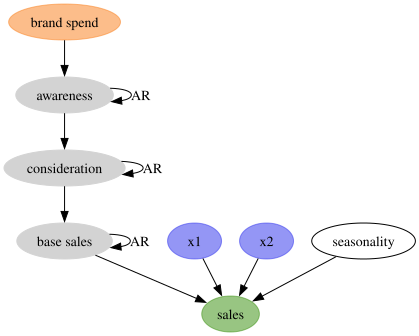

In [2]:
g = gr.Digraph()
g.node("brand spend", color="#fa7c1780", style="filled")
g.node("awareness", color="lightgray", style="filled")
g.node("consideration", color="lightgray", style="filled")
g.node("base sales", color="lightgray", style="filled")
g.node("x1", color="#2a2eec80", style="filled")
g.node("x2", color="#2a2eec80", style="filled")
g.node("seasonality")
g.node("sales", color="#328c0680", style="filled")
g.edge("brand spend", "awareness")
g.edge("awareness", "awareness", label="AR")
g.edge("awareness", "consideration")
g.edge("consideration", "consideration", label="AR")
g.edge("consideration", "base sales")
g.edge("base sales", "base sales", label="AR")
g.edge("base sales", "sales")
g.edge("x1", "sales")
g.edge("x2", "sales")
g.edge("seasonality", "sales")
g

Because there is no direct `brand spend -> sales` edge, a regression of sales on (transformed) brand spend estimates the *direct* short-term effect, which is genuinely zero. The *total* effect is the one the CMO cares about, and it lives on the mediated path. Our measurement strategy therefore has two stages:

| Stage | Model | Inputs | Output |
|---|---|---|---|
| 1 | MMM with time-varying intercept | sales, `x1`, `x2` | short-term contributions + dynamic baseline |
| 2 | Bayesian VARX (impulso) | baseline, `awareness`, `consideration`; `brand_spend` exogenous | dynamic multiplier of brand spend on the baseline |

## Simulate Data with a PyMC Generative Model

We simulate the data with PyMC models, following the pattern of the {ref}`mmm_data_generator` notebook: draw the covariates from a small PyMC model, then build a *generator* MMM on a dummy target, fix its parameters at true values with PyMC's {func}`~pymc.model.transform.conditioning.do` operator, and take a single prior predictive draw as the observed data. Everything downstream can then be validated against the stored ground truth.

We simulate `l_max` extra initial weeks and drop them afterwards, so that adstock carryover and the funnel recursions are properly warmed up.

In [3]:
l_max = 8
n_weeks = 182 + l_max

dates = pd.date_range(start="2021-01-04", periods=n_weeks, freq="W-MON")

coords = {"date": dates}

### Performance media spends

Two correlated, always-on channels drawn from a latent multivariate normal pushed through a softplus (so spends are positive), exactly as in the data generator notebook. The latent scale is chosen so that weekly spend sweeps a wide dynamic range, from near zero to well above the typical level. This is not just cosmetic: a saturation curve is only identifiable if the data visit both its toe and its shoulder, and always-on spend confined to a narrow band produces a ridge between the saturation parameters that no sampler can resolve.

In [4]:
spend_coords = {"date": dates, "channel_dim": ["x1", "x2"]}

spend_mu = np.array([-0.2, -0.9])
spend_sd = np.array([0.9, 1.1])
spend_corr = 0.4
spend_cov = (
    np.diag(spend_sd)
    @ np.array([[1.0, spend_corr], [spend_corr, 1.0]])
    @ np.diag(spend_sd)
)

with pm.Model(coords=spend_coords) as spend_model:
    spend_raw = pm.MvNormal(
        "spend_raw",
        mu=spend_mu,
        cov=spend_cov,
        dims=("date", "channel_dim"),
    )
    spend = pm.Deterministic(
        "spend", pt.softplus(spend_raw), dims=("date", "channel_dim")
    )

spend_draw = pm.draw(spend_model.spend, draws=1, random_seed=seed + 201)
x1, x2 = spend_draw[:, 0], spend_draw[:, 1]

### Brand campaign flights

Brand spend is not drawn from a distribution: it is a *planned* schedule of four eight-week flights. This is deliberate and it matters for Stage 2. Because the flight calendar is set by the marketing team and does not react to weekly demand shocks, brand spend is exogenous to the funnel system, which is exactly the assumption the VARX dynamic multiplier needs to have a causal reading.

The flight start weeks are chosen to be irregular, so that the campaign pattern does not accidentally align with the yearly seasonal cycle (we verify the correlation is negligible below).

In [5]:
flight_starts = [7, 72, 99, 124]

flight_rng = np.random.default_rng(seed + 202)
brand_spend = np.zeros(n_weeks)
for start in flight_starts:
    s = start + l_max
    brand_spend[s : s + 8] = flight_rng.uniform(0.9, 1.1, size=8)

seasonal_proxy = np.sin(2 * np.pi * np.arange(n_weeks) / 52.18)
corr_check = np.corrcoef(brand_spend, seasonal_proxy)[0, 1]
np.testing.assert_array_less(np.abs(corr_check), 0.1)
print(f"corr(brand flights, yearly cycle) = {corr_check:.3f}")

corr(brand flights, yearly cycle) = -0.005


### Brand funnel: awareness, consideration, and base sales

The funnel is a small structural time-series model, written as a PyMC model with a `pytensor.scan` recursion:

$$
\begin{aligned}
a_t &= \mu_a (1 - \rho_a) + \rho_a a_{t-1} + \gamma \, \text{brand}_t + \varepsilon^a_t \\
c_t &= \mu_c (1 - \rho_c) + \rho_c c_{t-1} + \delta \, a_{t-1} + \varepsilon^c_t \\
b_t &= b_0 (1 - \rho_b) + \rho_b b_{t-1} + \beta_c \, c_{t-1} + \varepsilon^b_t
\end{aligned}
$$

where $a$ is awareness, $c$ is consideration, and $b$ is base sales. Each equation is a stable AR(1) fed by the level above it in the funnel, so a brand campaign lifts awareness within the flight, consideration follows with a lag, and base sales drift upward over the following months. The survey we observe adds a little measurement noise on top of the latent awareness and consideration states.

A few parameter choices worth highlighting:

- $\rho_a = 0.90$ gives awareness a half-life of about 6.6 weeks: clearly persistent, but the response is mostly realized within a half-year evaluation window. Values very close to 1 make the long-run effect take years to materialize and are also harder to estimate in a short sample.
- Base sales has its own AR coefficient $\rho_b$ and innovation. This represents sales inertia (habit, repeat purchase) and it also matters statistically: if base sales were a deterministic function of consideration, the Stage-2 system {baseline, awareness, consideration} would be perfectly collinear by construction.

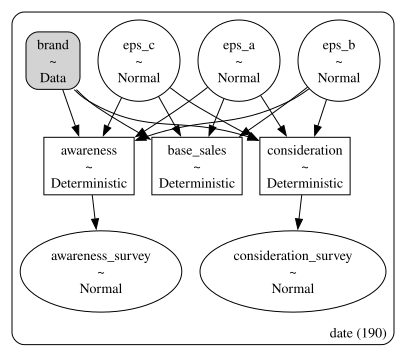

In [6]:
rho_a, gamma, mu_a, sigma_a = 0.90, 0.25, 1.0, 0.04
rho_c, delta, mu_c, sigma_c = 0.80, 0.4, 0.5, 0.03
rho_b, beta_c, base_ss, sigma_b = 0.5, 0.6, 3.5, 0.04
survey_sigma = 0.03

a_ss = mu_a
c_ss = mu_c + delta * a_ss / (1 - rho_c)
b0 = base_ss - beta_c * c_ss / (1 - rho_b)

with pm.Model(coords=coords) as funnel_model:
    brand = pm.Data("brand", brand_spend, dims="date")
    eps_a = pm.Normal("eps_a", mu=0, sigma=sigma_a, dims="date")
    eps_c = pm.Normal("eps_c", mu=0, sigma=sigma_c, dims="date")
    eps_b = pm.Normal("eps_b", mu=0, sigma=sigma_b, dims="date")

    def step(brand_t, ea_t, ec_t, eb_t, a_prev, c_prev, b_prev):
        a_t = mu_a * (1 - rho_a) + rho_a * a_prev + gamma * brand_t + ea_t
        c_t = mu_c * (1 - rho_c) + rho_c * c_prev + delta * a_prev + ec_t
        b_t = b0 * (1 - rho_b) + rho_b * b_prev + beta_c * c_prev + eb_t
        return a_t, c_t, b_t

    (a_seq, c_seq, b_seq) = pytensor.scan(
        fn=step,
        sequences=[brand, eps_a, eps_c, eps_b],
        outputs_info=[
            pt.constant(np.float64(a_ss)),
            pt.constant(np.float64(c_ss)),
            pt.constant(np.float64(base_ss)),
        ],
        return_updates=False,
    )
    awareness = pm.Deterministic("awareness", a_seq, dims="date")
    consideration = pm.Deterministic("consideration", c_seq, dims="date")
    base_sales = pm.Deterministic("base_sales", b_seq, dims="date")

    awareness_survey = pm.Normal(
        "awareness_survey", mu=awareness, sigma=survey_sigma, dims="date"
    )
    consideration_survey = pm.Normal(
        "consideration_survey", mu=consideration, sigma=survey_sigma, dims="date"
    )

pm.model_to_graphviz(funnel_model)

In [7]:
(
    awareness_true,
    consideration_true,
    base_sales_true,
    awareness_obs,
    consideration_obs,
) = pm.draw(
    [
        funnel_model.awareness,
        funnel_model.consideration,
        funnel_model.base_sales,
        funnel_model.awareness_survey,
        funnel_model.consideration_survey,
    ],
    draws=1,
    random_seed=seed + 203,
)

### Sales: a generator MMM with `do` interventions

For the sales equation we reuse the {class}`~pymc_marketing.mmm.mmm.MMM` class itself as the data generator, so the short-term media effects follow exactly the adstock and saturation transformations the model will later estimate. The trick, borrowed from the data generator notebook, is to build the model on a dummy target of ones (which makes the internal max-abs scaling the identity) and then use {func}`pymc.do` to fix every parameter at its true value. Because the generator uses `time_varying_intercept=True`, the `intercept_contribution` variable has a `date` dimension, and we can intervene on it with the *entire true base sales path* from the funnel model above. A single prior predictive draw then produces the observed sales along with the true channel contributions.

In [8]:
intercept_tvp_config = HSGPKwargs(
    m=50, L=None, eta_lam=1.0, ls_mu=5.0, ls_sigma=10.0, cov_func=CovFunc.Matern52
)

mmm_df = pd.DataFrame({"date": dates, "x1": x1, "x2": x2, "y_dummy": np.ones(n_weeks)})

mmm_generator = MMM(
    date_column="date",
    target_column="y_dummy",
    channel_columns=["x1", "x2"],
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config={"intercept_tvp_config": intercept_tvp_config},
)

X_generator = mmm_df.drop(columns=["y_dummy"])
mmm_generator.build_model(X_generator, mmm_df["y_dummy"])
mmm_generator.add_original_scale_contribution_variable(
    var=["channel_contribution", "intercept_contribution", "y"]
)

adstock_alpha_true = np.array([0.4, 0.2])
saturation_beta_true = np.array([1.2, 0.8])
saturation_lam_true = np.array([2.5, 2.0])
gamma_fourier_true = np.array([0.15, -0.1, 0.1, 0.05])
y_sigma_true = 0.12

mmm_generator.model = do(
    mmm_generator.model,
    {
        "intercept_contribution": base_sales_true,
        "adstock_alpha": adstock_alpha_true,
        "saturation_beta": saturation_beta_true,
        "saturation_lam": saturation_lam_true,
        "gamma_fourier": gamma_fourier_true,
        "y_sigma": y_sigma_true,
    },
)

with mmm_generator.model:
    idata_generator = pm.sample_prior_predictive(
        draws=1,
        var_names=[
            "y_original_scale",
            "channel_contribution_original_scale",
            "fourier_contribution",
        ],
        random_seed=seed + 204,
    )

y_obs = idata_generator["prior"]["y_original_scale"].sel(chain=0, draw=0).to_numpy()
channel_contribution_true = (
    idata_generator["prior"]["channel_contribution_original_scale"]
    .sel(chain=0, draw=0)
    .to_numpy()
)
fourier_true = (
    idata_generator["prior"]["fourier_contribution"].sel(chain=0, draw=0).to_numpy()
)

Sampling: [y]


Finally we assemble the observed dataset (what an analyst would actually receive) and a separate truth table (what we keep for validation only), dropping the warm-up weeks.

In [9]:
df = (
    pd.DataFrame(
        {
            "date": dates,
            "x1": x1,
            "x2": x2,
            "brand_spend": brand_spend,
            "awareness": awareness_obs,
            "consideration": consideration_obs,
            "y": y_obs,
        }
    )
    .tail(-l_max)
    .reset_index(drop=True)
)

truth_df = (
    pd.DataFrame(
        {
            "date": dates,
            "base_sales": base_sales_true,
            "awareness_latent": awareness_true,
            "consideration_latent": consideration_true,
            "x1_contribution": channel_contribution_true[:, 0],
            "x2_contribution": channel_contribution_true[:, 1],
            "fourier": fourier_true.sum(axis=-1),
        }
    )
    .tail(-l_max)
    .reset_index(drop=True)
)

n_obs = len(df)

df.head()

,date,x1,x2,brand_spend,awareness,consideration,y
0,2021-03-01,0.333743,0.197446,0.0,0.944166,2.468805,3.923088
1,2021-03-08,0.638024,0.672565,0.0,1.045996,2.486493,4.129321
2,2021-03-15,0.401403,0.401717,0.0,0.968112,2.524318,3.925029
3,2021-03-22,0.556506,1.343426,0.0,1.093235,2.569200,4.405511
4,2021-03-29,0.575361,0.024324,0.0,1.075380,2.558478,4.163135


In [10]:
# The Stage-1 comparison of `saturation_lam` against the generator only holds if
# the max-abs scaling is the same in both. The generator sees the full spend
# series; Stage 1 sees the frame trimmed by `l_max`. They match only if each
# channel's maximum falls outside the warm-up weeks, so we check it explicitly.
np.testing.assert_allclose(
    df[["x1", "x2"]].max().to_numpy(),
    np.array([x1, x2]).max(axis=1),
    err_msg=(
        "trimmed frame max-abs scale differs from the generator; "
        "saturation_lam is no longer directly comparable across the two models"
    ),
)

### Ground truth: the true dynamic multiplier of brand spend

Before fitting anything, let us compute the quantity we will try to recover. Propagating a one-unit, one-week pulse of brand spend through the noise-free funnel recursions gives the true impulse response of base sales, and its cumulative sum is the true *cumulative dynamic multiplier*: the total incremental base sales generated within $h$ weeks per unit of brand spend.

The infinite-horizon limit has a closed form. Because the funnel is linear, the pulse contributes $\gamma \sum_{h \geq 0} \rho_a^h = \gamma / (1 - \rho_a)$ total units of awareness, each unit of awareness contributes $\delta / (1 - \rho_c)$ total units of consideration, and each unit of consideration contributes $\beta_c / (1 - \rho_b)$ total units of base sales. The total long-run effect is the product of these three steady-state gains:

$$
\frac{\gamma}{1-\rho_a} \cdot \frac{\delta}{1-\rho_c} \cdot \frac{\beta_c}{1-\rho_b} = \frac{\beta_c \delta \gamma}{(1-\rho_a)(1-\rho_c)(1-\rho_b)} = \frac{0.6 \times 0.4 \times 0.25}{0.1 \times 0.2 \times 0.5} = 6.0.
$$

We will quote results at a 26-week horizon (27 weekly responses, $h = 0, \dots, 26$, including the impulse week), where about 86% of the long-run effect has been realized. The choice of horizon is an accounting convention, just like a payback window in finance, and it should be stated explicitly in any real analysis.

In [11]:
horizon = 26

impulse_a = np.zeros(horizon + 1)
impulse_c = np.zeros(horizon + 1)
impulse_b = np.zeros(horizon + 1)
impulse_a[0] = gamma

for h in range(1, horizon + 1):
    impulse_a[h] = rho_a * impulse_a[h - 1]
    impulse_c[h] = rho_c * impulse_c[h - 1] + delta * impulse_a[h - 1]
    impulse_b[h] = rho_b * impulse_b[h - 1] + beta_c * impulse_c[h - 1]

true_cum_multiplier = np.cumsum(impulse_b)
true_long_term_roi = true_cum_multiplier[-1]
asymptote = beta_c * delta * gamma / ((1 - rho_a) * (1 - rho_c) * (1 - rho_b))

print(f"true cumulative multiplier at h={horizon}: {true_long_term_roi:.2f}")
print(f"infinite-horizon asymptote: {asymptote:.2f}")
print(f"share realized within {horizon} weeks: {true_long_term_roi / asymptote:.1%}")

true_roi_x1 = truth_df["x1_contribution"].sum() / df["x1"].sum()
true_roi_x2 = truth_df["x2_contribution"].sum() / df["x2"].sum()
print(f"true short-term ROI x1: {true_roi_x1:.2f}, x2: {true_roi_x2:.2f}")

true cumulative multiplier at h=26: 5.15
infinite-horizon asymptote: 6.00
share realized within 26 weeks: 85.9%
true short-term ROI x1: 0.69, x2: 0.29


### A first look at the data

The plots below tell the story we will need to recover statistically: awareness climbs during every flight and decays afterwards, consideration follows more slowly, and sales drift upward on top of the short-term media noise.

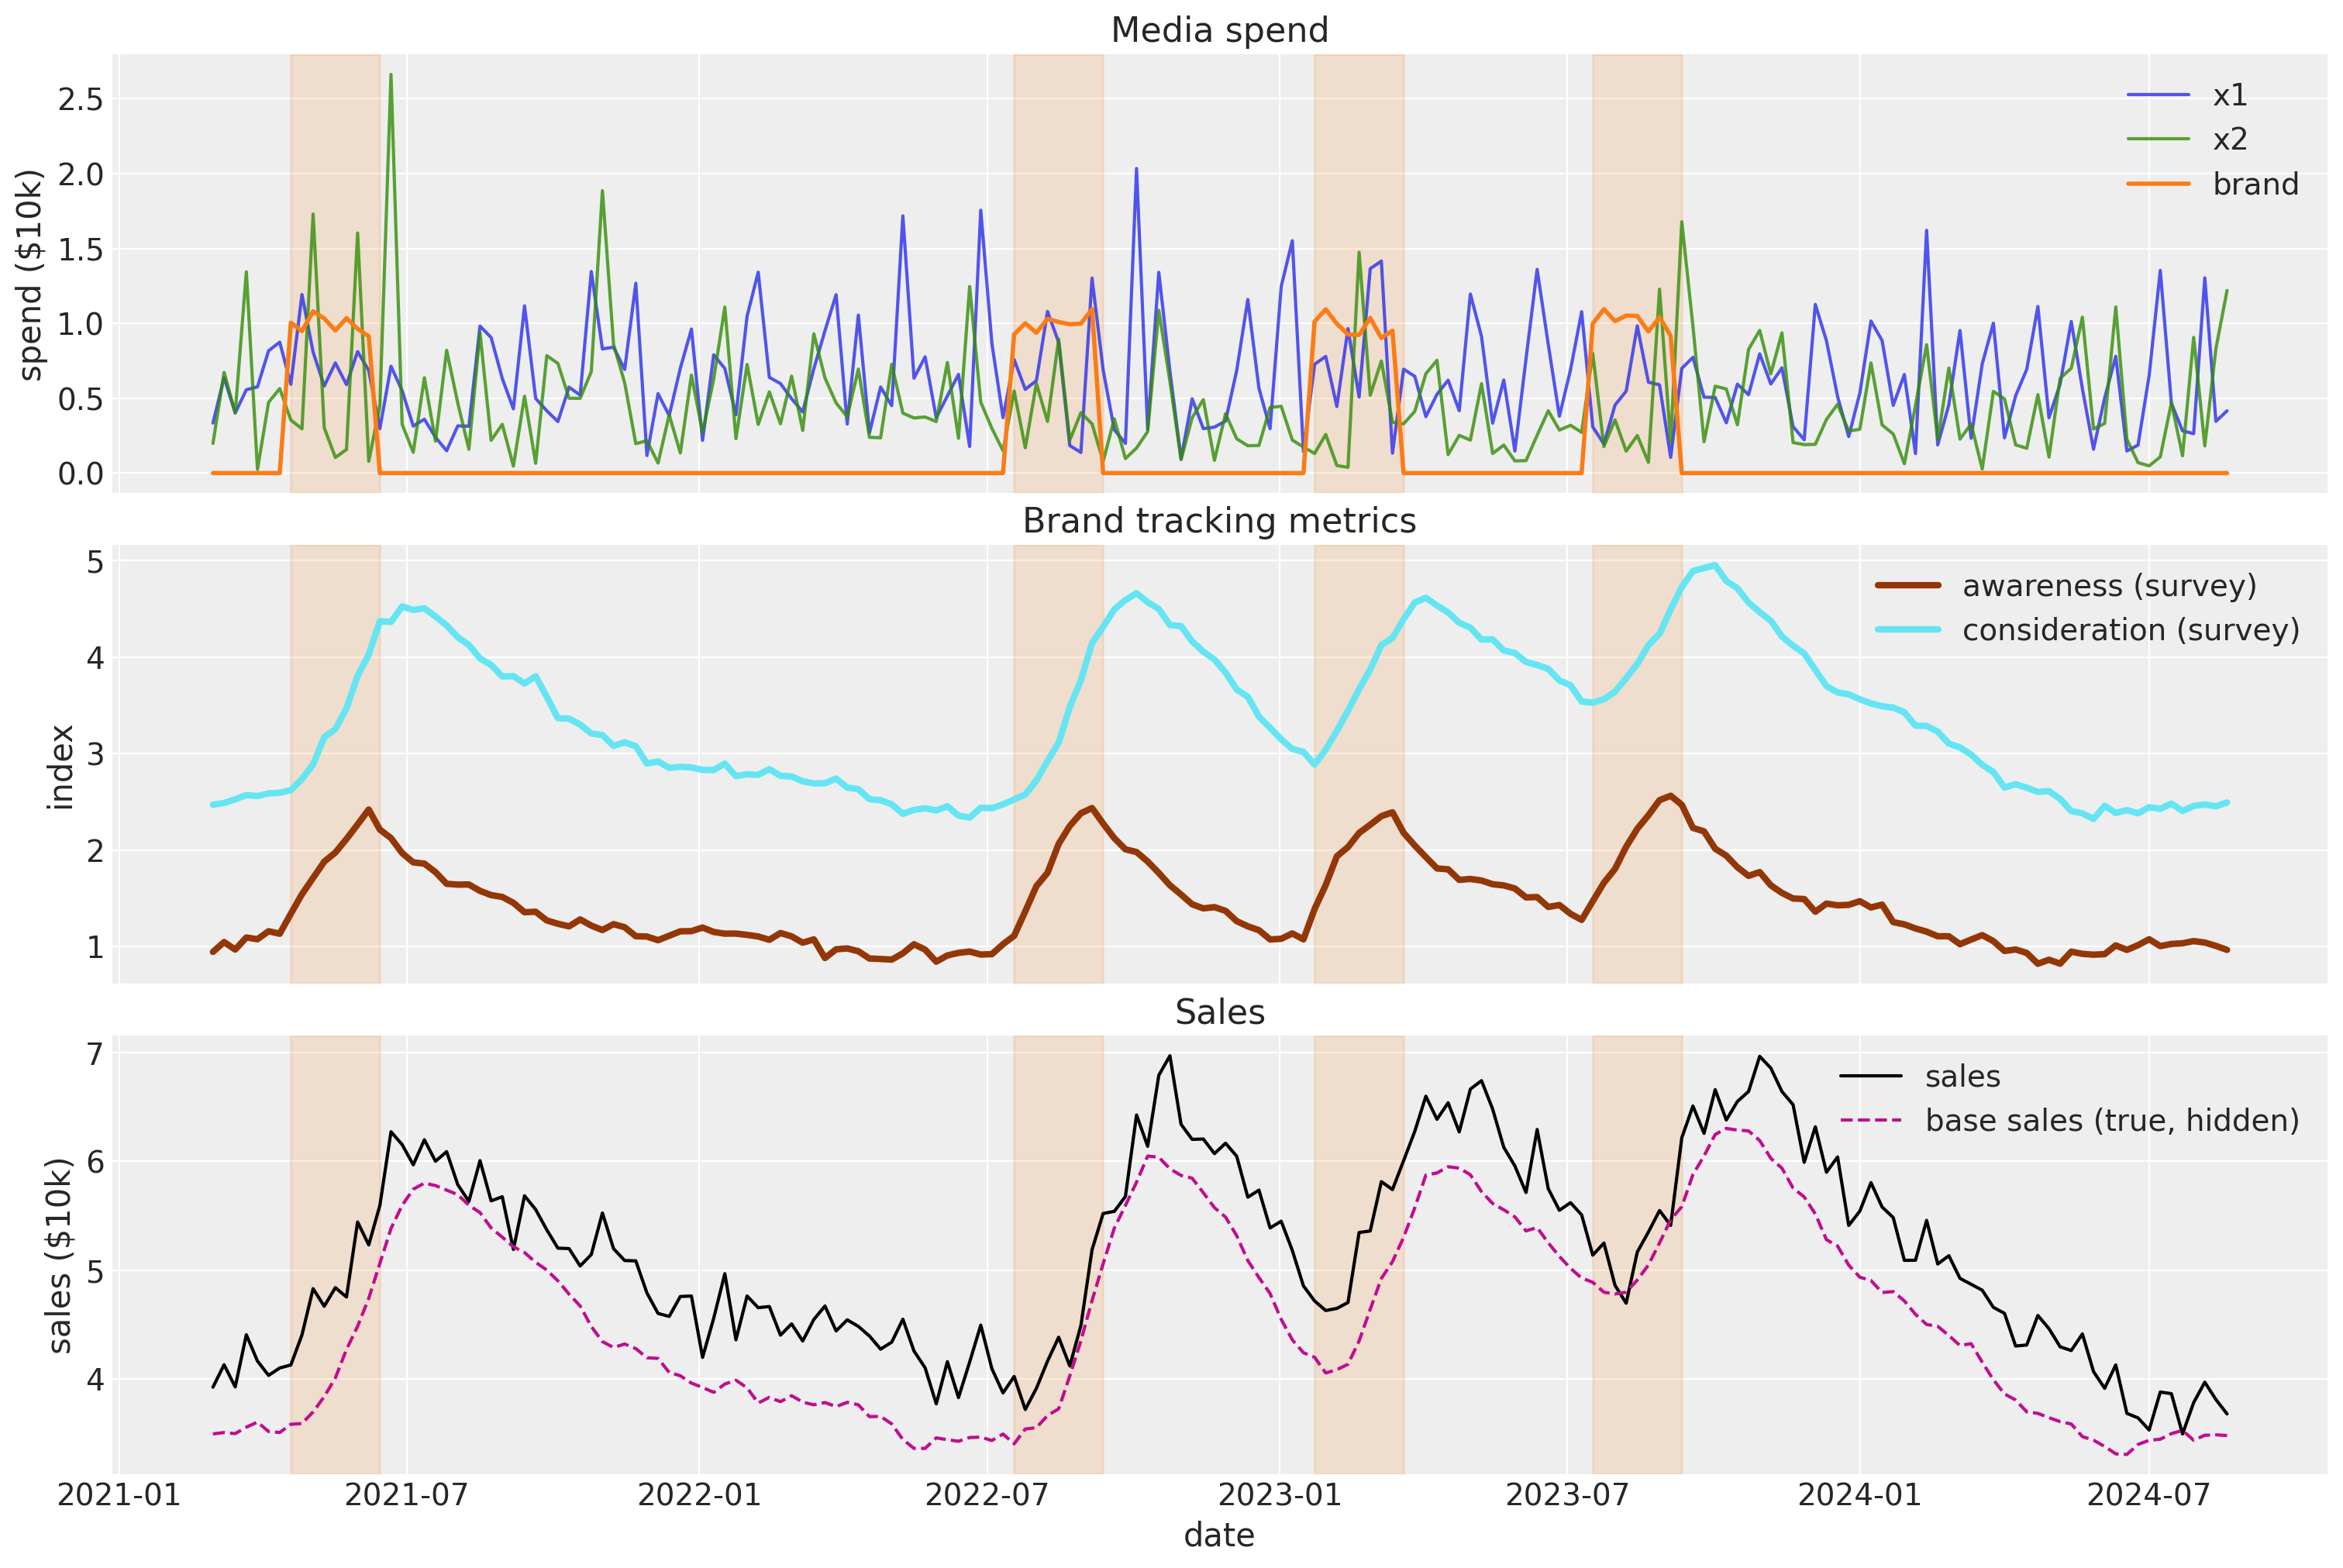

In [12]:
def shade_flights(ax):
    for start in flight_starts:
        left = dates[start + l_max]
        right = dates[min(start + l_max + 8, n_weeks - 1)]
        ax.axvspan(left, right, color="C1", alpha=0.15)


fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    sharex=True,
    sharey=False,
    figsize=(15, 10),
    layout="constrained",
)
axes[0].plot(df["date"], df["x1"], color="C0", alpha=0.8, label="x1")
axes[0].plot(df["date"], df["x2"], color="C2", alpha=0.8, label="x2")
axes[0].plot(df["date"], df["brand_spend"], color="C1", linewidth=2, label="brand")
shade_flights(axes[0])
axes[0].legend(loc="upper right")
axes[0].set(title="Media spend", ylabel="spend ($10k)")

axes[1].plot(
    df["date"],
    df["awareness"],
    color="C4",
    linewidth=3,
    label="awareness (survey)",
)
axes[1].plot(
    df["date"],
    df["consideration"],
    color="C5",
    linewidth=3,
    label="consideration (survey)",
)
shade_flights(axes[1])
axes[1].legend(loc="upper right")
axes[1].set(title="Brand tracking metrics", ylabel="index")

axes[2].plot(df["date"], df["y"], color="black", label="sales")
axes[2].plot(
    truth_df["date"],
    truth_df["base_sales"],
    color="C3",
    linestyle="--",
    label="base sales (true, hidden)",
)
shade_flights(axes[2])
axes[2].legend(loc="upper right")
axes[2].set(title="Sales", ylabel="sales ($10k)", xlabel="date");

## The Naive Approach: Brand Spend as a Regular MMM Channel

What most teams do first is add brand spend to the MMM as a third channel. Let us do exactly that, with a time-varying intercept and the same core specification we will use later, and see what happens.

In [13]:
sampler_config = {
    "tune": 1_000,
    "draws": 1_000,
    "chains": 4,
    "nuts_sampler": "nutpie",
    "target_accept": 0.95,
    "random_seed": seed,
}

naive_channels = ["x1", "x2", "brand_spend"]
cost_share_naive = xr.DataArray(
    df[naive_channels].sum() / df[naive_channels].sum().sum(),
    dims="channel",
)

model_config_naive = {
    "likelihood": Prior("Normal", sigma=Prior("HalfNormal", sigma=2)),
    "gamma_fourier": Prior("Normal", mu=0, sigma=2, dims="fourier_mode"),
    "intercept_tvp_config": intercept_tvp_config,
    "intercept": Prior("Normal", mu=4, sigma=1),
    "adstock_alpha": Prior("Beta", alpha=2, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", mu=2, sigma=0.5, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=cost_share_naive, dims="channel"),
}

In [14]:
%%time
mmm_naive = MMM(
    date_column="date",
    target_column="y",
    channel_columns=naive_channels,
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config=model_config_naive,
)

X_naive = df[["date", *naive_channels]]
y = df["y"]

mmm_naive.build_model(X_naive, y)
mmm_naive.add_original_scale_contribution_variable(
    var=["channel_contribution", "intercept_contribution"]
)
_ = mmm_naive.fit(X_naive, y, **sampler_config)

NUTS[nutpie]: [intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, adstock_alpha, saturation_lam, saturation_beta, gamma_fourier, y_sigma]


Output()

Output()

CPU times: user 1min 12s, sys: 789 ms, total: 1min 12s
Wall time: 21 s


In [15]:
# Brand spend adstocks to exactly zero in the weeks between flights, so its
# contribution has no within-chain variance there and the split-R-hat step
# hits a harmless 0/0; we silence that RuntimeWarning while checking diagnostics.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    _ = az.diagnose(mmm_naive.idata)

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


In [16]:
az.summary(
    mmm_naive.idata,
    var_names=["saturation_beta", "adstock_alpha", "saturation_lam"],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
saturation_beta[x1],0.203,0.063,0.13,0.32,4532,2530,1.00,0.0011,0.0012
saturation_beta[x2],0.186,0.057,0.11,0.29,5959,3222,1.00,0.00082,0.00092
saturation_beta[brand_spend],0.0045,0.0054,0.0002,0.014,4621,3316,1.00,8.6e-05,0.00019
adstock_alpha[x1],0.464,0.096,0.31,0.62,4282,2702,1.00,0.0015,0.001
adstock_alpha[x2],0.339,0.112,0.16,0.52,5043,3367,1.00,0.0016,0.0011
adstock_alpha[brand_spend],0.47,0.223,0.13,0.83,4043,3481,1.00,0.0035,0.0018
saturation_lam[x1],1.93,0.488,1.2,2.8,5628,2722,1.00,0.0064,0.0047
saturation_lam[x2],1.91,0.472,1.2,2.7,6215,3542,1.00,0.006,0.0046
saturation_lam[brand_spend],1.93,0.5,1.2,2.8,4501,2363,1.00,0.0074,0.0056


The incremental ROI per channel comes from the {attr}`~pymc_marketing.mmm.mmm.MMM.incrementality` namespace, which computes counterfactual contributions with proper adstock carryover handling. We visualize the posterior ROI of each channel as a forest plot (median, 50% and 94% intervals), with the *true direct* ROI of each channel marked by a black diamond. Recall that for brand spend the true direct effect is exactly zero by construction.

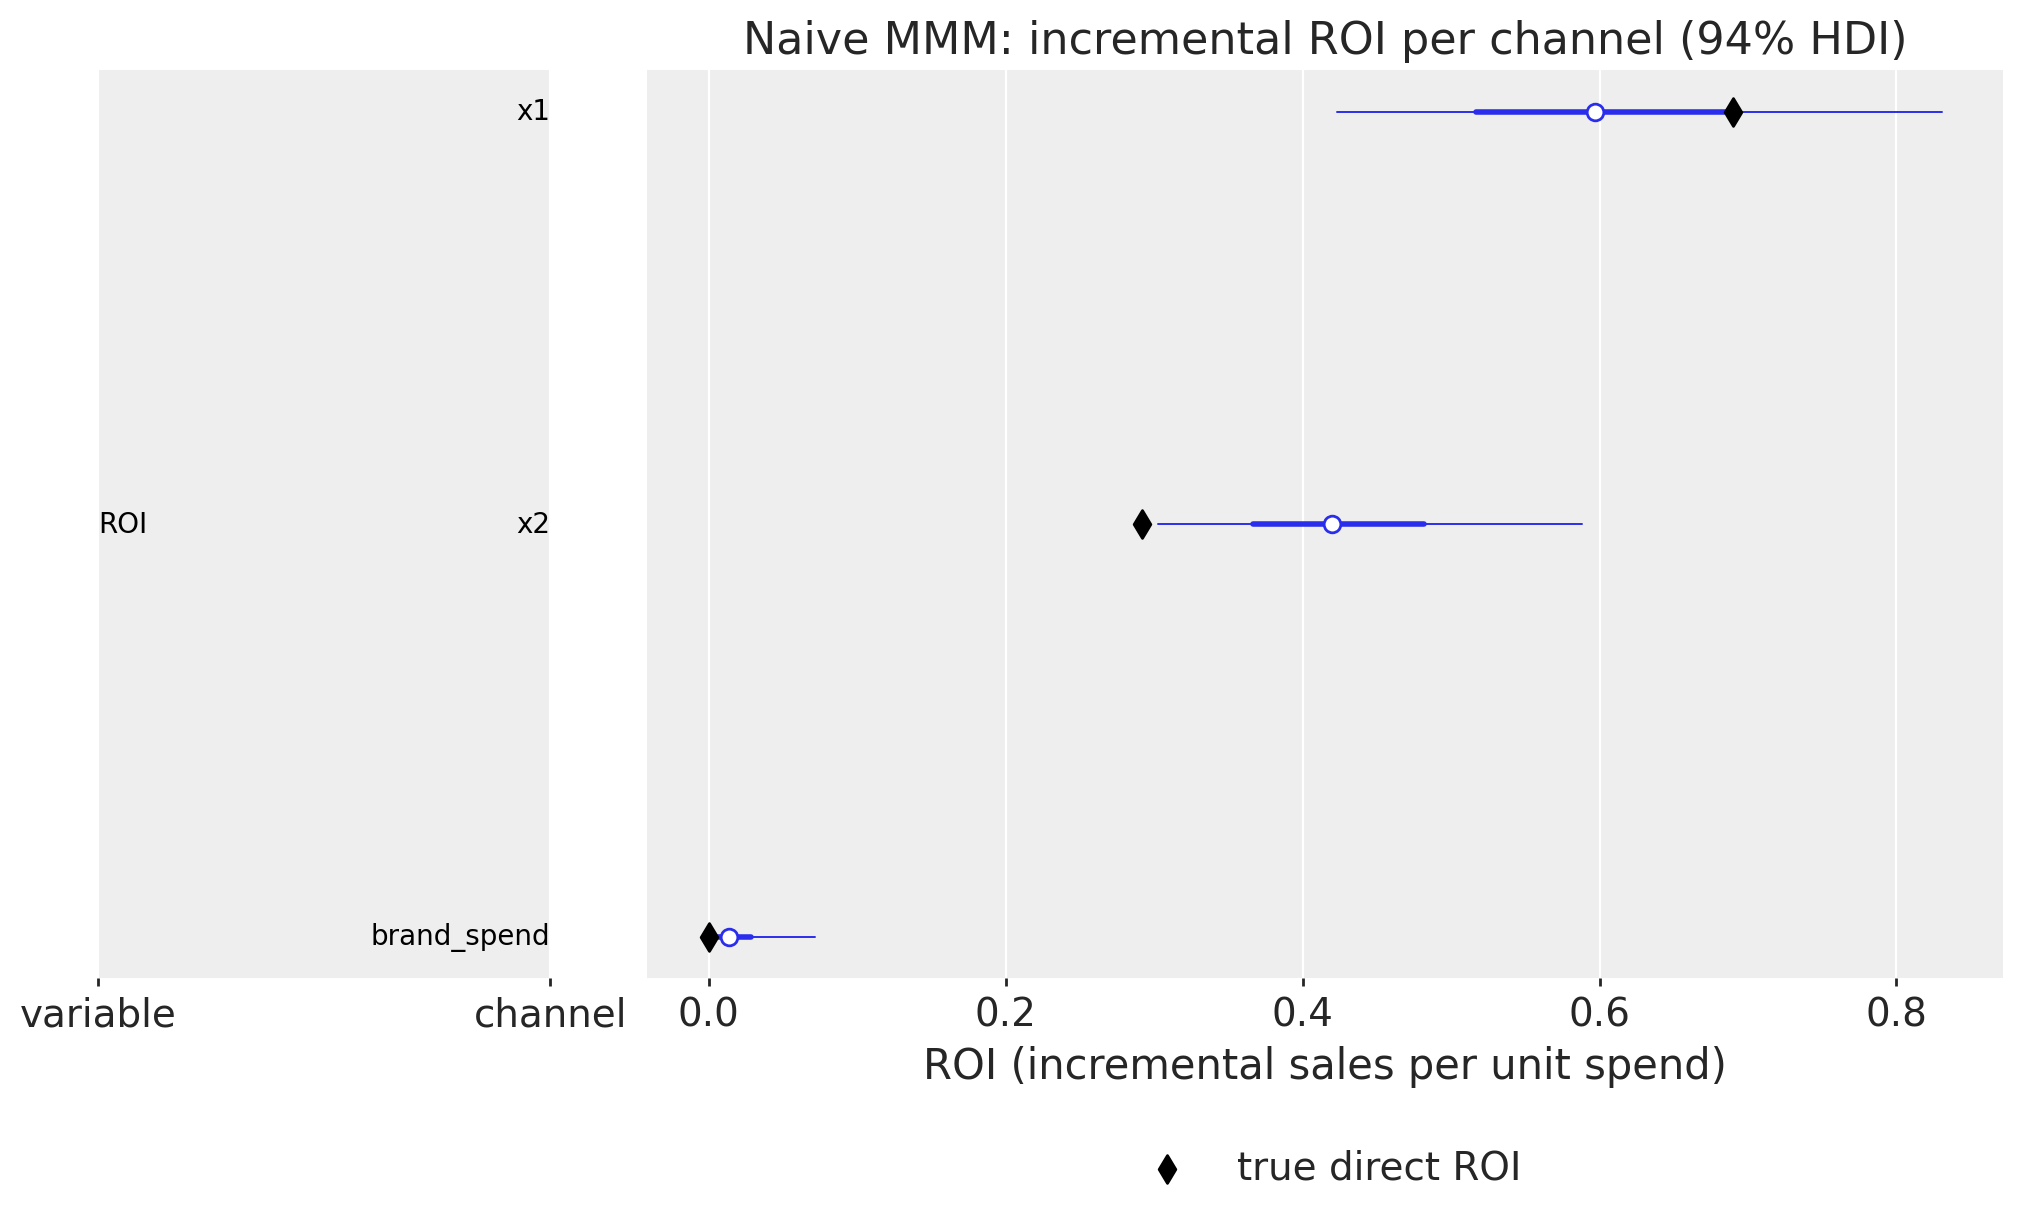

In [17]:
roi_naive = mmm_naive.incrementality.contribution_over_spend(
    frequency="all_time"
).rename("roi")

pc = az.plot_forest(
    xr.Dataset({"ROI": roi_naive}),
    combined=True,
    point_estimate="median",
    figure_kwargs={"figsize": (10, 6)},
)
ax = pc.viz["/"]["plot"].sel(column="forest").item()
for channel, true_roi in zip(
    naive_channels, [true_roi_x1, true_roi_x2, 0.0], strict=True
):
    y_pos = (
        pc.viz["point_estimate"]["ROI"].sel(channel=channel).item().get_offsets()[0, 1]
    )
    ax.scatter(
        true_roi,
        y_pos,
        color="black",
        marker="d",
        s=50,
        zorder=5,
        label="true direct ROI" if channel == "x1" else None,
    )
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1)
ax.set(
    title="Naive MMM: incremental ROI per channel (94% HDI)",
    xlabel="ROI (incremental sales per unit spend)",
);

In [18]:
roi_naive_hdi = az.hdi(roi_naive, prob=0.94)

pd.DataFrame(
    {
        "recovered median": roi_naive.median(dim=("chain", "draw")).to_series(),
        "hdi_low": roi_naive_hdi.sel(ci_bound="lower").to_series(),
        "hdi_high": roi_naive_hdi.sel(ci_bound="upper").to_series(),
        "true direct": [true_roi_x1, true_roi_x2, 0.0],
    }
)

,recovered median,hdi_low,hdi_high,true direct
channel,,,,
x1,0.596899,0.372879,0.844453,0.690125
x2,0.419522,0.267602,0.598644,0.291644
brand_spend,0.013391,0.000001,0.068280,0.000000


The naive model reports an ROI of essentially zero for brand spend, and the summary table above shows two distinct things happening to get there. `saturation_beta[brand_spend]` is pushed hard against zero *by the data*: its posterior mean of $0.0045$ sits far below the prior mean of about $0.11$ implied by a half-normal scaled to brand's cost share. Once that coefficient is at zero the channel's shape parameters have nothing left to fit, so `adstock_alpha[brand_spend]` ($0.47 \pm 0.22$) and `saturation_lam[brand_spend]` ($1.93 \pm 0.50$) simply return their priors. The channel's contribution to sales is negligible. For the performance channels, `x1`'s 94% interval covers its true short-term ROI (black diamond) comfortably, while for `x2` the truth sits right at the interval's lower edge.

Here is the uncomfortable part: **the model is right** about brand. The direct short-term effect of brand marketing *is* zero in our simulation. And yet this number is useless, and dangerous, as an answer to "what did the brand campaigns do for the business?", because the entire brand effect went into the time-varying intercept. If this ROI figure were taken at face value, the brand budget would be cut. To answer the CMO's actual question we need to follow the effect into the baseline, which is what the two-stage workflow does.

## Stage 1: MMM with a Time-Varying Baseline

We now fit the measurement MMM with only the performance channels, following the causal graph, where brand spend has no direct edge to sales. A word of caution on this step: here we *know* the graph because we simulated it, so dropping brand is unambiguously correct. With real data you do not, and "the naive model estimated a near-zero direct effect, so I will now assume it is exactly zero" is circular. If brand does carry a genuine direct short-term effect, excluding it from Stage 1 pushes that effect into the baseline, where Stage 2 re-credits it through the funnel path; the total stays roughly right but the short-versus-long decomposition is wrong. The safer default on real data is to keep brand in Stage 1 and, in Stage 2, credit brand only through the baseline path rather than any residual direct term. Excluding brand here also protects us from double counting when we credit it through the baseline in Stage 2.

The time-varying intercept is a Hilbert Space Gaussian Process approximation, configured through {class}`~pymc_marketing.hsgp_kwargs.HSGPKwargs` as in {ref}`mmm_roas` and {ref}`mmm_tv_intercept`.

```{note}
The HSGP time-varying intercept is an *in-sample decomposition* device: out of sample it reverts to the prior mean. This workflow is therefore for measurement, not for forecasting the baseline. Anything else missing from the model (price changes, distribution, promotions) also lands in the baseline, so with real data make sure such drivers are either included as controls in Stage 1 or as variables in Stage 2, lest the VARX misattribute their effect to brand.
```

In [19]:
channels = ["x1", "x2"]
cost_share = xr.DataArray(
    df[channels].sum() / df[channels].sum().sum(),
    dims="channel",
)

model_config = {
    "likelihood": Prior("TruncatedNormal", lower=0, sigma=Prior("HalfNormal", sigma=2)),
    "gamma_fourier": Prior("Normal", mu=0, sigma=2, dims="fourier_mode"),
    "intercept_tvp_config": intercept_tvp_config,
    "intercept": Prior("Normal", mu=4, sigma=1),
    "adstock_alpha": Prior("Beta", alpha=2, beta=3, dims="channel"),
    "saturation_lam": Prior("Gamma", mu=2, sigma=0.5, dims="channel"),
    "saturation_beta": Prior("HalfNormal", sigma=cost_share, dims="channel"),
}

mmm = MMM(
    date_column="date",
    target_column="y",
    channel_columns=channels,
    adstock=GeometricAdstock(l_max=l_max),
    saturation=LogisticSaturation(),
    yearly_seasonality=2,
    time_varying_intercept=True,
    model_config=model_config,
)

X = df[["date", *channels]]

mmm.build_model(X, y)
mmm.add_original_scale_contribution_variable(
    var=["channel_contribution", "fourier_contribution", "intercept_contribution"]
)

Two specification differences with respect to the naive model are worth flagging. First, the likelihood is a `TruncatedNormal` with a lower bound at zero: sales are strictly positive, and encoding that constraint in the likelihood keeps the model from wasting posterior mass on impossible negative sales. Second, brand spend is excluded from the channel list, as the causal graph prescribes. The `saturation_lam` prior is the same tightened `Gamma(mu=2, sigma=0.5)` as in the naive model, and for the same reason: the flexible intercept is still present, and the beta/lam ridge does not care whether brand spend is in the channel list.

Before spending any compute on MCMC we check the priors, as in {ref}`mmm_example`: we push `2_000` parameter draws through the model and compare the implied sales distribution with the observed series. We are looking for a prior predictive distribution that comfortably covers the data without concentrating away from it: evidence that the priors are weakly informative on the right scale, not that they are tuned to the answer.

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [adstock_alpha, gamma_fourier, intercept_baseline, intercept_latent_process_raw_eta, intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_ls, saturation_beta, saturation_lam, y, y_sigma]


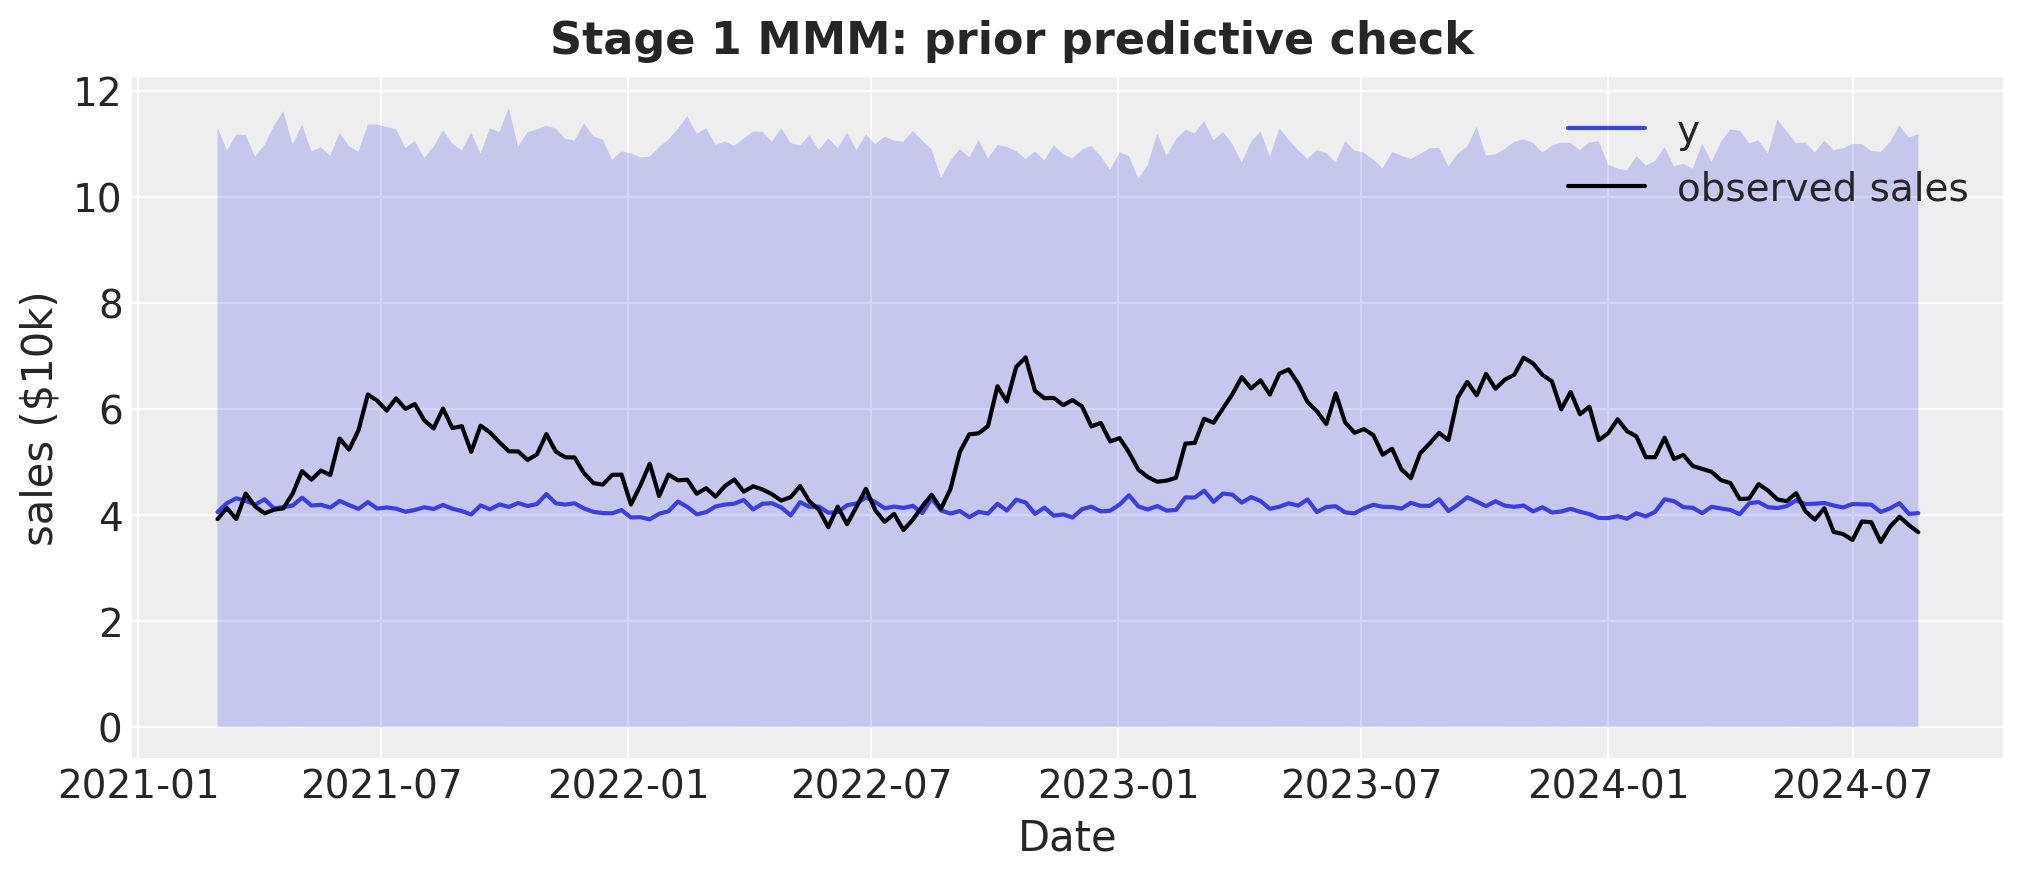

In [20]:
mmm.sample_prior_predictive(X, y, samples=2_000, random_seed=seed + 3)
fig, axes = mmm.plot.prior_predictive(hdi_prob=0.94)
ax = np.ravel(axes)[0]
ax.plot(df["date"], y, color="black", linewidth=1.5, label="observed sales")
ax.legend(loc="upper right")
ax.set(title="", ylabel="sales ($10k)")
fig.suptitle(
    "Stage 1 MMM: prior predictive check", fontsize=16, fontweight="bold", y=1.06
);

The 94% prior predictive band covers the observed sales path along the whole sample (the highest peaks graze its upper edge): the priors are on the right scale without being tuned to the data. We proceed to inference.

In [21]:
%%time
_ = mmm.fit(X, y, **(sampler_config | {"random_seed": seed + 2}))
_ = mmm.sample_posterior_predictive(
    X, extend_idata=True, combined=True, random_seed=seed + 4
)

NUTS[nutpie]: [intercept_latent_process_raw_hsgp_coefs_offset, intercept_latent_process_raw_eta, intercept_latent_process_raw_ls, intercept_baseline, gamma_fourier, adstock_alpha, saturation_lam, saturation_beta, y_sigma]


Output()

Output()

/Users/juanitorduz/Documents/pymc-marketing/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:214: UserWarning: Numba will use object mode to run truncated_normal_rv{"(),(),(),()->()"}'s perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
Sampling: [y]


Output()

CPU times: user 1min 21s, sys: 961 ms, total: 1min 22s
Wall time: 24.7 s


In [22]:
_ = az.diagnose(mmm.idata)

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


In [23]:
az.summary(
    mmm.idata,
    var_names=[
        "saturation_beta",
        "adstock_alpha",
        "saturation_lam",
        "intercept_baseline",
    ],
)

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
saturation_beta[x1],0.202,0.061,0.12,0.31,6061,2979,1.00,0.00089,0.00097
saturation_beta[x2],0.184,0.055,0.11,0.28,6914,3340,1.00,0.00073,0.00089
adstock_alpha[x1],0.463,0.095,0.31,0.61,5864,3276,1.00,0.0012,0.00087
adstock_alpha[x2],0.333,0.111,0.16,0.52,4593,3173,1.00,0.0016,0.0011
saturation_lam[x1],1.93,0.491,1.2,2.8,6507,3212,1.00,0.0061,0.0046
saturation_lam[x2],1.9,0.448,1.3,2.7,7333,3411,1.00,0.0052,0.0041
intercept_baseline,0.657,0.0135,0.63,0.68,3923,2637,1.00,0.00022,0.00019


Since we simulated the data, we can compare the posteriors directly against the generating values. One subtlety: the model works on a max-scaled target, so the fitted `saturation_beta` lives in scaled units and the true value must be divided by `y.max()` before the comparison (`adstock_alpha` and `saturation_lam` act on the max-scaled spends, which are identical in the generator and the fitted model, so they compare directly).

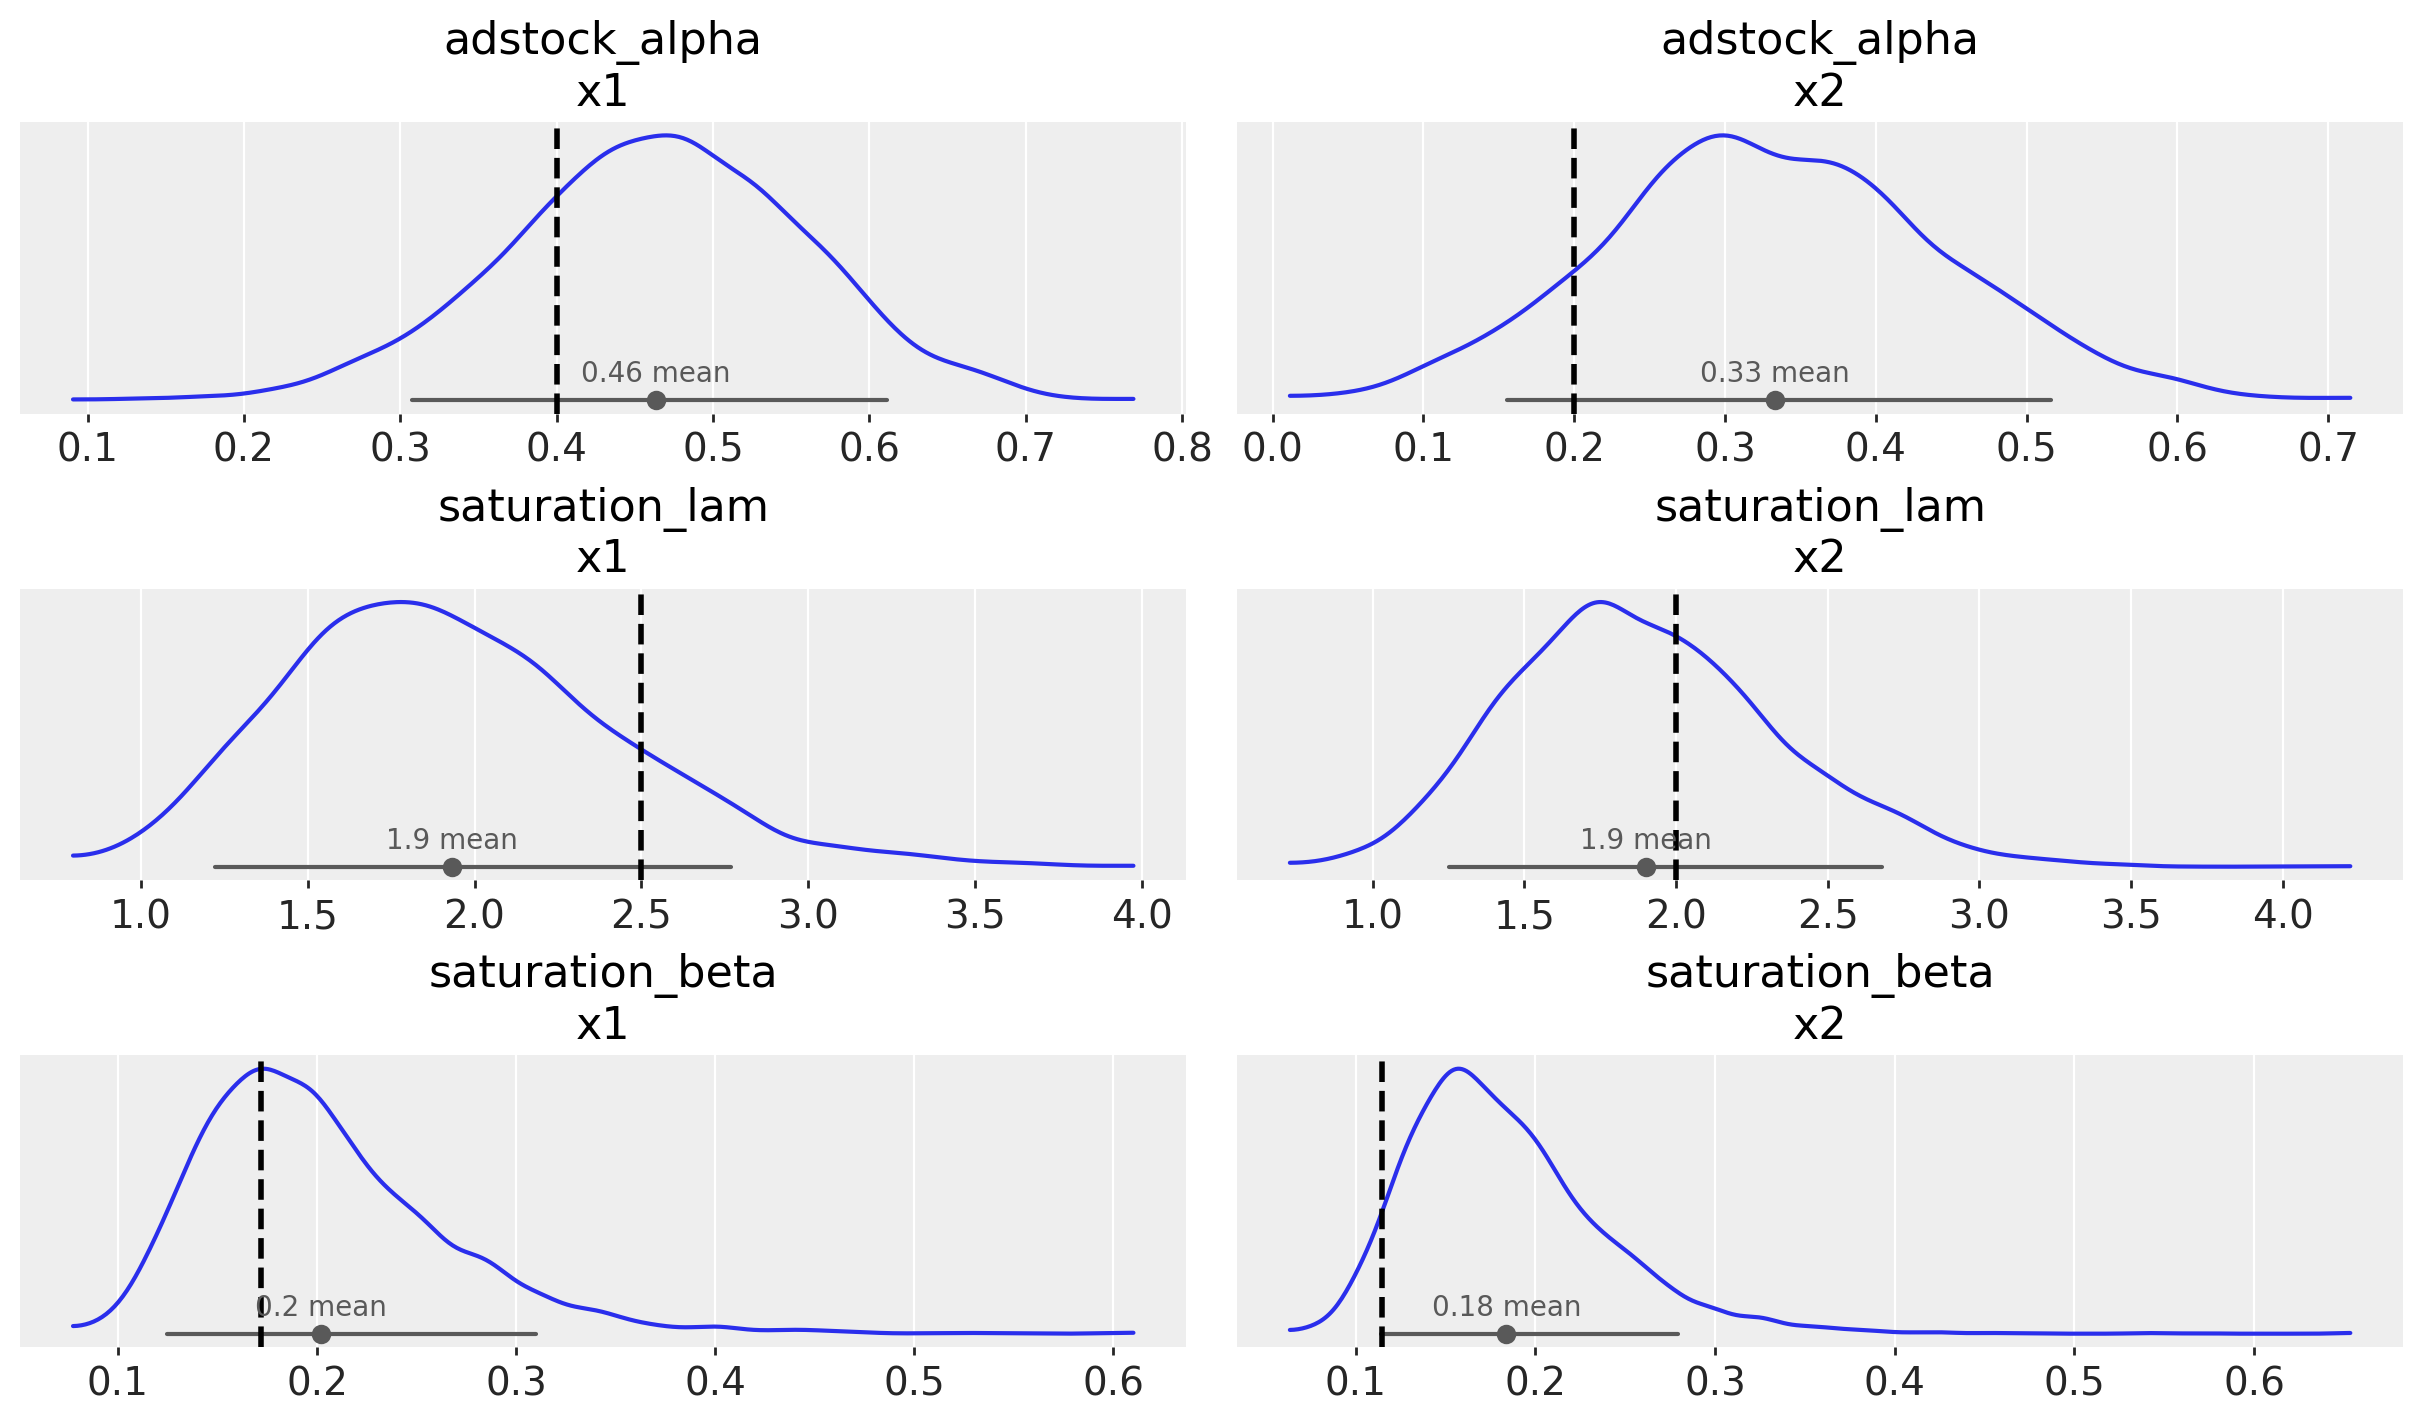

In [24]:
true_params = {
    "adstock_alpha": adstock_alpha_true,
    "saturation_lam": saturation_lam_true,
    "saturation_beta": saturation_beta_true / y.max(),
}

pc = az.plot_dist(
    mmm.idata,
    var_names=list(true_params),
    group="posterior",
    figure_kwargs={"figsize": (12, 7)},
    col_wrap=2,
)
for var, true_vals in true_params.items():
    for channel, true_val in zip(channels, true_vals, strict=True):
        ax = pc.viz["plot"][var].sel(channel=channel).item()
        ax.axvline(true_val, color="black", linestyle="--", linewidth=2)

Every true value (dashed line) falls inside its marginal posterior, though not always centrally.

The decomposition below shows how the model splits sales between the performance channels and the evolving baseline.

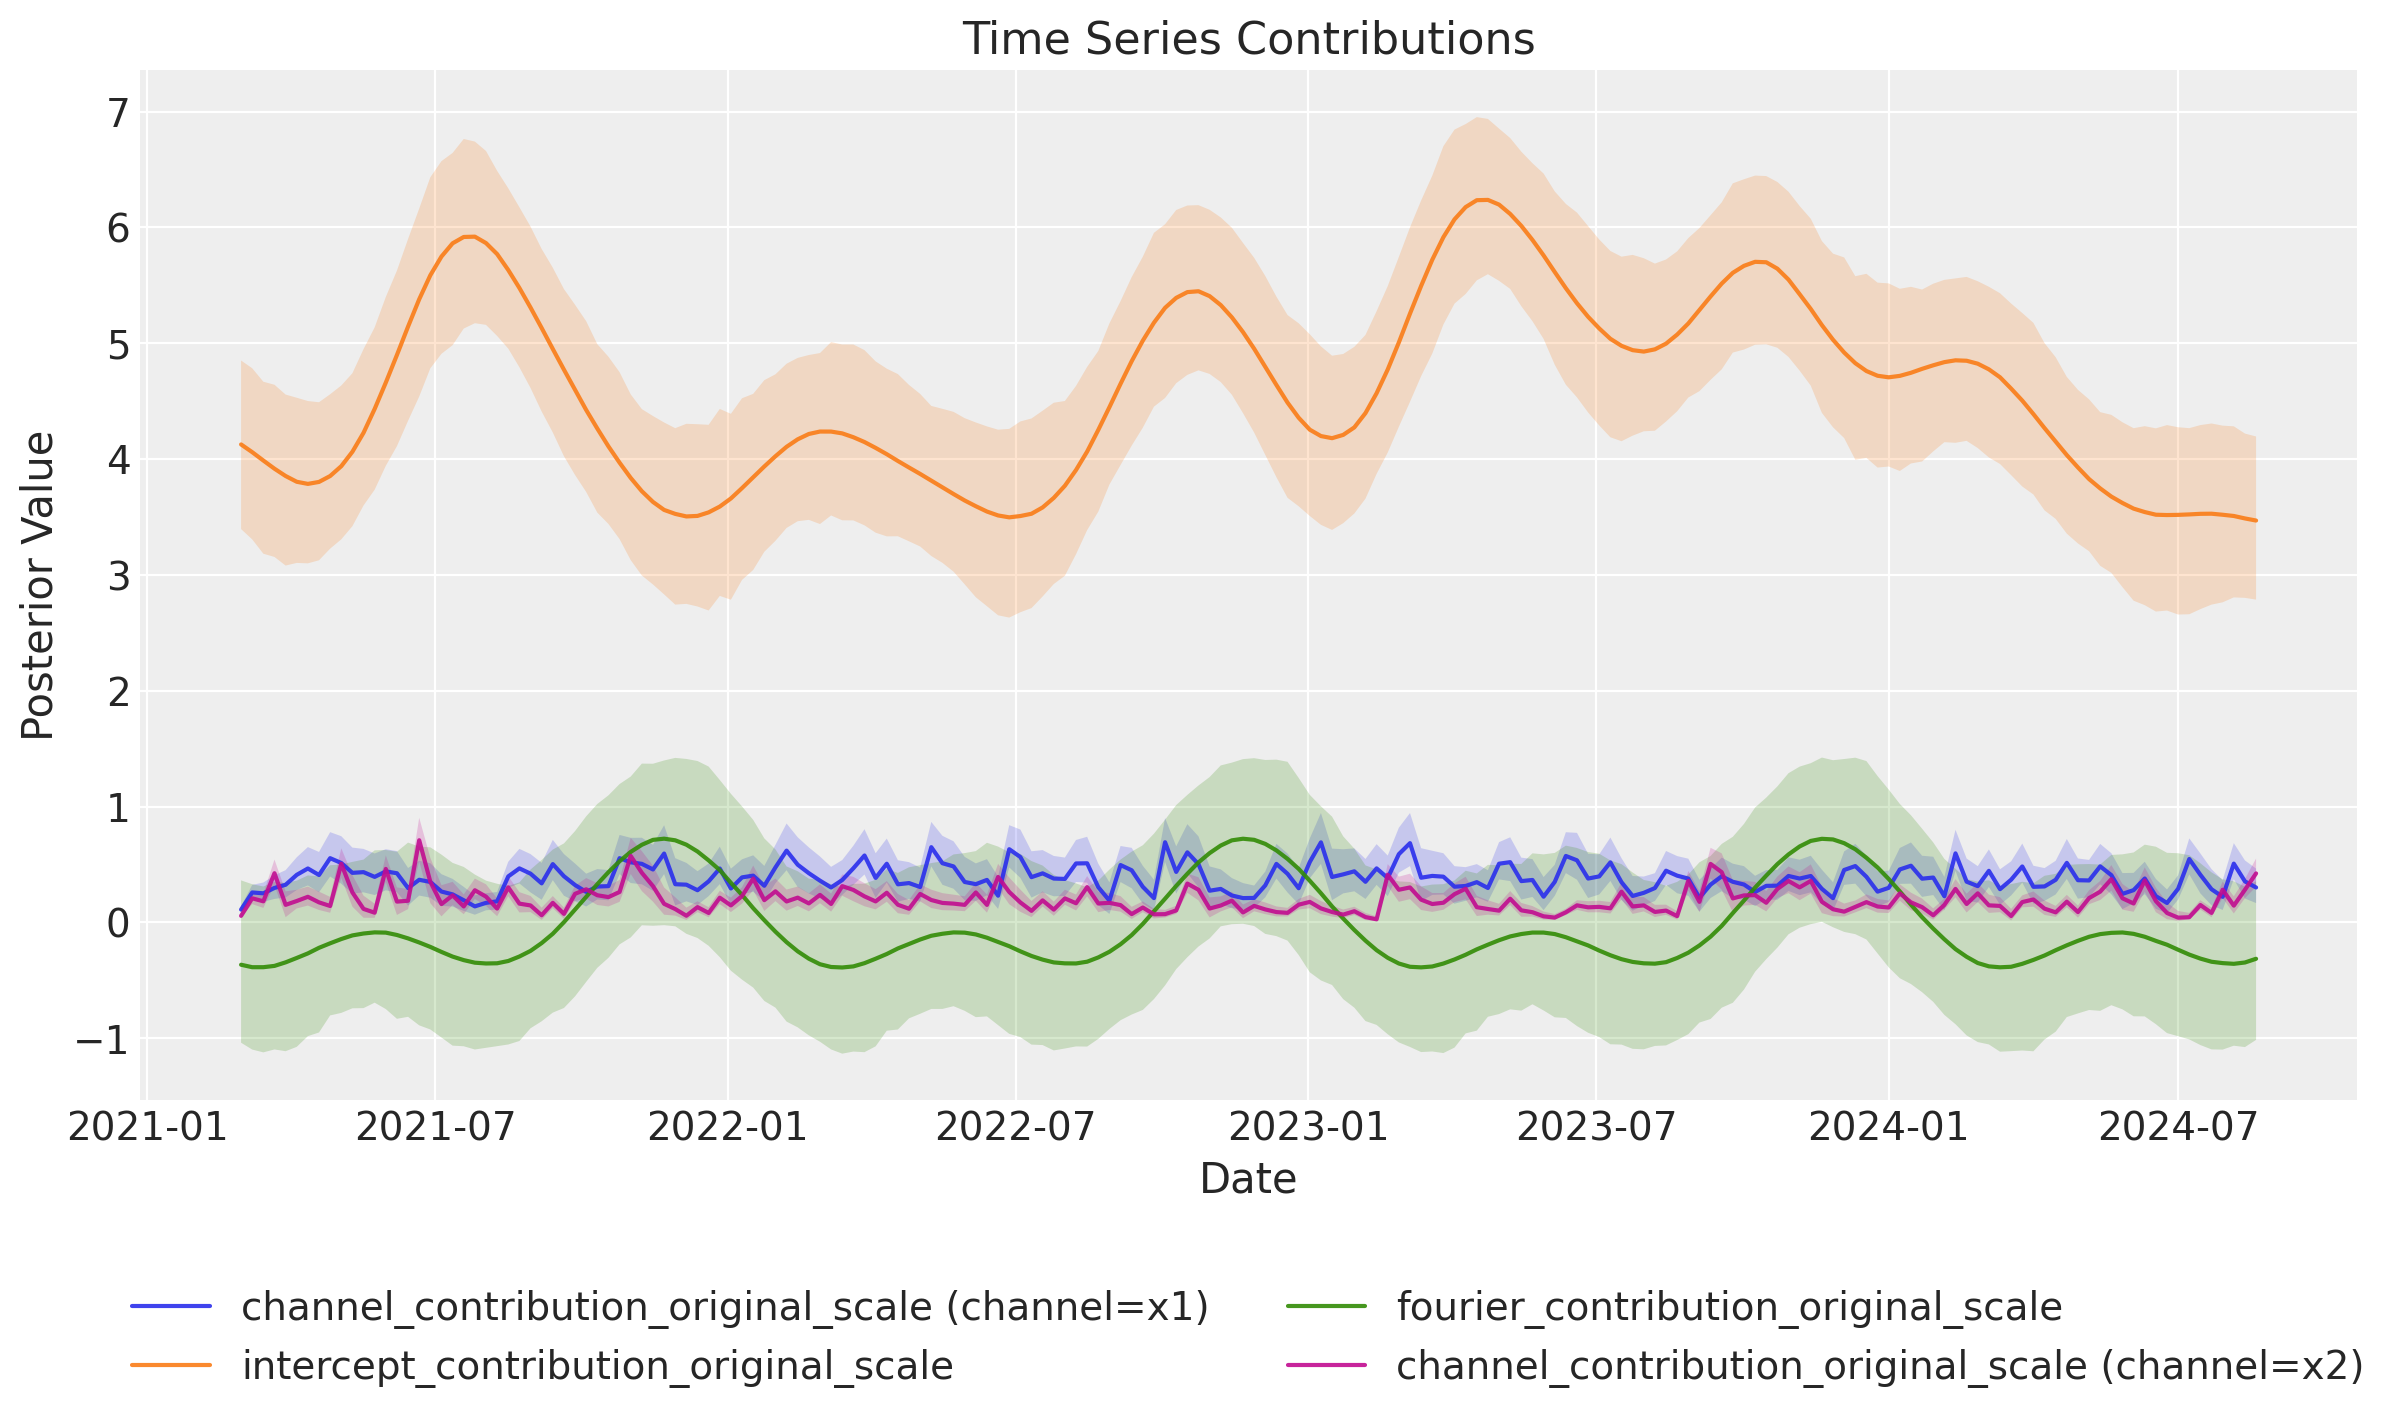

In [25]:
fig, axes = mmm.plot.contributions_over_time(
    var=[
        "channel_contribution_original_scale",
        "intercept_contribution_original_scale",
        "fourier_contribution_original_scale",
    ],
    dims={"channel": channels},
    combine_dims=True,
    hdi_prob=0.94,
    figsize=(12, 7),
)
axes[0][0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2);

The critical Stage-1 deliverable is the extracted baseline. Since we simulated the data, we can hold it against the true base sales path:

correlation(extracted baseline, true base sales) = 0.920


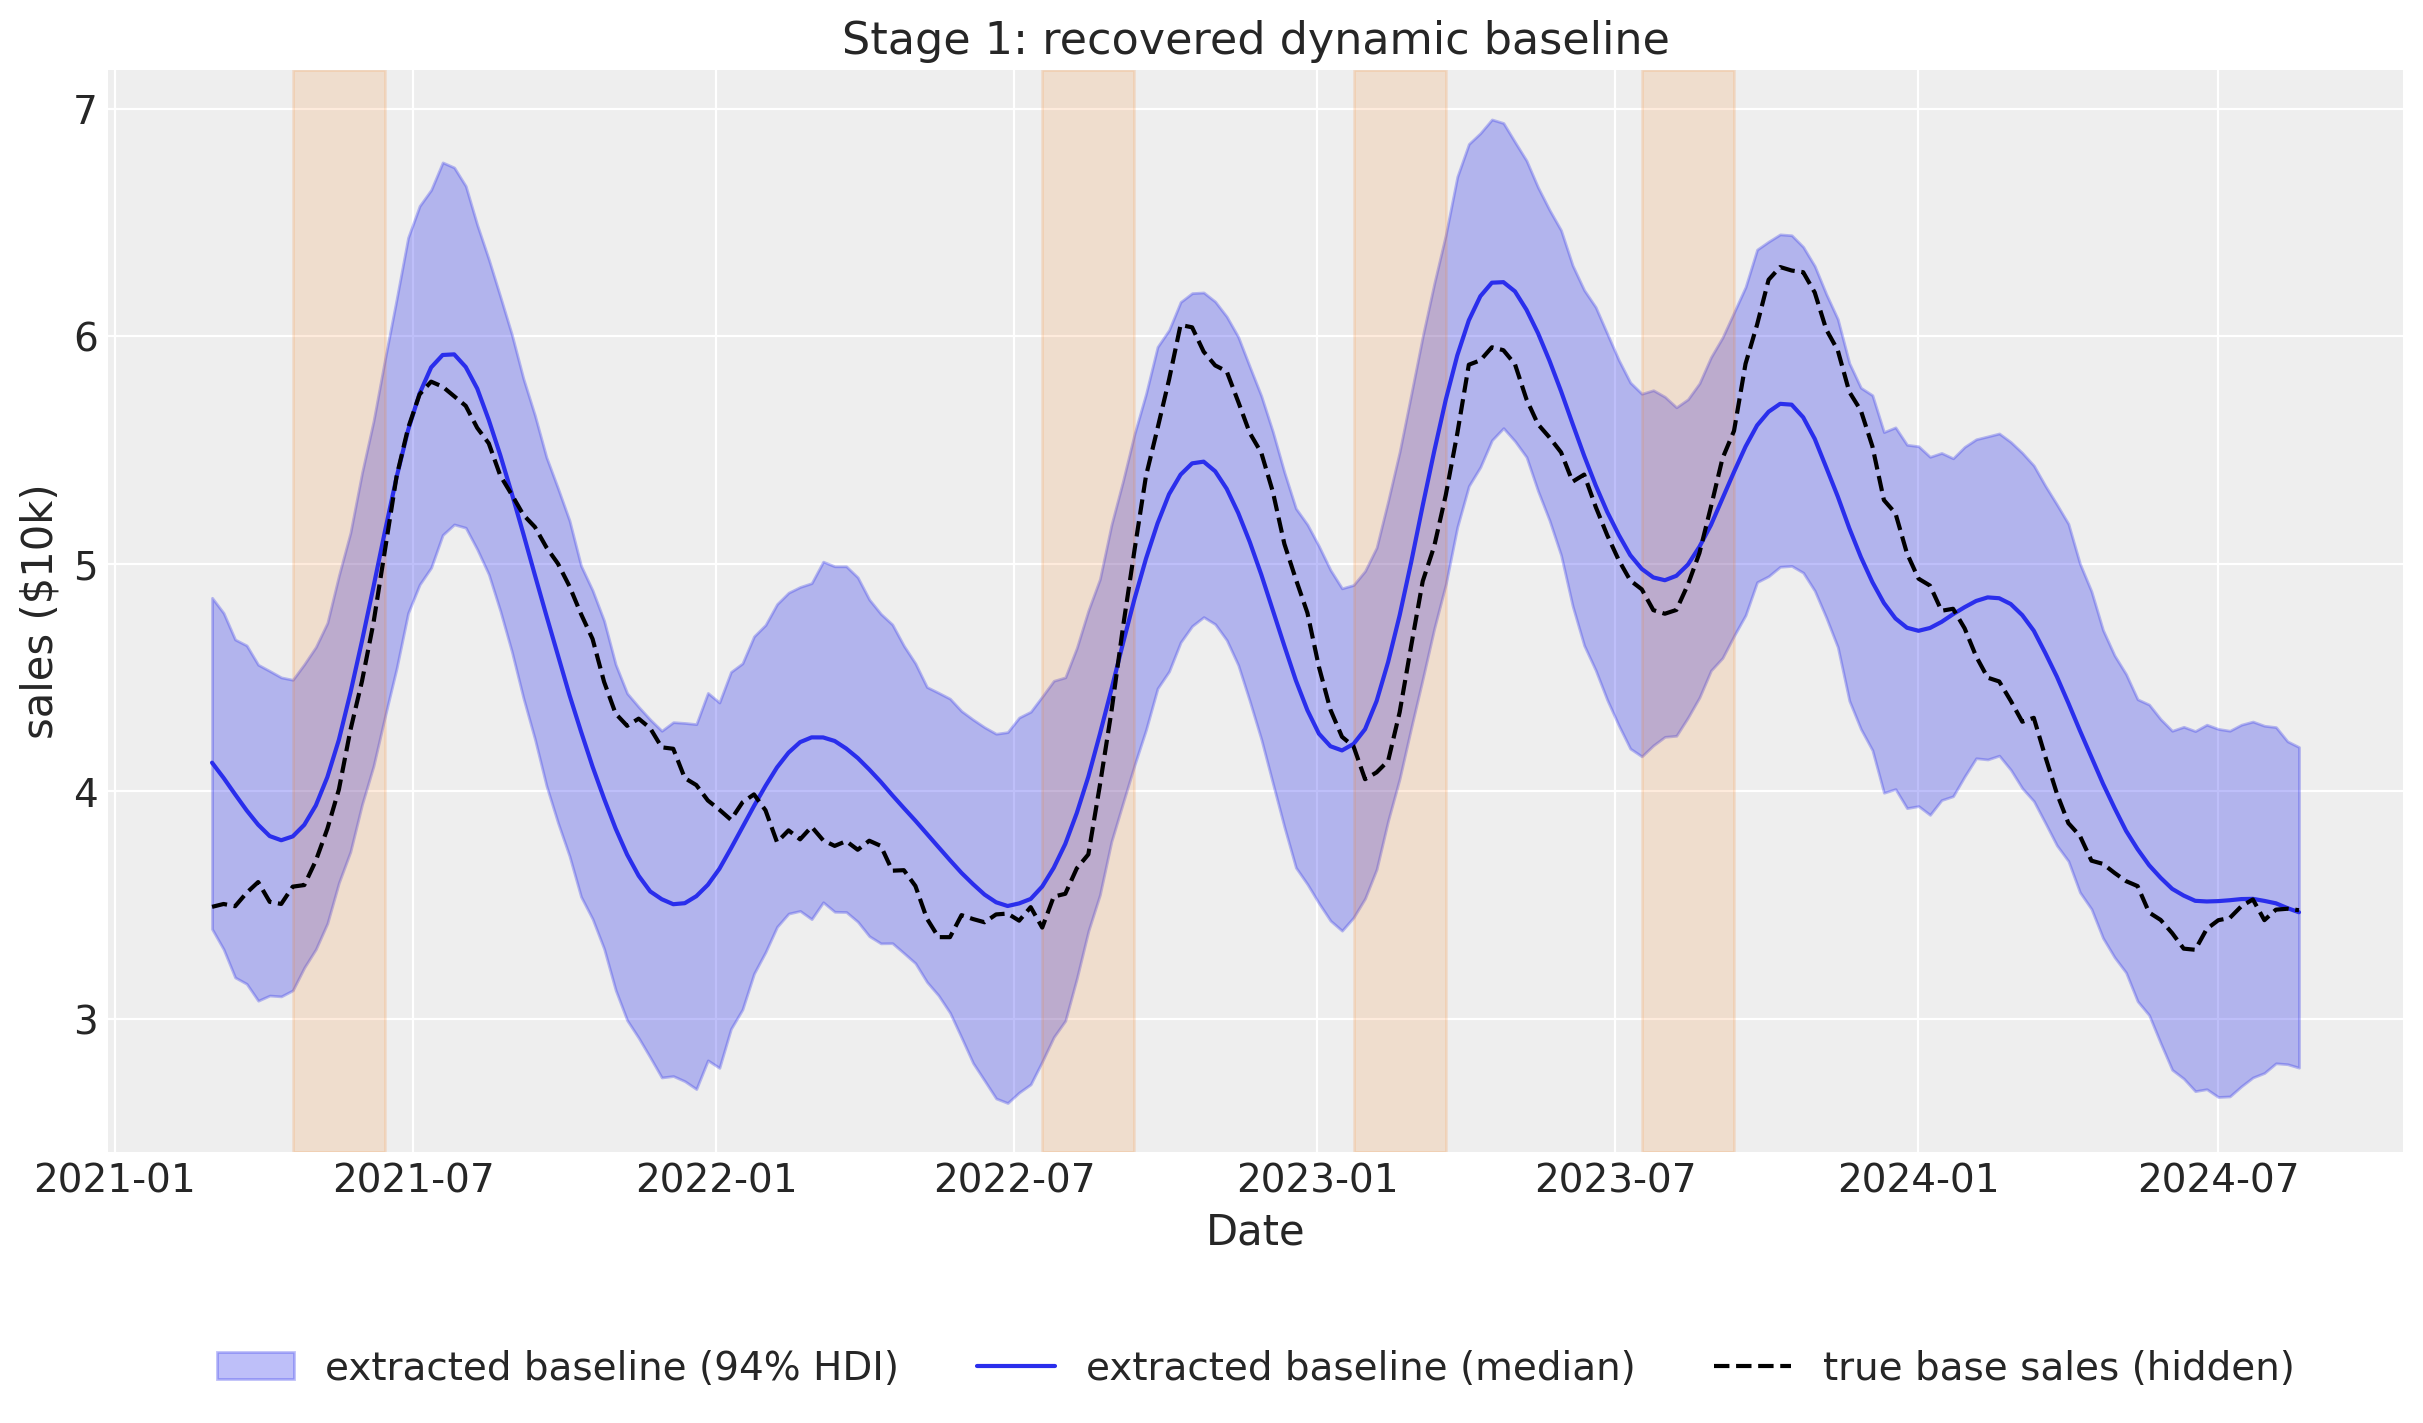

In [26]:
baseline_da = mmm.idata.posterior["intercept_contribution_original_scale"]
baseline_median = baseline_da.median(dim=("chain", "draw"))
baseline_hdi = az.hdi(baseline_da, prob=0.94)

fig, ax = plt.subplots()
ax.fill_between(
    df["date"],
    baseline_hdi.sel(ci_bound="lower"),
    baseline_hdi.sel(ci_bound="upper"),
    color="C0",
    alpha=0.3,
    label="extracted baseline (94% HDI)",
)
ax.plot(df["date"], baseline_median, color="C0", label="extracted baseline (median)")
ax.plot(
    truth_df["date"],
    truth_df["base_sales"],
    color="black",
    linestyle="--",
    label="true base sales (hidden)",
)
shade_flights(ax)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3)
ax.set(
    title="Stage 1: recovered dynamic baseline", xlabel="Date", ylabel="sales ($10k)"
)

corr_baseline = np.corrcoef(baseline_median, truth_df["base_sales"])[0, 1]
print(f"correlation(extracted baseline, true base sales) = {corr_baseline:.3f}")

In [27]:
roi_stage1 = mmm.incrementality.contribution_over_spend(frequency="all_time").rename(
    "roi"
)
roi_stage1_hdi = az.hdi(roi_stage1, prob=0.94)

pd.DataFrame(
    {
        "recovered median": roi_stage1.median(dim=("chain", "draw")).to_series(),
        "hdi_low": roi_stage1_hdi.sel(ci_bound="lower").to_series(),
        "hdi_high": roi_stage1_hdi.sel(ci_bound="upper").to_series(),
        "true": [true_roi_x1, true_roi_x2],
    }
)

,recovered median,hdi_low,hdi_high,true
channel,,,,
x1,0.593049,0.367297,0.859997,0.690125
x2,0.413516,0.265291,0.591216,0.291644


The baseline tracks the true base sales closely (correlation just above 0.9, printed above; the wiggles are the price of a flexible GP, and some smoothing against the seasonal terms is expected), and the true short-term ROIs fall inside their recovered 94% intervals. Together with the clean sampling diagnostics above, Stage 1 has done its job: the brand-driven drift is now an explicit, extractable time series instead of a nuisance.

## Stage 2 Preparation: the VARX Frame

Stage 2 models the joint dynamics of the extracted baseline and the two survey metrics, with brand spend as an exogenous input. We assemble the frame (impulso's {class}`~impulso.VARData` requires a `DatetimeIndex`) using the posterior median of the baseline; we will return to the uncertainty we discard by doing so in the last section. To see the three endogenous series on one scale, we standardize them for display and shade the brand flights.

One measurement subtlety carries into this stage. The `awareness` and `consideration` columns are the *survey* series, which sit on top of the latent funnel states with observation noise (`survey_sigma = 0.03`, against a funnel innovation SD of `sigma_a = 0.04`, so the survey noise is roughly three quarters of the weekly innovation). That ratio makes the noise sound worse than it is for our purposes. What governs attenuation is the noise relative to the *variation* in the series, not to its weekly innovation, and a persistent AR(1) accumulates its innovations into a much larger swing: at $\rho_a = 0.9$ the stationary SD is $0.04 / \sqrt{1 - 0.9^2} \approx 0.09$, so the survey noise is closer to a third of the signal, and less once the brand-driven movement is added on top. Regressing on noisy proxies is still a textbook errors-in-variables problem: it attenuates the estimated autoregressive and cross-lag coefficients and can therefore bias the long-run multiplier, typically downward. This sits alongside the Stage-1 baseline uncertainty we flag at the end as a second, structurally identical source of two-stage error. The oracle refit below lets us see how much the two together actually cost us here.

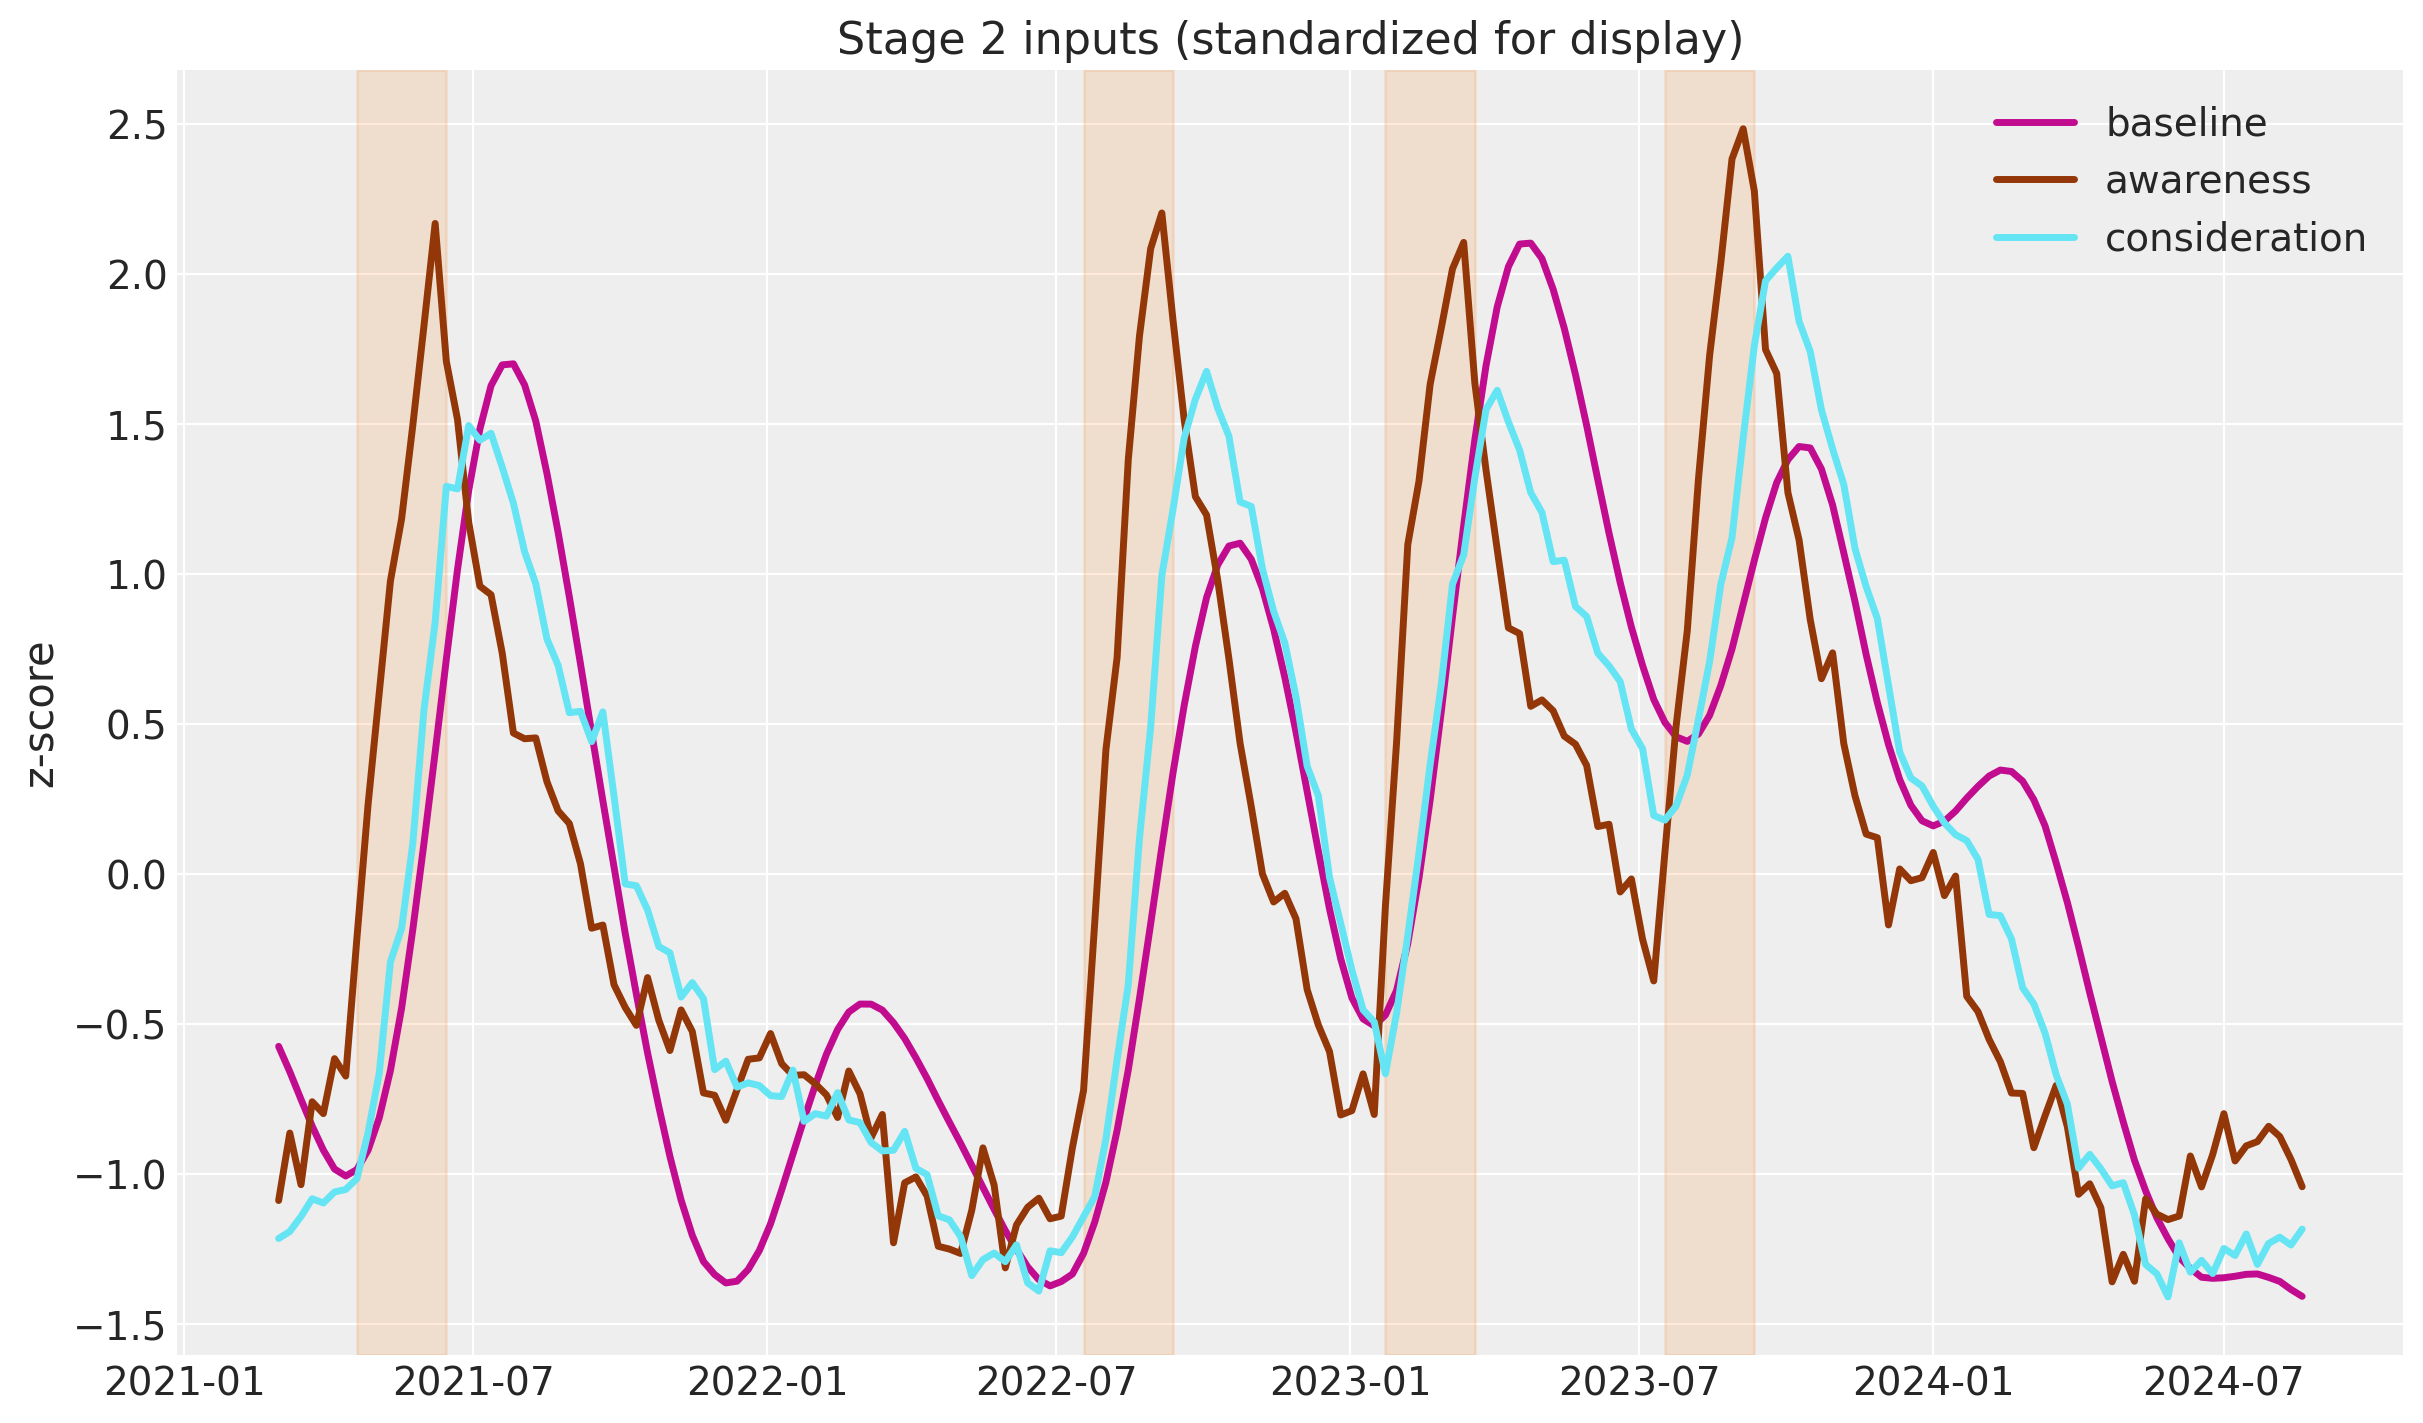

In [28]:
varx_df = pd.DataFrame(
    {
        "baseline": baseline_median.to_numpy(),
        "awareness": df["awareness"].to_numpy(),
        "consideration": df["consideration"].to_numpy(),
        "brand_spend": df["brand_spend"].to_numpy(),
    },
    index=pd.DatetimeIndex(df["date"], name="date"),
)

endog_vars = ["baseline", "awareness", "consideration"]

fig, ax = plt.subplots()
scaled = (varx_df[endog_vars] - varx_df[endog_vars].mean()) / varx_df[endog_vars].std()
for i, col in enumerate(endog_vars):
    ax.plot(varx_df.index, scaled[col], color=f"C{i + 3}", linewidth=2.5, label=col)

shade_flights(ax)
ax.legend(loc="upper right")
ax.set(
    title="Stage 2 inputs (standardized for display)",
    ylabel="z-score",
);

Awareness responds within each flight, consideration follows, and the baseline moves last: the funnel ordering is visible to the naked eye.

We treat this three-variable system as stationary and fit a **VAR in levels**, which is what the long-run multiplier requires: differencing would destroy the level relationships the multiplier is built from. The unit-root and cointegration diagnostics behind that choice, and the reason they are ambiguous on persistent marketing series, are collected in the appendix.

## Stage 2: Bayesian VARX with impulso

The model for the endogenous vector $z_t = (\text{baseline}_t, \text{awareness}_t, \text{consideration}_t)^\top$ is a one-lag VARX,

$$
z_t = a + A \, z_{t-1} + B_{\text{exog}} \, \text{brand}_t + \varepsilon_t,
\qquad \varepsilon_t \sim \text{MultivariateNormal}(0, \Sigma),
$$

with a Minnesota-style prior on the lag coefficients. Three features of this setup deserve emphasis:

- **No structural identification is needed.** For questions about shocks to *endogenous* variables a VAR needs identifying restrictions (Cholesky ordering, sign restrictions). Our question is about the *exogenous* input: brand spend is set by the planner's flight calendar, so the reduced-form coefficient $B_{\text{exog}}$ already has a causal interpretation, exactly as in {ref}`mmm_var_budget_optimization`.
- **Timing convention.** Brand spend enters contemporaneously, matching the data generating process where a flight lifts awareness within the same week.
- **Lag order: stay parsimonious.** Weekly funnel dynamics are well captured by a single lag, and every extra lag adds nine coefficients that must be pinned down by, effectively, four campaign flights. Information criteria are little help here, because the baseline series carries Stage-1 estimation error and the criteria respond to that autocorrelated noise by demanding *more* lags: the selection printed right after the fit reaches for several lags on this data, yet when we later run the same selection on the *noise-free* oracle inputs all three pick exactly one lag. The appetite for extra lags is created by the estimated baseline, not by the true dynamics. Use information criteria as a starting point with real data, but prefer the smallest lag order compatible with the dynamics you believe in, and check robustness to the choice.

**Do not shrink the effect you are trying to measure.** This principle sets two prior choices. For the exogenous block it is already impulso's default: the prior scale on $B_{\text{exog}}$ is left nearly flat, because $B_{\text{exog}}$ *is* the spend-to-funnel effect. But the same logic applies to the lag matrix $A$, and there the Minnesota default works against us. `MinnesotaPrior()` shrinks toward univariate random walks with tight, fixed scales (at the single lag we fit, sd $0.1$ on own lags and $0.05$ on cross lags; the class decays these harmonically over higher lags): calibrated for high-dimensional macro VARs, it would place the true funnel loadings of our generator (awareness $\to$ consideration $= 0.4$, consideration $\to$ baseline $= 0.6$) eight and twelve prior standard deviations away from the prior mean of zero, and the true baseline own-lag ($0.5$) five standard deviations below the random-walk mean of one. In a three-variable system with 182 observations that much shrinkage is not a safety net but a thumb on the scale, and the funnel transmission we are measuring lives precisely in those cross-lags. We therefore keep the random-walk prior *mean* and loosen the scales to a weakly informative sd of $0.5$ on every lag coefficient of the one lag we fit (`MinnesotaPrior(tightness=0.5, cross_shrinkage=1.0)`). The oracle comparison below quantifies what the default would have cost.

In [29]:
%%time
var_data = VARData.from_df(varx_df, endog=endog_vars, exog=["brand_spend"])

# Loosened Minnesota prior: same random-walk prior mean on own lags, but a flat
# sd of 0.5 on every lag coefficient (tightness=0.5, cross_shrinkage=1.0). The
# defaults (sd 0.1 on own lags, 0.05 on cross lags) would place the true funnel
# loadings 8 to 12 prior standard deviations away from the prior mean of zero;
# the oracle comparison below shows what that does to the estimates.
stage2_prior = MinnesotaPrior(tightness=0.5, cross_shrinkage=1.0)

varx = VAR(lags=1, prior=stage2_prior)
fitted = varx.fit(
    var_data,
    sampler=NUTSSampler(
        nuts_sampler="nutpie",
        draws=1_000,
        tune=1_000,
        chains=4,
        cores=4,
        target_accept=0.95,
        random_seed=seed + 1,
    ),
)

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

CPU times: user 20.4 s, sys: 554 ms, total: 21 s
Wall time: 6.88 s


In [30]:
# Lag-order selection on the estimated-baseline frame. The baseline carries
# Stage-1 estimation error, and the criteria respond to that autocorrelated
# noise by asking for more lags than the dynamics require; the oracle frame
# below is the counterfactual.
lag_selection = select_lag_order(var_data, max_lags=8)
print(
    "lag order on the estimated-baseline frame: "
    f"AIC {lag_selection.aic}, BIC {lag_selection.bic}, HQ {lag_selection.hq}"
)

lag order on the estimated-baseline frame: AIC 4, BIC 4, HQ 4


In [31]:
# The Cholesky factor of the error covariance has structural zeros above its
# diagonal with no within-chain variance, so the split-R-hat step hits a
# harmless 0/0; we silence that RuntimeWarning while checking diagnostics.
with warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    _ = az.diagnose(fitted.idata)

Divergences
No divergent transitions found.

E-BFMI
E-BFMI satisfactory for all chains.

ESS
Effective sample size satisfactory for all parameters.

R-hat
R-hat values satisfactory for all parameters.

Processing complete, no problems detected.


### Posterior Predictive Check

Convergence diagnostics say the sampler explored the posterior it was given; they say nothing about whether that posterior can reproduce the data. `FittedVAR.posterior_predictive` answers the second question by replicating the estimation sample draw by draw,

$$
y^{\text{rep}}_t = a + A \, z^{\text{obs}}_{t-1} + B_{\text{exog}} \, \text{brand}_t + L \, \varepsilon_t,
\qquad \varepsilon_t \sim \text{Normal}(0, I),
$$

where $z^{\text{obs}}_{t-1}$ stacks the **observed** lags. Each replicate is therefore one-step-ahead conditioned on the realized history, not a path simulated forward from initial conditions — that would be `forecast`, and it is a much harder test. The band below is essentially the innovation scale $L$, so what this check interrogates is whether the fitted residual covariance is honest about the noise, not whether the dynamics compound correctly.

It is worth running for a reason none of the checks that follow can claim: **it needs no ground truth**. Everything in the next section holds the estimate against a generator we happen to have because we simulated the data. This one is available on real data, which makes it the check a practitioner can actually perform.

Which is exactly why its verdict has to be read narrowly. Two cells from now we will find the baseline equation badly distorted: its own lag pushed toward one, the consideration loading collapsed to zero, a spurious awareness loading in its place. That distortion is a *reallocation* of one-step-ahead predictive power among coefficients, and one-step-ahead replication is blind to it — the coverage below comes out fine anyway. A model can replicate its own sample and still be wrong about where the effect travels, which is the same warning the `p_rope` discussion later delivers through a different door.

The nominal level here is a central 95% interval rather than the 94% HDI used elsewhere in the notebook, following impulso's coverage recipe: a coverage number only means something read against a central nominal level.

95% predictive band covers 96.3% of observations
  baseline: 97.8%
  awareness: 95.6%
  consideration: 95.6%


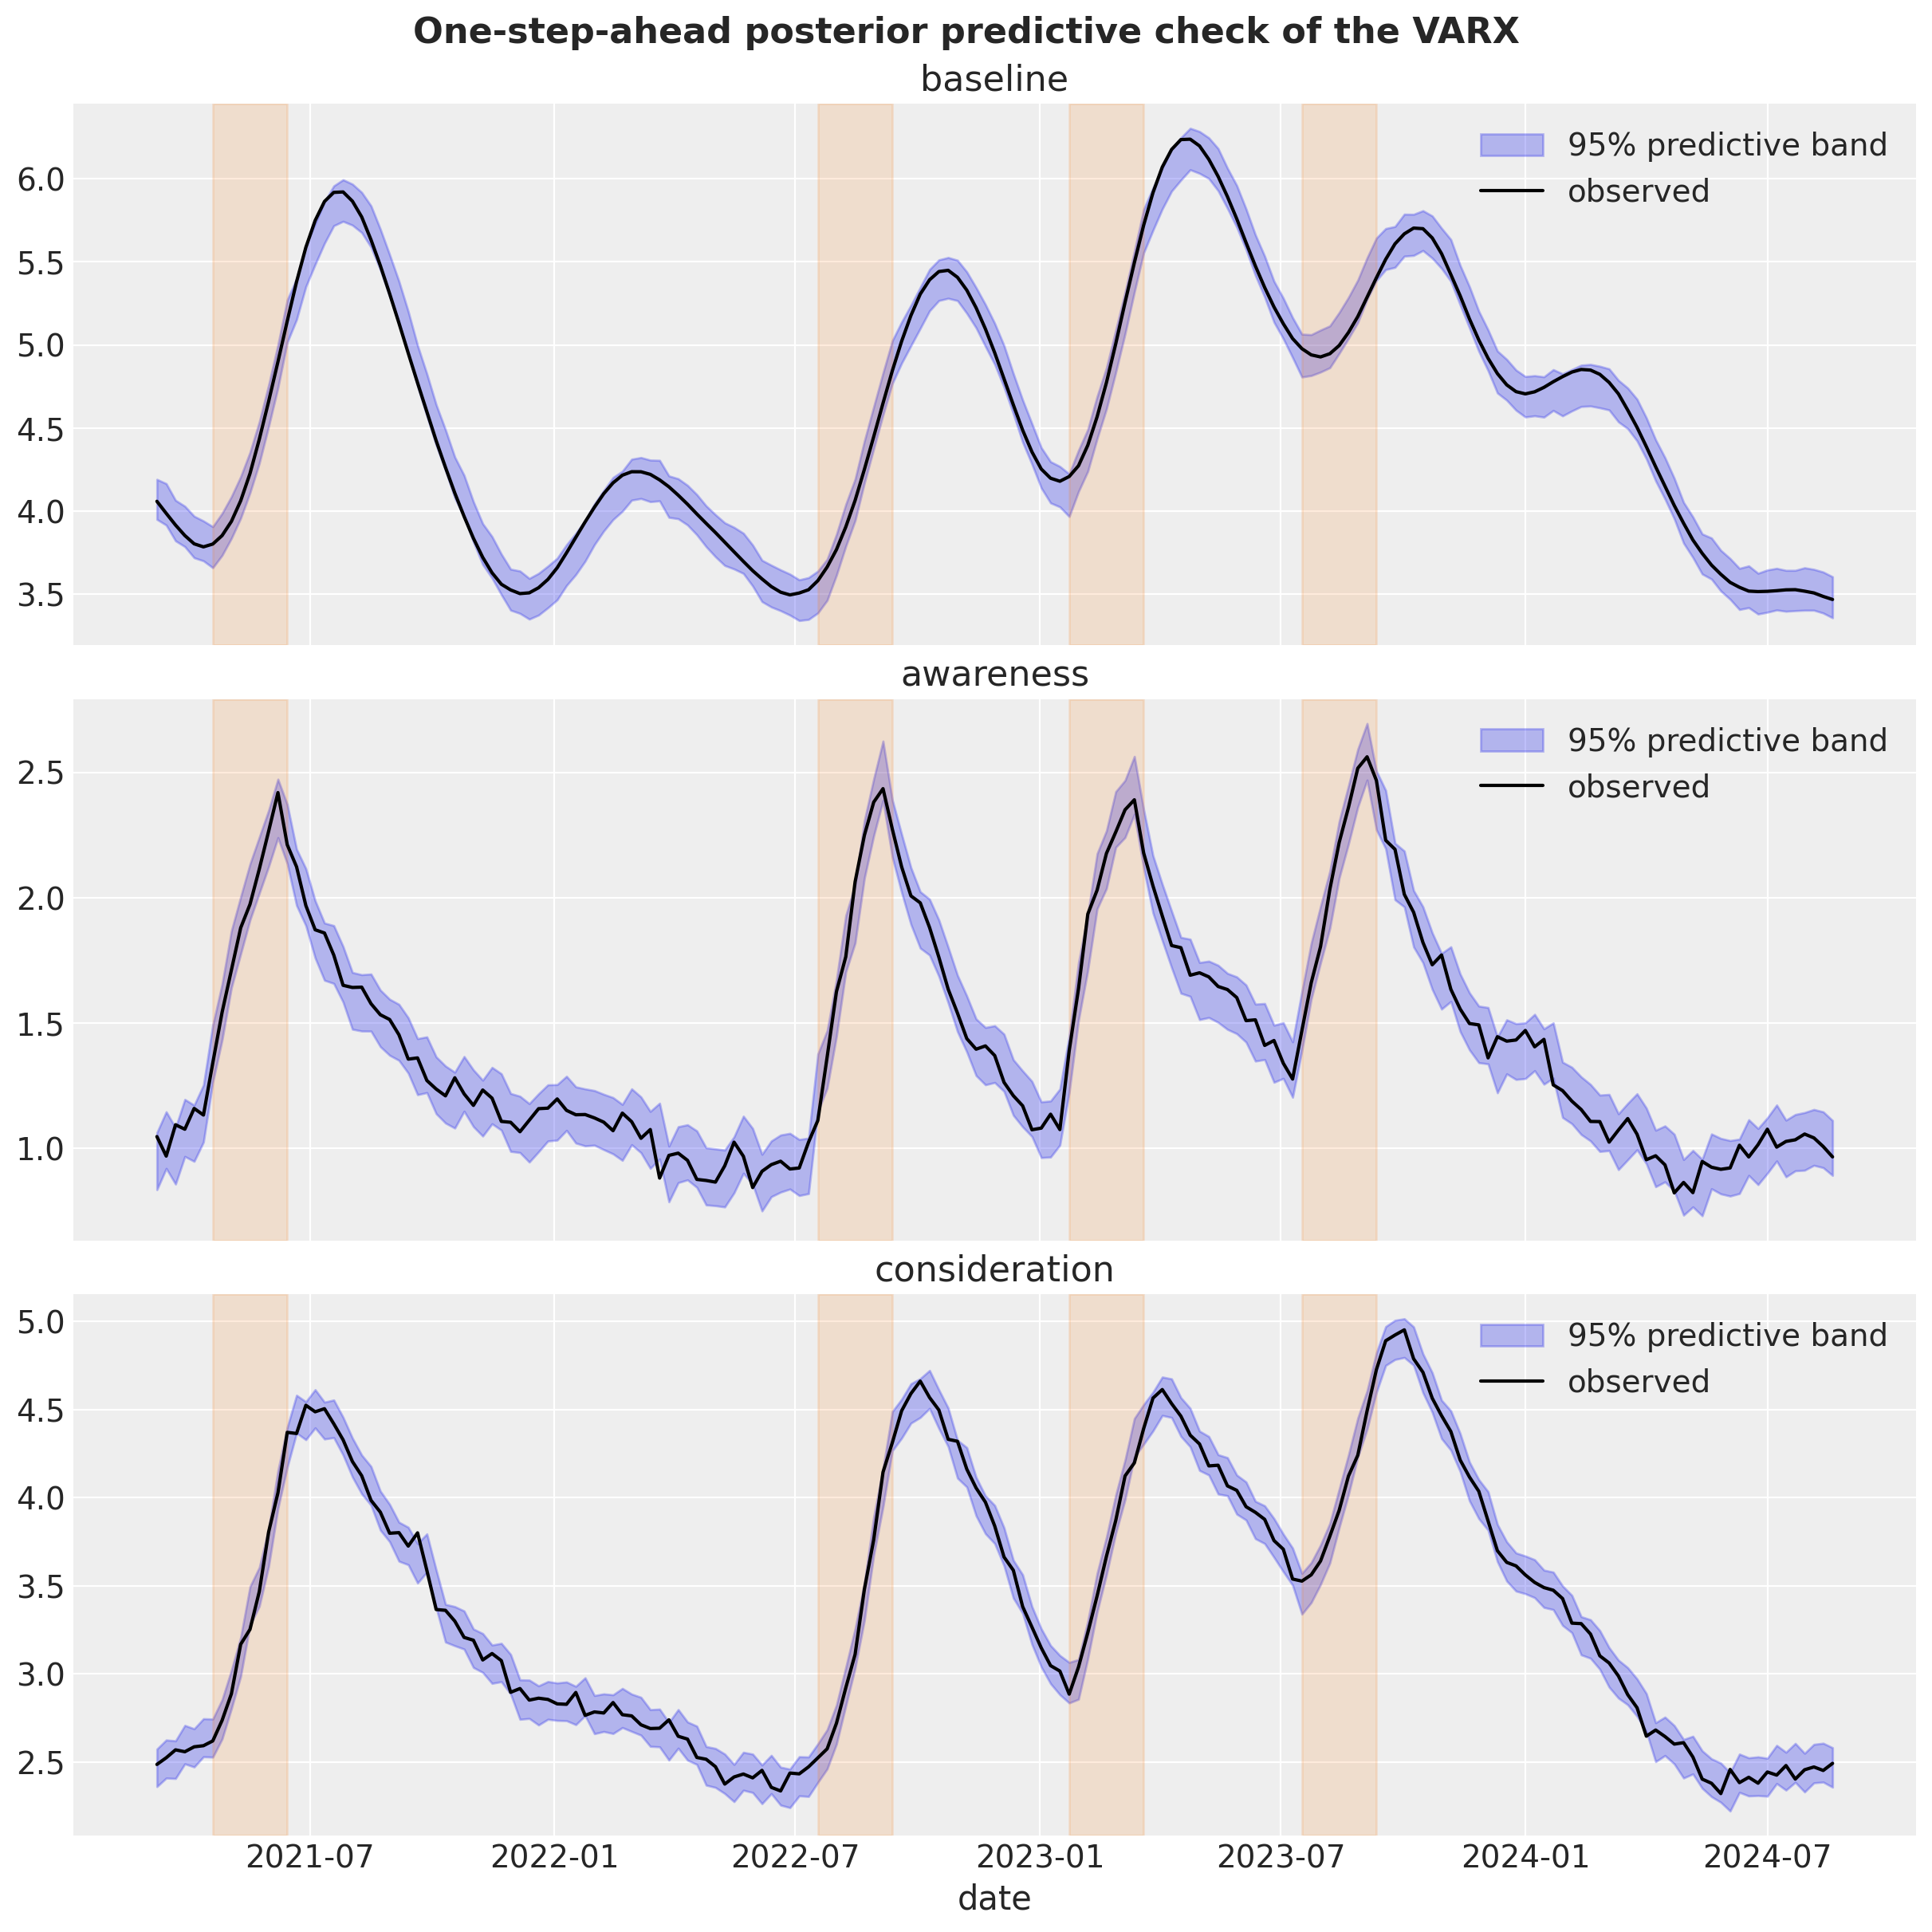

In [32]:
ppc = fitted.posterior_predictive(seed=seed + 2)
pp_obs = ppc["posterior_predictive"]["obs"]
observed_obs = ppc["observed_data"]["obs"]

band = pp_obs.quantile([0.025, 0.975], dim=("chain", "draw"))
lower, upper = band.sel(quantile=0.025), band.sel(quantile=0.975)
inside = (observed_obs >= lower) & (observed_obs <= upper)
print(f"95% predictive band covers {float(inside.mean()):.1%} of observations")
for response in endog_vars:
    print(f"  {response}: {float(inside.sel(var=response).mean()):.1%}")

fig, axes = plt.subplots(
    nrows=3, ncols=1, sharex=True, figsize=(12, 12), layout="constrained"
)
for ax, response in zip(axes, endog_vars, strict=True):
    ax.fill_between(
        pp_obs["time"],
        lower.sel(var=response),
        upper.sel(var=response),
        alpha=0.3,
        color="C0",
        label="95% predictive band",
    )
    ax.plot(
        pp_obs["time"],
        observed_obs.sel(var=response),
        color="black",
        linewidth=1.5,
        label="observed",
    )
    shade_flights(ax)
    ax.legend(loc="upper right")
    ax.set(title=response)
axes[-1].set(xlabel="date")
fig.suptitle(
    "One-step-ahead posterior predictive check of the VARX",
    fontsize=16,
    fontweight="bold",
);

The band covers $96.3\%$ of the sample against a nominal $95\%$, split $97.8\%$ on the baseline and $95.6\%$ on each survey. Before reading anything into the gap, note how precisely a coverage number can be read at all: with $181$ dates per series, the binomial standard error at $p = 0.95$ is about $1.6$ percentage points, so every one of these sits within roughly one standard error of nominal — and that figure is generous, because consecutive weeks are not independent. The fitted innovation covariance is not detectably over- or under-dispersed, and the observed paths stay inside the band through the flight windows as well as between them.

Take the verdict for exactly what it is worth: the model is not misspecified in a way that shows up one step ahead. The next section asks the harder question.

In [33]:
az.summary(fitted.idata, var_names=["B_exog"])

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
"B_exog[baseline, brand_spend]",-0.0148,0.0171,-0.042,0.013,3499,3545,1.00,0.00029,0.0002
"B_exog[awareness, brand_spend]",0.2606,0.0156,0.24,0.29,3379,2869,1.00,0.00027,0.00019
"B_exog[consideration, brand_spend]",0.0039,0.0148,-0.02,0.027,3324,3210,1.00,0.00026,0.00019


The posterior on $B_{\text{exog}}$ already shows the funnel at work: brand spend moves awareness contemporaneously ($0.260 \pm 0.015$ against a true $\gamma = 0.25$) and barely touches consideration or the baseline within the week (posterior means $0.004$ and $-0.015$, against true values of zero), matching the generating process, where the effect on sales arrives only through the lagged funnel. The long-term story therefore lives in the *dynamic multiplier*, which is worth unpacking step by step.

A stationary VAR can be rewritten in its moving-average form: today's state is a weighted sum of all past inputs, $z_t = \sum_{h \ge 0} \Phi_h \left( B_{\text{exog}} \, \text{brand}_{t-h} + \varepsilon_{t-h} \right) + \dots$, where the MA matrices follow the recursion $\Phi_0 = I$ and $\Phi_h = \sum_{j=1}^{p} A_j \Phi_{h-j}$ built from the estimated lag matrices $A_j$. The **dynamic multiplier** at horizon $h$ is

$$
\Psi_h = \Phi_h B_{\text{exog}}, \qquad h = 0, 1, 2, \dots
$$

and it answers a precise counterfactual: *if we add one unit of brand spend this week and change nothing else, how much higher are the baseline, awareness, and consideration $h$ weeks from now?* At $h=0$ it is just $B_{\text{exog}}$ (the same-week effect); at larger $h$ the impulse travels through the estimated lag structure (spend lifts awareness, lagged awareness feeds consideration, lagged consideration feeds the baseline) and gradually decays as the stationary system reverts to its mean. That decay is a property of the *estimated* system, not of the input series the stationarity diagnostics in the appendix interrogate, so we check it directly: the cell after the lag-matrix comparison below reports the spectral radius of the fitted companion matrix per posterior draw, together with the share of draws at or above one. Only radii below one give the convergent moving-average sum this construction assumes. Measuring long-run response through the persistence of a fitted dynamic system follows Dekimpe and Hanssens (1999). The cumulative sum $\sum_{j=0}^{h} \Psi_j$ is the **total** incremental effect realized within $h$ weeks per unit of spend, which at $h = 26$ becomes our long-term brand ROI. Because brand spend is exogenous, no structural identification is needed for this to carry a causal reading.

impulso computes this for every posterior draw with `FittedVAR.dynamic_multiplier`, so the multiplier inherits full posterior uncertainty from $A$ and $B_{\text{exog}}$. It returns a `DynamicMultiplierResult`, whose `median()` and `hdi()` summaries are the quickest read; the tiny helper below reaches past them for the raw draws, because everything downstream (mixing in Stage-1 uncertainty, convolving with the spend path) needs the full posterior rather than a summary. The method also takes `cumulative=True` for the step response directly; we ask for the per-horizon draws instead and accumulate them ourselves.

We keep the per-horizon draws (`theta_plugin`) for the in-sample decomposition later and accumulate them over the horizon for the ROI story.

In [34]:
def dynamic_multiplier_draws(fitted_var, horizon: int) -> xr.DataArray:
    """Per-draw dynamic multiplier ``Psi_h = Phi_h @ B_exog`` for ``h = 0..horizon``."""
    result = fitted_var.dynamic_multiplier(horizon=horizon)
    return result.idata["posterior_predictive"]["dynamic_multiplier"]


def posterior_spectral_radius(fitted_var) -> xr.DataArray:
    """Per-draw spectral radius of the fitted VAR's companion matrix.

    The moving-average representation the dynamic multiplier is built on only
    converges for a stationary system, i.e. a spectral radius below one. The
    stationarity diagnostics in the appendix interrogate the *input series*;
    this checks the *estimated* system, which the multiplier propagates.
    """
    B_draws = (
        fitted_var.idata.posterior["B"]
        .transpose("chain", "draw", "var", "coeff")
        .values
    )
    lags = lag_matrices(B_draws, n_lags=fitted_var.n_lags)
    n_chain, n_draw, k, _ = lags[0].shape
    n_lag = len(lags)
    companion = np.zeros((n_chain, n_draw, k * n_lag, k * n_lag))
    companion[..., :k, :] = np.concatenate(lags, axis=-1)
    if n_lag > 1:
        idx = np.arange(k * (n_lag - 1))
        companion[..., k + idx, idx] = 1.0
    radius = np.abs(np.linalg.eigvals(companion)).max(axis=-1)
    return xr.DataArray(radius, dims=("chain", "draw"), name="spectral_radius")


# Plug-in multiplier: conditioned on the single median-baseline VARX fit.
theta_plugin = dynamic_multiplier_draws(fitted, horizon=horizon)
cum_multiplier_plugin = theta_plugin.cumsum("horizon")

expected_plugin_sizes = {
    "chain": 4,
    "draw": 1_000,
    "horizon": horizon + 1,
    "response": 3,
    "exog": 1,
}
if dict(theta_plugin.sizes) != expected_plugin_sizes:
    raise ValueError(f"unexpected plug-in multiplier shape: {dict(theta_plugin.sizes)}")

### Validating the estimated system against the truth

Because we simulated the data, we can hold the estimated lag matrix against the generator, exactly as we did for the Stage-1 parameters. In the $(\text{baseline}, \text{awareness}, \text{consideration})$ ordering the true system is

$$
A = \begin{pmatrix} 0.5 & 0 & 0.6 \\ 0 & 0.9 & 0 \\ 0 & 0.4 & 0.8 \end{pmatrix},
\qquad
B_{\text{exog}} = \begin{pmatrix} 0 \\ 0.25 \\ 0 \end{pmatrix},
$$

so the VARX specification is not an approximation of the funnel: it is *exactly* the generating equation, and any estimation gap must come from the inputs, the prior, or sampling noise.

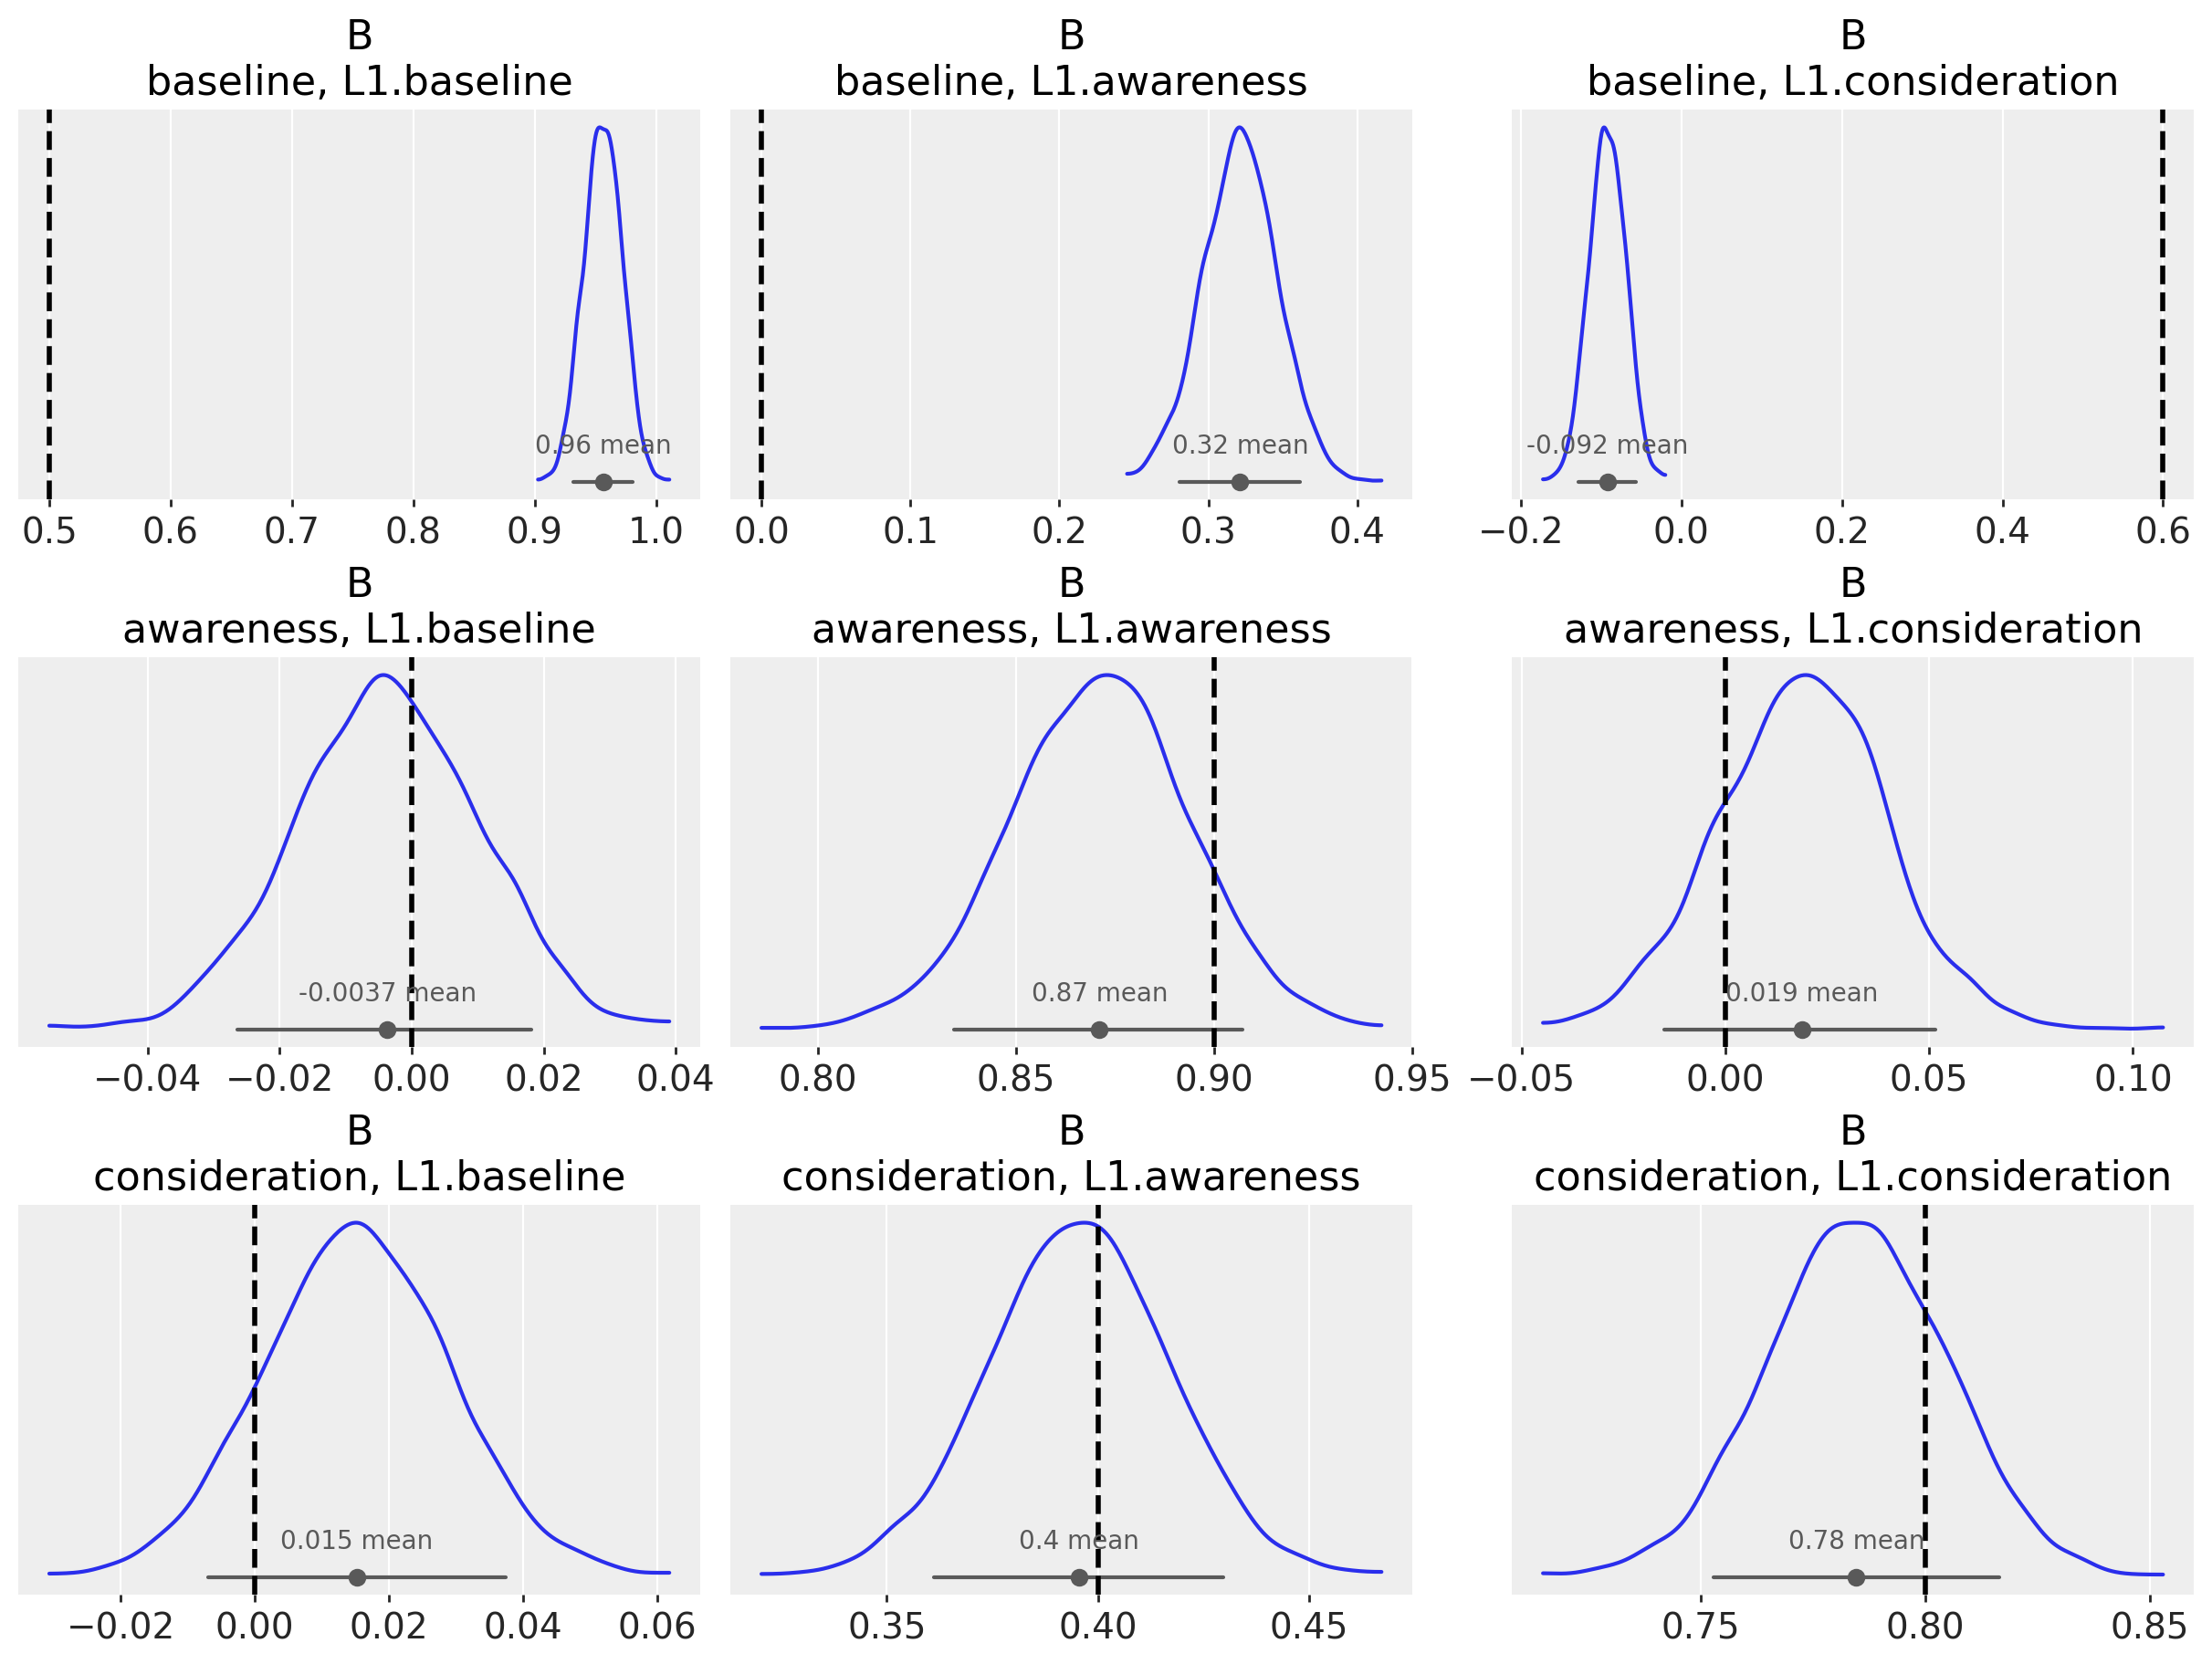

In [35]:
pc = az.plot_dist(
    fitted.idata,
    var_names=["B"],
    group="posterior",
    figure_kwargs={"figsize": (12, 9)},
    col_wrap=3,
)
a_true = {
    ("baseline", "L1.baseline"): 0.5,
    ("baseline", "L1.awareness"): 0.0,
    ("baseline", "L1.consideration"): 0.6,
    ("awareness", "L1.baseline"): 0.0,
    ("awareness", "L1.awareness"): 0.9,
    ("awareness", "L1.consideration"): 0.0,
    ("consideration", "L1.baseline"): 0.0,
    ("consideration", "L1.awareness"): 0.4,
    ("consideration", "L1.consideration"): 0.8,
}
for (var, coeff), true_val in a_true.items():
    ax = pc.viz["plot"]["B"].sel(var=var, coeff=coeff).item()
    ax.axvline(true_val, color="black", linestyle="--", linewidth=2)

In [36]:
radius_plugin = posterior_spectral_radius(fitted)
radius_hdi = az.hdi(radius_plugin, prob=0.94)
print(
    "plug-in fit, spectral radius of the estimated system (true 0.90): "
    f"median {float(radius_plugin.median()):.3f}, 94% HDI "
    f"[{float(radius_hdi.sel(ci_bound='lower')):.3f}, "
    f"{float(radius_hdi.sel(ci_bound='upper')):.3f}]"
)
print(
    "share of draws with radius >= 1 (non-stationary): "
    f"{float((radius_plugin >= 1).mean()):.2%}"
)

plug-in fit, spectral radius of the estimated system (true 0.90): median 0.949, 94% HDI [0.921, 0.983]
share of draws with radius >= 1 (non-stationary): 0.33%


The awareness and consideration equations (middle and bottom rows) recover the truth: their own lags and the awareness $\to$ consideration link sit on top of the dashed lines, and the structurally zero entries concentrate near zero. The baseline equation (top row) is visibly distorted: its own lag is estimated near $0.95$ (true $0.5$), the consideration loading collapses to zero (posterior mean $-0.09$, true $0.6$), and a spurious awareness loading of about $0.32$ appears (true $0$). The estimated system has, in effect, traded the funnel transmission into the baseline for baseline *persistence*.

The spectral radius printed above is that same distortion seen from another angle. The true system has a radius of $0.90$, set by the awareness own-lag, but the estimate sits entirely above it: median $0.949$ with a 94% HDI of $[0.921, 0.983]$, so the truth falls outside the interval. Pushing the baseline own-lag close to one makes the whole system more persistent than it really is. It does stay below one, which is what the multiplier construction needs, and only a third of a percent of draws cross that line. That share grows once we refit across baseline draws in the last section, which is where the 26-week truncation starts to earn its keep.

Before localizing that distortion, it is worth reading the same fit through a lens that speaks directly to the funnel ordering we assumed when we built the frame.

### Granger Causality and the Funnel Ordering

The $B$ posterior above is the estimated system read coefficient by coefficient. The same fit answers a question that speaks more directly to the funnel: **do the lags of one series help predict another, beyond that series' own past?** That is Granger causality, and `FittedVAR.granger_causality` reports it as a posterior for a *magnitude* rather than as a test statistic.

For an ordered pair (cause $\to$ effect) it returns the posterior of $\lVert b \rVert$, the Euclidean norm of the lags of the cause appearing in the effect's equation. With one lag that is simply $\lvert A_{\text{effect},\,\text{cause}} \rvert$, so the table below is an uncertainty-aware read of the off-diagonal entries of $A$. Its `summary()` gives the median, HDI, and `p_rope` per pair, with one row for each tested lag plus a `norm` row aggregating them; at a single lag those rows carry the same information (the per-lag row keeps the sign, the norm does not), so we assemble the table below from the `norm` row of each pair. Nothing divides through by the posterior covariance, which keeps "the effect is small" distinguishable from "the effect is imprecisely estimated" — the distinction a Wald-style statistic deliberately collapses. The default `standardize=True` multiplies the draws by $\mathrm{sd}(\text{cause}) / \mathrm{sd}(\text{effect})$, so magnitudes read as standard deviations of the effect per standard deviation of the cause. That matters because `baseline` is in sales units while `awareness` and `consideration` are proportions; we put the true entries in the same standardized units so the comparison is like for like.

**The ROPE.** A region of practical equivalence has to be chosen, and impulso deliberately ships no default, because there is no data-free notion of "small enough". We set it to $0.05$ standard deviations: a one-sd move in the cause shifts the effect by less than a twentieth of a standard deviation. `p_rope` is then $P(\lVert b \rVert < 0.05 \mid \text{data})$, and it must be read for exactly that. It is **not** $P(\text{no causality})$ and it is not a Bayes factor: under continuous coefficient priors the event $b = 0$ has probability zero both before and after seeing the data, so no dataset can raise it. What it quantifies is the posterior probability that the link is *practically* negligible at the magnitude we declared.

Two caveats carry over from the causal framing at the top of the notebook. Granger causality is conditional predictive precedence *within this set of variables*, not intervention: an omitted common driver is enough to manufacture it. And only the endogenous block is testable, since `brand_spend` enters as an exogenous regressor with no lags of its own. Its long-run effect is the dynamic multiplier, not a Granger statement.


In [37]:
rope_granger = 0.05

granger_rows = []
for cause in endog_vars:
    for effect in endog_vars:
        if cause == effect:
            continue
        result = fitted.granger_causality(cause=cause, effect=effect, rope=rope_granger)
        # `summary()` reports one row per tested lag plus a `norm` row; at a
        # single lag the two carry the same information, so we keep the norm.
        norm_row = result.summary(prob=0.94).loc["norm"]
        true_entry = a_true[(effect, f"L1.{cause}")]
        granger_rows.append(
            {
                "cause": cause,
                "effect": effect,
                "true": true_entry,
                "true_std": abs(true_entry) * result.scale,
                "median": norm_row["median"],
                "hdi_lower": norm_row["hdi_lower"],
                "hdi_upper": norm_row["hdi_upper"],
                "p_rope": norm_row["p_rope"],
            }
        )

granger_table = pd.DataFrame(granger_rows).set_index(["cause", "effect"]).round(3)
granger_table

true  true_std  median  hdi_lower  hdi_upper  \
cause         effect                                                        
baseline      awareness       0.0     0.000   0.017      0.000      0.047   
              consideration   0.0     0.000   0.016      0.000      0.038   
awareness     baseline        0.0     0.000   0.185      0.157      0.212   
              consideration   0.4     0.239   0.236      0.211      0.259   
consideration baseline        0.6     0.577   0.089      0.046      0.128   
              awareness       0.0     0.000   0.034      0.000      0.084   

                             p_rope  
cause         effect                 
baseline      awareness       0.953  
              consideration   0.989  
awareness     baseline        0.000  
              consideration   0.000  
consideration baseline        0.036  
              awareness       0.693

The table validates the funnel ordering where the funnel is measured cleanly, and independently reproduces the distortion we just diagnosed where it is not.

Start with what works. The awareness $\to$ consideration link, the one genuine within-funnel transmission the generator writes down, comes back at $0.236$ against a standardized truth of $0.239$, with a 94% HDI of $[0.211, 0.259]$ and `p_rope` essentially zero. Three of the four structurally zero links behave as they should: both edges out of `baseline` sit at $0.017$ and $0.016$ with 95% and 99% of their posterior mass inside the ROPE, and consideration $\to$ awareness sits at $0.034$ with 69%. The funnel is not a cycle, and the fit says so.

The remaining two rows are the baseline equation, and they fail exactly as the $B$ posterior said they would, now stated in the ROPE's language. The real funnel entry, consideration $\to$ baseline, has a standardized truth of $0.577$ and is estimated at $0.089$: an order of magnitude too small, with 3.6% of its mass inside the ROPE, so it clears the practical-negligibility bar almost by accident. Meanwhile awareness $\to$ baseline, which is *exactly zero* in the generator, comes back at $0.185$ with a 94% HDI of $[0.157, 0.212]$, nowhere near the ROPE, and `p_rope` of $0.000$. Taken at face value the fit declares a strong Granger-causal link that does not exist, and calls the one that does nearly negligible.

That is worth sitting with, because it is the honest failure mode of the exercise rather than a defect of the diagnostic. `p_rope` is a posterior probability *conditional on the model and its inputs*, and the input here is a smoothed Stage-1 baseline. Feed it a distorted series and it reports the distortion confidently: the interval is narrow, the verdict is wrong, and nothing inside the Stage-2 fit can tell the difference. A small `p_rope` is no protection against a mis-measured variable. It is the same warning as "predictive precedence, not intervention", arriving through a different door.


Is that distortion caused by Stage 1 (the smoothed baseline we feed in) or by Stage 2 (the prior or the sampler)? Because the data are simulated we can settle it with *oracle* refits of the identical VARX on progressively cleaner inputs: first swap in only the true baseline while keeping the noisy surveys (isolating the Stage-1 baseline-extraction error), then swap in the latent surveys as well (isolating Stage-2 recovery under a perfect Stage 1). Finally, we refit the fully clean frame with the *default* Minnesota prior, to put a number on the shrinkage argument made above. Each fit costs a few seconds. We also rerun the lag-order selection on the clean frame.


In [38]:
%%time
oracle_index = pd.DatetimeIndex(df["date"], name="date")


def fit_oracle_varx(frame: pd.DataFrame, random_seed: int, prior=None):
    return VAR(lags=1, prior=prior if prior is not None else stage2_prior).fit(
        VARData.from_df(frame, endog=endog_vars, exog=["brand_spend"]),
        sampler=NUTSSampler(
            nuts_sampler="nutpie",
            draws=1_000,
            tune=1_000,
            chains=4,
            cores=4,
            target_accept=0.95,
            random_seed=random_seed,
        ),
    )


# True baseline, still-noisy surveys: isolates Stage-1 baseline-extraction error.
oracle_baseline_df = pd.DataFrame(
    {
        "baseline": truth_df["base_sales"].to_numpy(),
        "awareness": df["awareness"].to_numpy(),
        "consideration": df["consideration"].to_numpy(),
        "brand_spend": df["brand_spend"].to_numpy(),
    },
    index=oracle_index,
)
# True baseline and latent surveys: isolates Stage-2 recovery under a perfect Stage 1.
oracle_full_df = pd.DataFrame(
    {
        "baseline": truth_df["base_sales"].to_numpy(),
        "awareness": truth_df["awareness_latent"].to_numpy(),
        "consideration": truth_df["consideration_latent"].to_numpy(),
        "brand_spend": df["brand_spend"].to_numpy(),
    },
    index=oracle_index,
)

fitted_oracle_baseline = fit_oracle_varx(oracle_baseline_df, seed + 7)
fitted_oracle_full = fit_oracle_varx(oracle_full_df, seed + 8)
fitted_oracle_default_prior = fit_oracle_varx(
    oracle_full_df, seed + 9, prior="minnesota"
)

oracle_lag_selection = select_lag_order(
    VARData.from_df(oracle_full_df, endog=endog_vars, exog=["brand_spend"]),
    max_lags=8,
)
print(
    "lag order on the oracle frame: "
    f"AIC {oracle_lag_selection.aic}, "
    f"BIC {oracle_lag_selection.bic}, "
    f"HQ {oracle_lag_selection.hq}"
)


def _oracle_row(fitted_var) -> dict[str, float]:
    post = fitted_var.idata.posterior
    cum_baseline = (
        dynamic_multiplier_draws(fitted_var, horizon=horizon)
        .cumsum("horizon")
        .sel(response="baseline", exog="brand_spend", horizon=horizon)
    )
    return {
        "A[base, base] (true 0.5)": float(
            post["B"].sel(var="baseline", coeff="L1.baseline").median()
        ),
        "A[base, cons] (true 0.6)": float(
            post["B"].sel(var="baseline", coeff="L1.consideration").median()
        ),
        f"{horizon}-week multiplier (true {true_long_term_roi:.2f})": float(
            cum_baseline.median()
        ),
    }


oracle_comparison = pd.DataFrame(
    {
        "plug-in (median baseline)": _oracle_row(fitted),
        "oracle: true baseline": _oracle_row(fitted_oracle_baseline),
        "oracle: true baseline + surveys": _oracle_row(fitted_oracle_full),
        "oracle + surveys, default Minnesota": _oracle_row(fitted_oracle_default_prior),
    }
).T

oracle_comparison.round(3)

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]


Output()

lag order on the oracle frame: AIC 1, BIC 1, HQ 1
CPU times: user 1min 27s, sys: 1.6 s, total: 1min 28s
Wall time: 26.9 s


,"A[base, base] (true 0.5)","A[base, cons] (true 0.6)",26-week multiplier (true 5.15)
plug-in (median baseline),0.956,-0.092,4.896
oracle: true baseline,0.544,0.538,5.123
oracle: true baseline + surveys,0.494,0.622,5.208
"oracle + surveys, default Minnesota",0.675,0.328,5.239


The comparison localizes each source of error, and the lag-order print above already settles one question: on the clean frame all three information criteria choose exactly one lag, so their earlier appetite for extra lags was manufactured by the estimated baseline, not by the dynamics.

Reading the table row by row: the plug-in fit inherits a badly distorted lag matrix, with the baseline own-lag pushed close to one and the consideration loading pulled to the wrong side of zero, yet its 26-week multiplier still lands within a few percent of the true $5.15$. That agreement is *not* the system being pinned down. It is two large errors cancelling: with the consideration loading negative, the positive multiplier is produced almost entirely by the spurious awareness loading, and the near-unit own-lag then amplifies whatever it is given. Both the sign and the magnitude of the total are hostage to the worst-estimated coefficient in the matrix, which is why the mixed interval in the final section is so much wider than the plug-in one: the same sensitivity resurfaces as soon as we stop conditioning on a single baseline. Read the aggregate as having survived here, not as having been identified. Swapping in the true baseline (row two) snaps the lag coefficients back to the truth ($0.54$ and $0.54$) and the multiplier to $5.12$; adding the latent surveys as well (row three) gives $0.49$ and $0.62$ with a multiplier of $5.21$. In other words, essentially the entire coefficient distortion is Stage-1 smoothing error, and survey measurement noise costs almost nothing on this data.

The last row is the shrinkage argument made concrete. With the same clean inputs, the default Minnesota prior drags the consideration $\to$ baseline loading from $0.62$ down to $0.33$ (true $0.6$) while inflating the baseline own-lag toward its random-walk prior mean ($0.68$ against a true $0.5$). The two distortions partly offset in the *aggregate* multiplier, which is why headline numbers alone would hide the problem, but they misstate the transmission mechanism: with the default prior you would conclude that base sales are intrinsically persistent and only weakly coupled to consideration, when in truth the persistence is moderate and the funnel coupling strong. If the goal were only the total multiplier the default would be survivable; for any question about *where* the effect travels (which is what a funnel model is for), it is not.

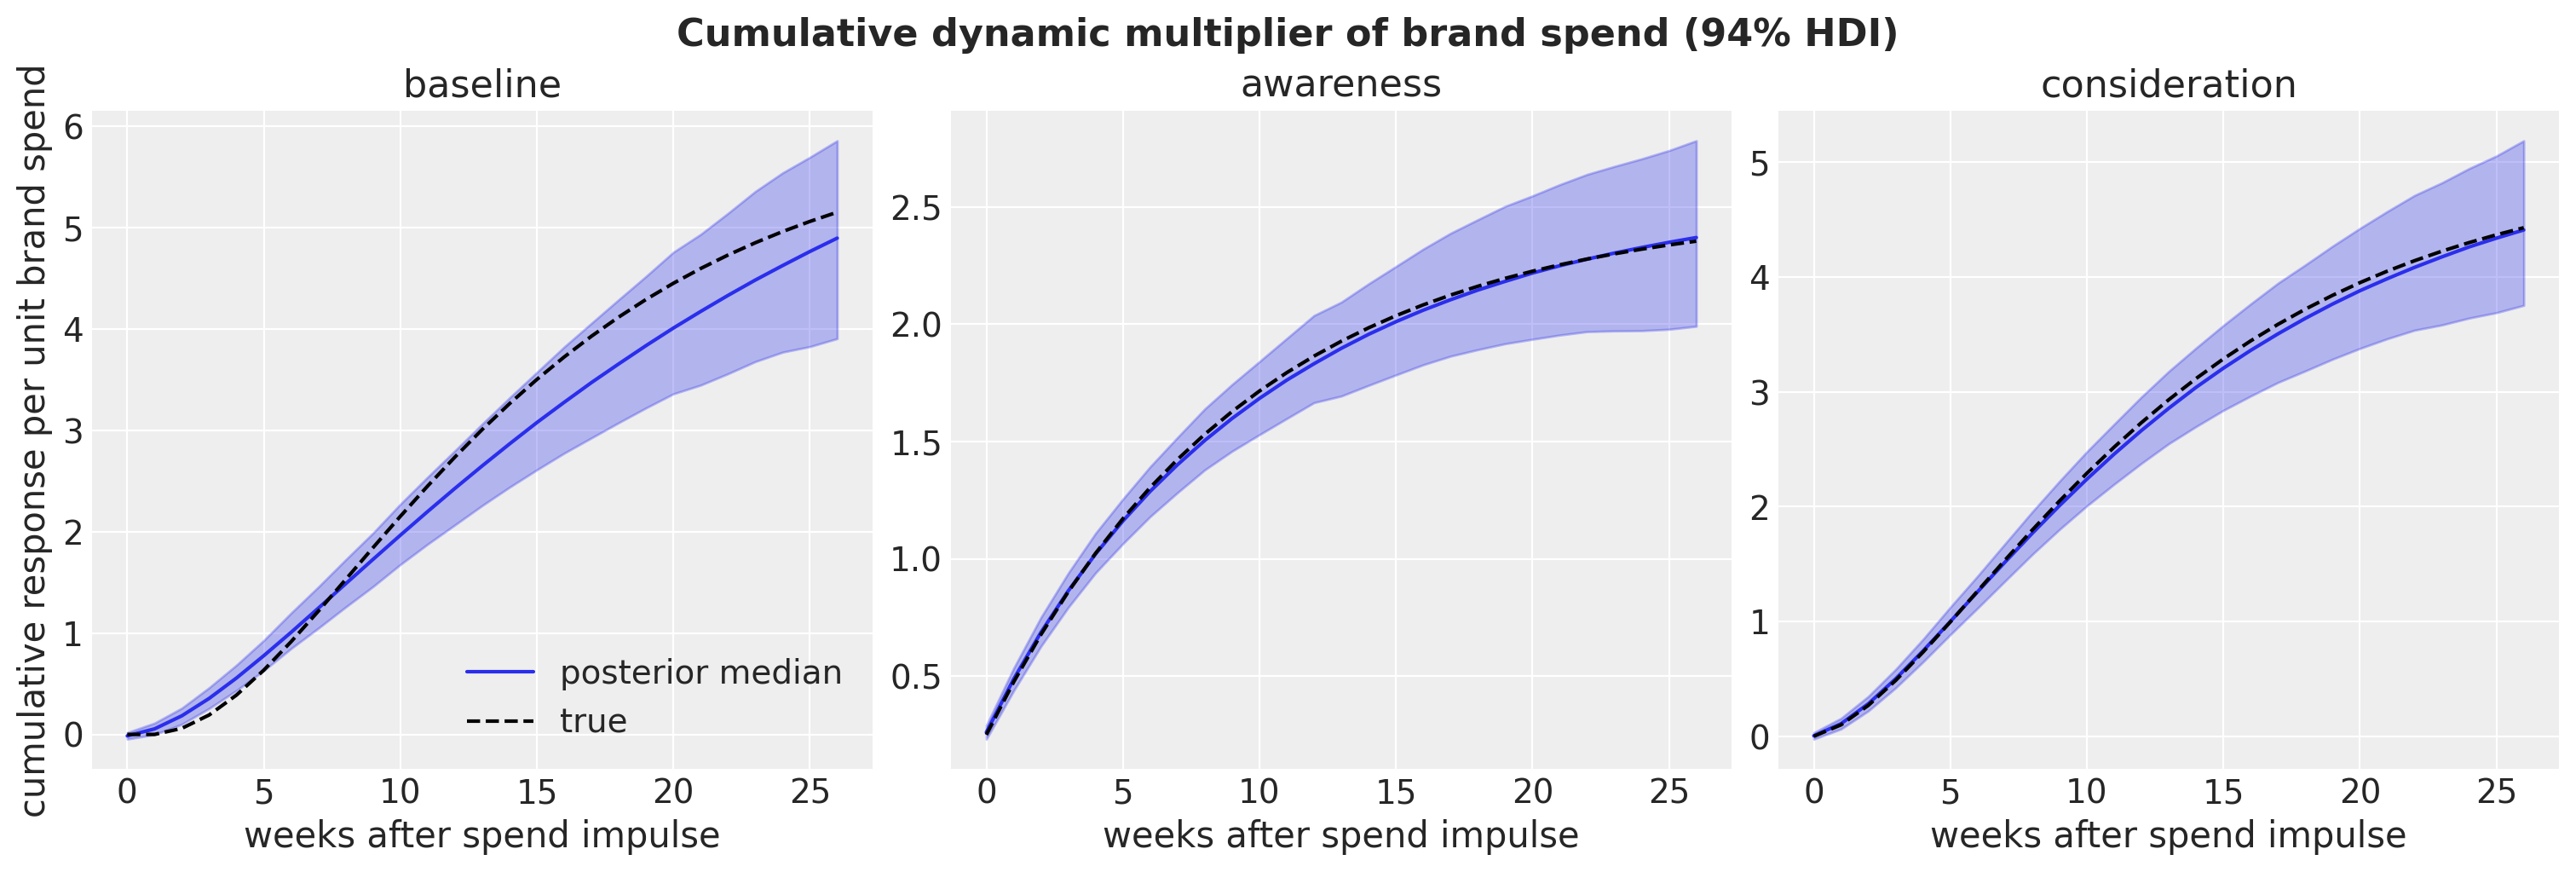

In [39]:
true_curves = {
    "baseline": np.cumsum(impulse_b),
    "awareness": np.cumsum(impulse_a),
    "consideration": np.cumsum(impulse_c),
}

fig, axes = plt.subplots(
    nrows=1, ncols=3, figsize=(15, 5), sharex=True, layout="constrained"
)
for ax, response in zip(axes, ["baseline", "awareness", "consideration"], strict=True):
    curve = cum_multiplier_plugin.sel(response=response, exog="brand_spend")
    median = curve.median(dim=("chain", "draw"))
    hdi = az.hdi(curve, prob=0.94)
    ax.fill_between(
        curve["horizon"],
        hdi.sel(ci_bound="lower"),
        hdi.sel(ci_bound="upper"),
        alpha=0.3,
        color="C0",
    )
    ax.plot(curve["horizon"], median, color="C0", label="posterior median")
    ax.plot(
        curve["horizon"],
        true_curves[response],
        color="black",
        linestyle="--",
        label="true",
    )
    ax.set(title=response, xlabel="weeks after spend impulse")
axes[0].set(ylabel="cumulative response per unit brand spend")
axes[0].legend(loc="lower right")
fig.suptitle(
    "Cumulative dynamic multiplier of brand spend (94% HDI)",
    fontsize=16,
    fontweight="bold",
);

The recovered multiplier tracks the *shape* of the truth for all three responses: awareness jumps on impact and decays, consideration builds with a delay, and the baseline accumulates slowly toward its long-run level. Two cautions before celebrating. First, at short horizons the estimated baseline response rises a little earlier than the truth: the smoothed Stage-1 baseline spreads each flight's effect across neighboring weeks, so part of the delayed funnel response is read as arriving sooner (the flip side of the distorted lag matrix diagnosed above). Second, this band is a *plug-in* band: it conditions on a single baseline (the Stage-1 posterior median) and therefore carries Stage-2 sampling uncertainty only. It is not yet the interval we will report; the honest headline, which also propagates Stage-1 uncertainty, comes two steps below.

## Total Effect and ROI Decomposition

Two related but distinct quantities can now be reported, and it is worth being pedantic about the difference:

1. **Forward-looking brand ROI.** The cumulative multiplier at $h = 26$ is the incremental base sales generated within 26 weeks per incremental unit of brand spend. This is the decision-relevant number for planning the next campaign. It deliberately truncates the tail (about 14% of the effect in our simulation).
2. **In-sample brand contribution.** For a decomposition of *observed, historical* sales we convolve the actual spend path with the per-week multiplier, crediting each week of spend with its response over the following 26 weeks. The convolution is what produces a weekly contribution *path*, which is what the decomposition plot needs, and it imposes two disciplines on the total: each week of spend is credited only with the response the calendar leaves room for before the sample ends, and we never extrapolate the fitted VAR beyond the 26-week window, where posterior draws with near-unit persistence would compound into fragile long-tail credit. On this data the first discipline happens to be free. The last flight ends fifty weeks before the sample does, so every flight pays out in full and the convolved total comes out exactly equal to total spend times the cumulative multiplier. Had a campaign run into the final 26 weeks the two would part company, and only the convolution would be right.

Before quoting a headline number, one more step. Everything so far conditions on a *single* baseline (the Stage-1 posterior median), so the multiplier's credible band reflects only Stage-2 sampling uncertainty and ignores the Stage-1 estimation error entirely. That is the generic plug-in problem of any two-step procedure. We fix it directly: refit the VARX on a sample of baseline *draws* rather than the median, then pool the resulting multipliers into a single **mixed posterior** that carries both stages' uncertainty. We report this mixed posterior as the headline; the plug-in version we just computed becomes the "what you get if you shortcut it" comparison at the end.

To keep the pooled object the same shape as a single fit (so every downstream plot and the ROI concatenation work unchanged), we thin each refit to an equal share of draws and restack into four synthetic chains of 1000 draws. Those chains are a packing convention for pooling, not independent MCMC chains, so we do not read convergence diagnostics off the mixed object.

In [40]:
%%time

n_baseline_draws = 40
# Keep a multiple of four draws per refit so the pooled sample always packs
# into four equal synthetic chains for any `n_baseline_draws`.
keep_per_fit = 4 * ((4 * 1_000) // n_baseline_draws // 4)
n_pooled = keep_per_fit * n_baseline_draws
if keep_per_fit < 4:
    raise ValueError(
        "n_baseline_draws is too large to keep four draws per refit; "
        "lower it or raise the per-refit draw count."
    )
baseline_rng = np.random.default_rng(seed + 101)

flat_baseline = baseline_da.stack(sample=("chain", "draw"))
baseline_draw_ids = baseline_rng.choice(
    flat_baseline.sizes["sample"], size=n_baseline_draws, replace=False
)

theta_parts: list[xr.DataArray] = []
sensitivity_curves: dict[int, xr.DataArray] = {}
radius_parts: list[xr.DataArray] = []
for i, sample_id in tqdm(enumerate(baseline_draw_ids), total=n_baseline_draws):
    varx_df_draw = varx_df.assign(
        baseline=flat_baseline.isel(sample=sample_id).to_numpy()
    )
    fitted_draw = VAR(lags=1, prior=stage2_prior).fit(
        VARData.from_df(varx_df_draw, endog=endog_vars, exog=["brand_spend"]),
        sampler=NUTSSampler(
            nuts_sampler="nutpie",
            draws=1_000,
            tune=1_000,
            chains=4,
            cores=4,
            target_accept=0.95,
            progressbar=False,
            random_seed=seed + 10 + i,
        ),
    )
    theta_draw = dynamic_multiplier_draws(fitted_draw, horizon=horizon)
    # Per-fit median cumulative baseline curve, kept for the sensitivity overlay.
    sensitivity_curves[i] = (
        theta_draw.cumsum("horizon")
        .sel(response="baseline", exog="brand_spend")
        .median(dim=("chain", "draw"))
    )
    radius_parts.append(
        posterior_spectral_radius(fitted_draw).stack(sample=("chain", "draw"))
    )
    flat = theta_draw.stack(sample=("chain", "draw"))
    pick = baseline_rng.choice(flat.sizes["sample"], size=keep_per_fit, replace=False)
    theta_parts.append(flat.isel(sample=pick))

# The reshape packs consecutive refits into blocks (chain 0 holds the first
# quarter of the refits' draws, and so on) rather than interleaving them. The packing
# order is irrelevant for the pooled quantiles we report, and we already do
# not read convergence diagnostics off these synthetic chains.
theta_concat = xr.concat(theta_parts, dim="sample")
theta_mixed = xr.DataArray(
    theta_concat.transpose("sample", "horizon", "response", "exog").values.reshape(
        4, n_pooled // 4, horizon + 1, len(endog_vars), 1
    ),
    dims=("chain", "draw", "horizon", "response", "exog"),
    coords={
        "chain": np.arange(4),
        "draw": np.arange(n_pooled // 4),
        "horizon": np.arange(horizon + 1),
        "response": endog_vars,
        "exog": ["brand_spend"],
    },
    name="dynamic_multiplier",
)
cum_multiplier_mixed = theta_mixed.cumsum("horizon")

radius_mixed = xr.concat(radius_parts, dim="sample")
print(
    "across the baseline refits, spectral radius of the estimated system: "
    f"median {float(radius_mixed.median()):.3f}, share of draws >= 1 "
    f"{float((radius_mixed >= 1).mean()):.2%}"
)

# Stability of the headline across the number of baseline draws mixed in.
print("headline 26-week ROI vs baseline-draw budget (central 94% interval):")
ladder = [k for k in (10, 20, 30, 40) if k <= n_baseline_draws]
if n_baseline_draws not in ladder:
    ladder.append(n_baseline_draws)
for k in ladder:
    roi_k = (
        xr.concat(theta_parts[:k], dim="sample")
        .cumsum("horizon")
        .sel(response="baseline", exog="brand_spend", horizon=horizon)
    )
    lo, med, hi = roi_k.quantile([0.03, 0.5, 0.97], dim="sample").to_numpy()
    print(f"  {k:2d} draws: median {med:.2f}, [{lo:.2f}, {hi:.2f}]")

  0%|          | 0/40 [00:00<?, ?it/s]

NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept, B, B_exog, sigma_sd, tril_offdiag]
NUTS[nutpie]: [intercept

across the baseline refits, spectral radius of the estimated system: median 0.969, share of draws >= 1 6.00%
headline 26-week ROI vs baseline-draw budget (central 94% interval):
  10 draws: median 4.31, [1.81, 6.16]
  20 draws: median 4.65, [2.17, 6.22]
  30 draws: median 4.61, [2.13, 6.22]
  40 draws: median 4.71, [2.24, 6.25]
CPU times: user 11min 1s, sys: 15.1 s, total: 11min 16s
Wall time: 3min 59s


Read the stability ladder printed above before trusting the headline. Compare the rungs on two things: whether the median has settled, and how far each limit travels as refits are added. On this run the upper limit is the settled end, barely shifting from the first rung to the last, while the lower limit moves several times as much and has not clearly stopped. So the extra draws are buying resolution at the *lower* end of the interval here, and it is that end to watch when deciding whether the budget is enough. The rungs are central 94% intervals while the headline below is a 94% HDI, so compare rungs against rungs rather than against the headline. Treat the mixed interval as a *floor* on the true two-stage uncertainty, and treat `n_baseline_draws` as a compute knob: at a few seconds per refit, raise it until the rungs stop moving, bearing in mind that this cell dominates the runtime of the whole notebook and the cost scales linearly in it.

Read the printed share of non-stationary draws alongside the ladder. Here it is far from negligible: a few percent of the refit draws sit at or above a spectral radius of one, and for those draws the moving-average sum would diverge, so it is only the 26-week truncation that keeps their contribution finite. That truncation is also what caps the upper limit and lets it settle as quickly as it does. Had the share instead been zero and a limit still been climbing, plain under-sampling would have been the diagnosis and more draws the fix.

The pooled result below is the notebook's centerpiece: a brand ROI posterior that carries both Stage-1 and Stage-2 uncertainty, for an effect that is *completely invisible* to the naive MMM. The headline, printed below the figure, is the median and 94% HDI of that pooled posterior, against a true value of $5.15$. Note the width: the interval spans more than a factor of two in the decision-relevant number, so the *sign* of the effect is robust here while its magnitude is not sharply identified.

headline 26-week brand ROI: median 4.71, 94% HDI [2.33, 6.31] (true 5.15)


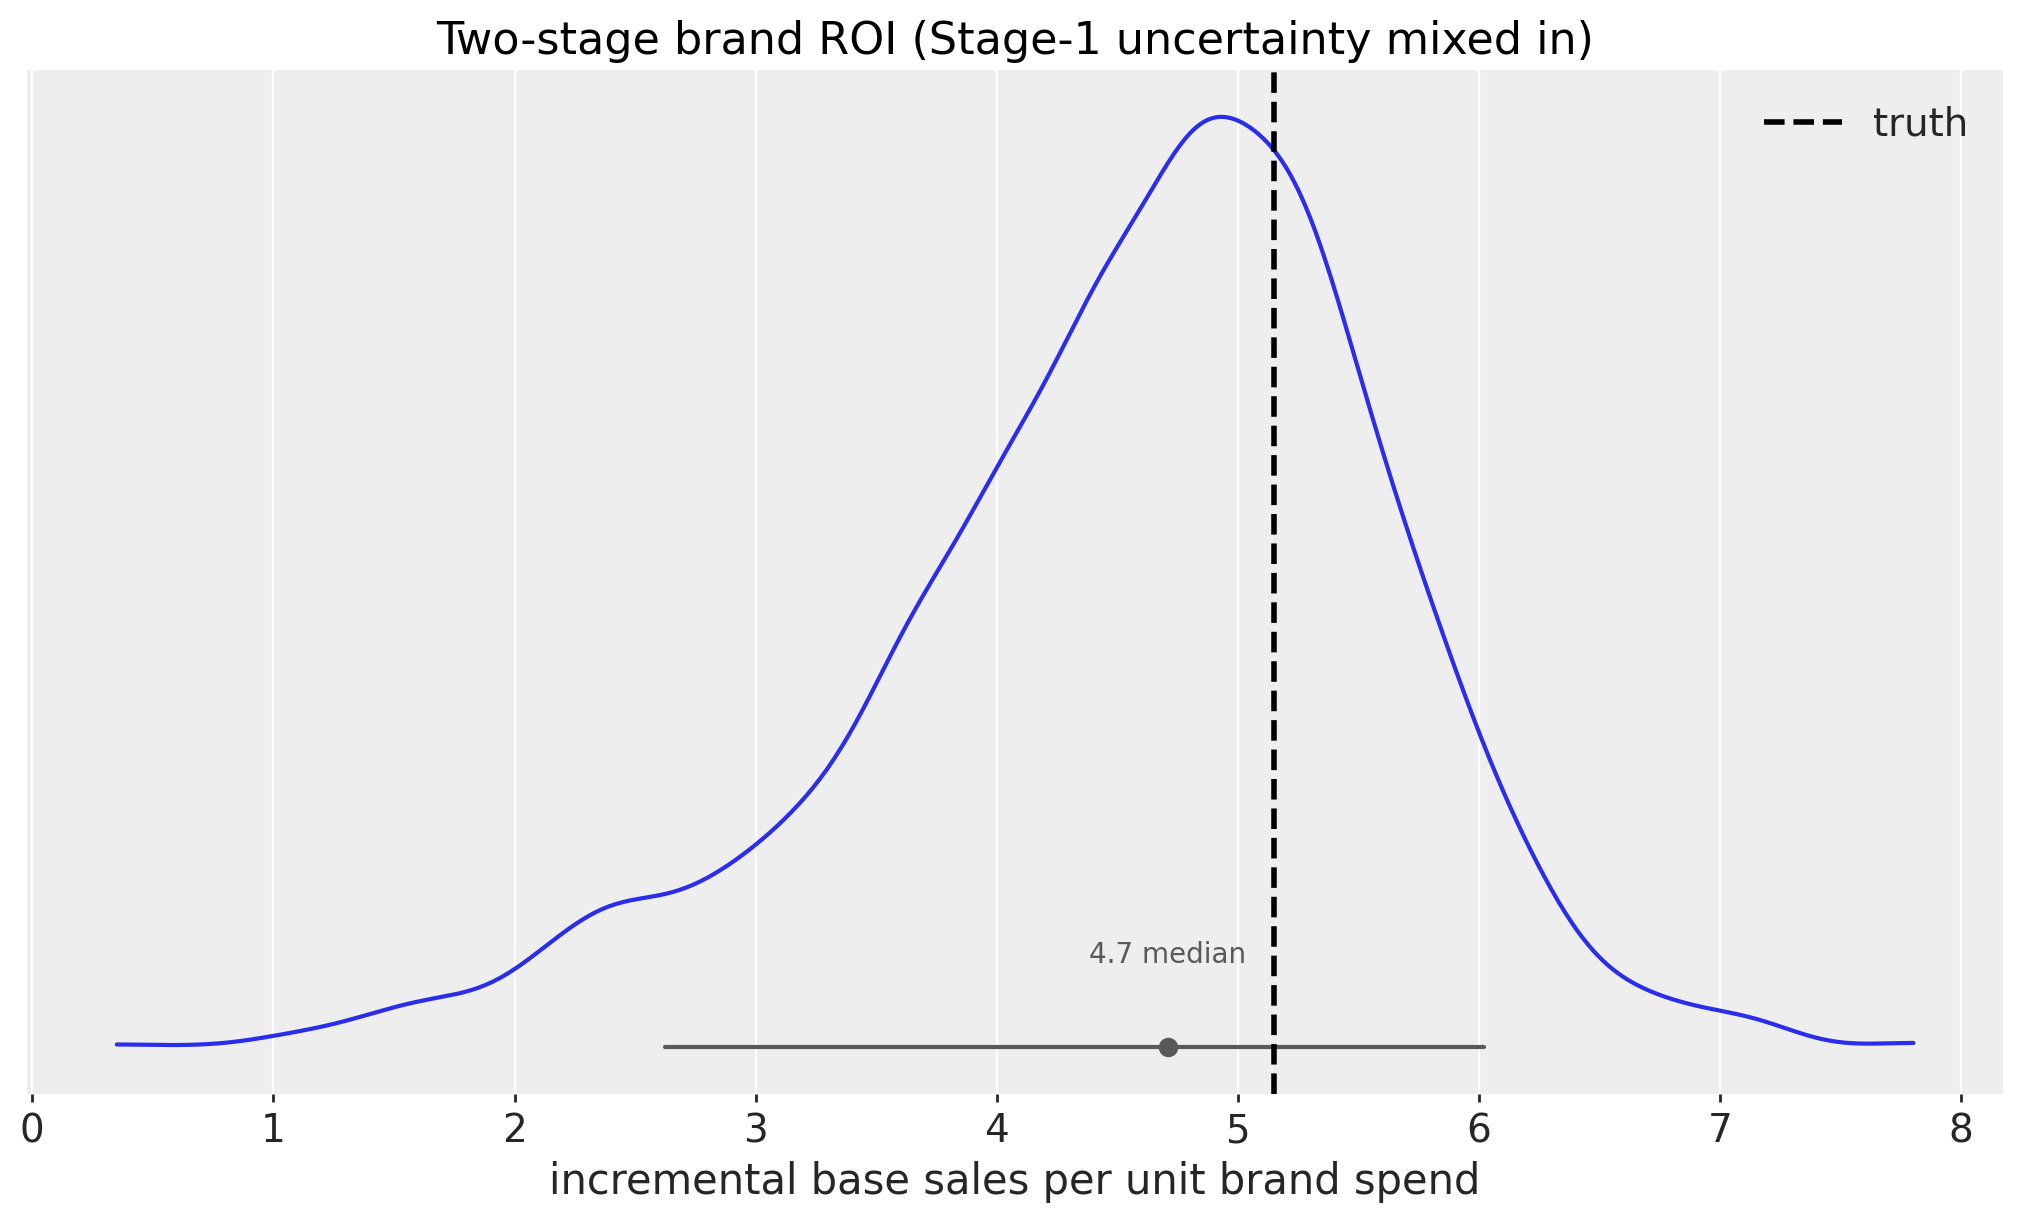

In [41]:
# Headline: the mixed posterior, which carries both Stage-1 and Stage-2 uncertainty.
roi_brand_draws = cum_multiplier_mixed.sel(
    response="baseline", exog="brand_spend", horizon=horizon
).drop_vars(["response", "exog", "horizon"])
roi_brand_median = float(roi_brand_draws.median())
roi_brand_hdi = az.hdi(roi_brand_draws, prob=0.94)
print(
    f"headline {horizon}-week brand ROI: median {roi_brand_median:.2f}, "
    f"94% HDI [{float(roi_brand_hdi.sel(ci_bound='lower')):.2f}, "
    f"{float(roi_brand_hdi.sel(ci_bound='upper')):.2f}] "
    f"(true {true_long_term_roi:.2f})"
)

pc = az.plot_dist(
    xr.Dataset({f"brand ROI ({horizon}-week window)": roi_brand_draws}),
    point_estimate="median",
    figure_kwargs={"figsize": (10, 6)},
)
ax = pc.viz["/"]["plot"]["brand ROI (26-week window)"].item()
ax.axvline(
    true_long_term_roi, color="black", linestyle="--", linewidth=2, label="truth"
)
ax.legend()
ax.set(
    title="Two-stage brand ROI (Stage-1 uncertainty mixed in)",
    xlabel="incremental base sales per unit brand spend",
);

For the second quantity we convolve the historical spend path with the per-horizon multiplier draws, which yields a full posterior distribution of the total in-sample uplift. The dashed line marks total brand spend, so the distance between the two is the incremental *sales* the campaigns bought over and above their own cost within the attribution window. Read that as a revenue comparison rather than a profit one: turning it into a payback statement also needs the gross margin on the incremental sales, which our simulation does not model.

in-sample brand uplift within 26 weeks: median 150.1 ($10k), 94% HDI [74.1, 200.9], against total brand spend 31.9


[Text(0.5, 1.0, 'In-sample brand uplift within the 26-week window')]

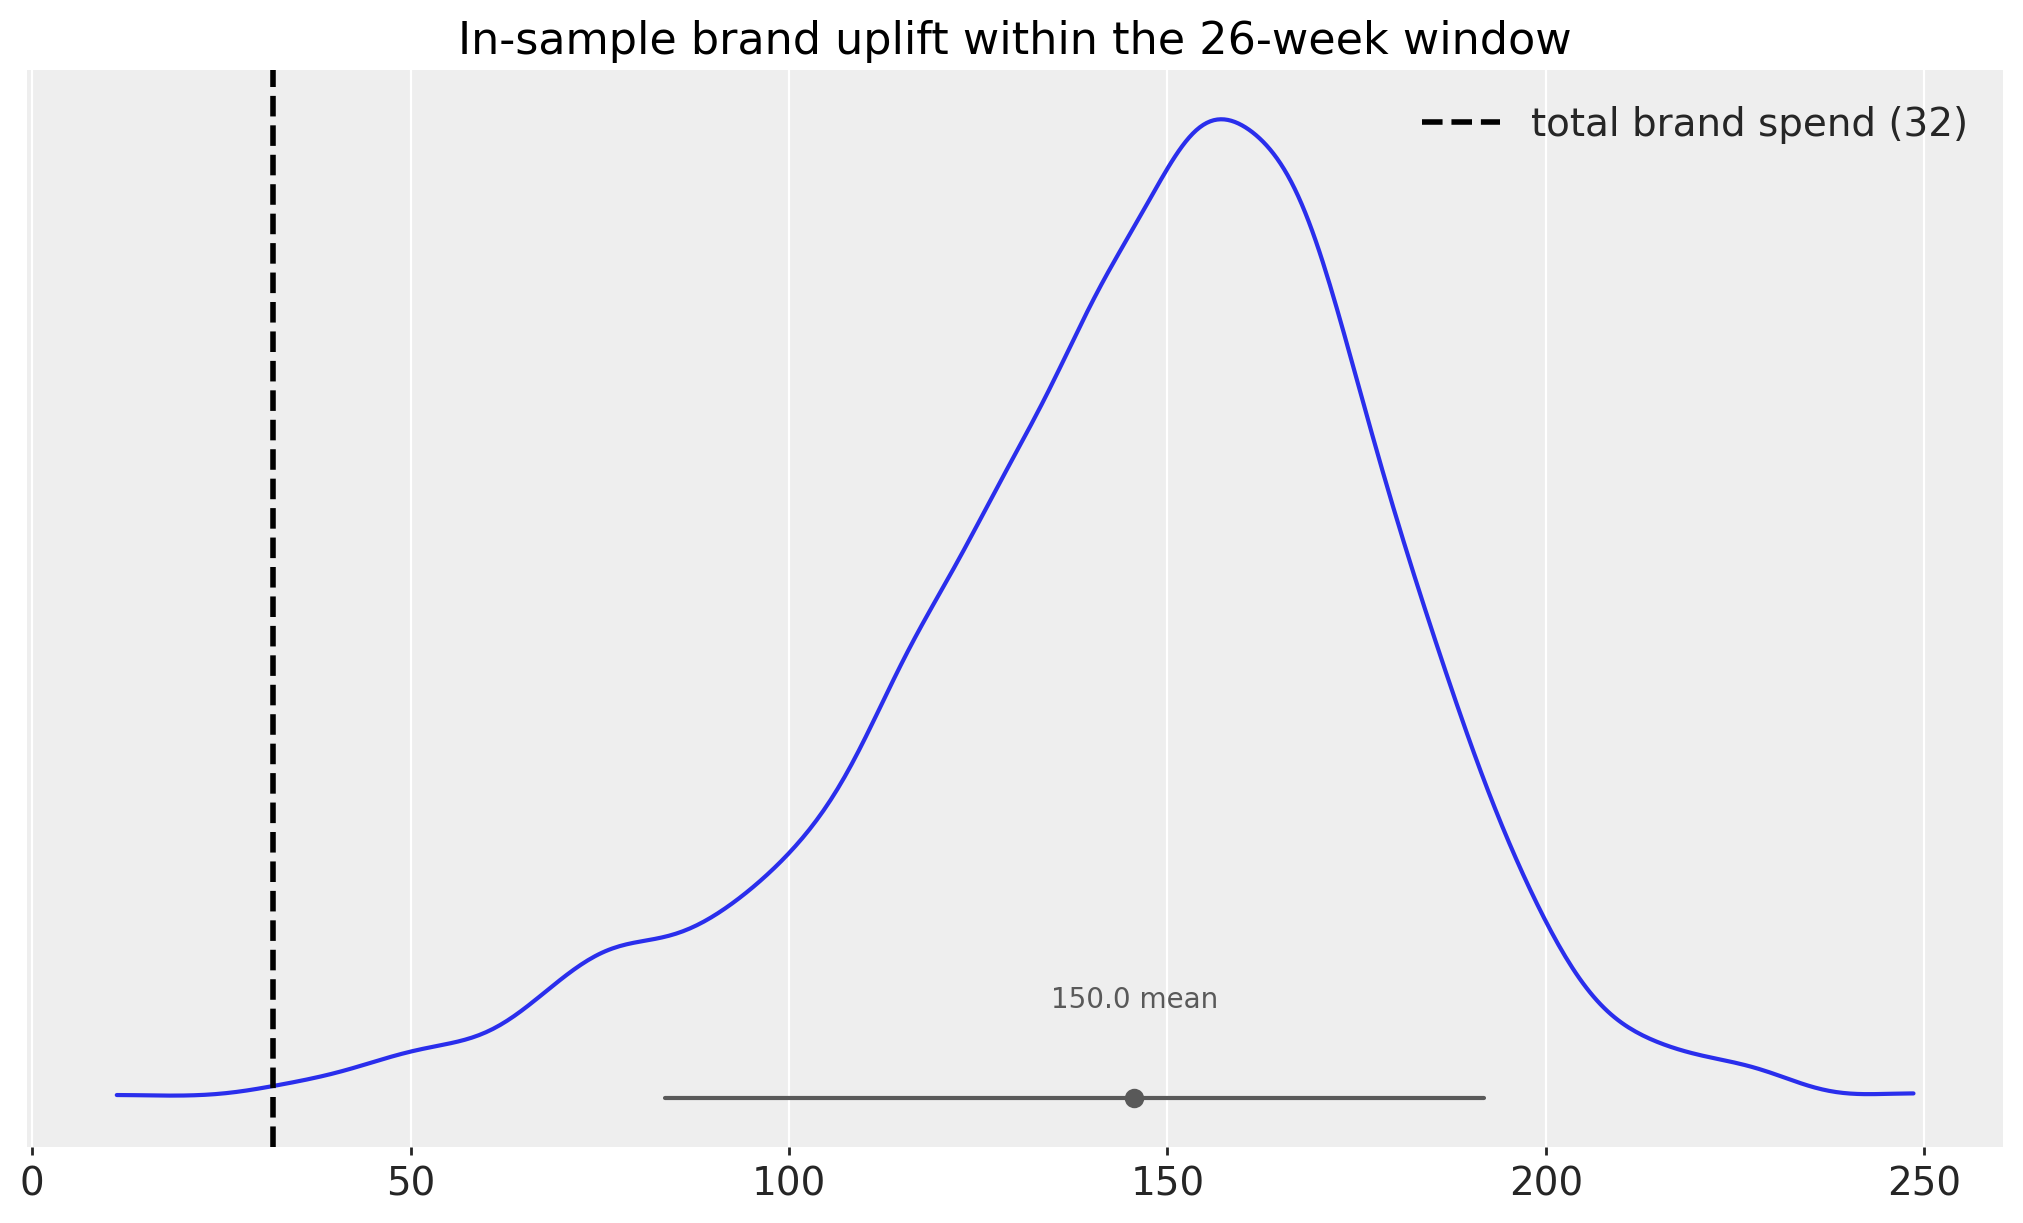

In [42]:
theta_base = theta_mixed.sel(response="baseline", exog="brand_spend").values

spend_path = df["brand_spend"].to_numpy()
brand_contribution_draws = np.zeros((*theta_base.shape[:2], n_obs))
for h in range(horizon + 1):
    brand_contribution_draws[:, :, h:] += (
        theta_base[:, :, h][:, :, None] * spend_path[None, None, : n_obs - h]
    )

brand_contribution = xr.DataArray(
    brand_contribution_draws,
    dims=("chain", "draw", "date"),
    coords={"date": df["date"]},
    name="brand_contribution",
)
brand_contribution_median = brand_contribution.median(dim=("chain", "draw"))

total_uplift_draws = brand_contribution.sum("date")
total_brand_uplift = float(total_uplift_draws.median())
total_brand_spend = float(spend_path.sum())
uplift_hdi = az.hdi(total_uplift_draws, prob=0.94)
print(
    f"in-sample brand uplift within {horizon} weeks: median "
    f"{total_brand_uplift:.1f} ($10k), 94% HDI "
    f"[{float(uplift_hdi.sel(ci_bound='lower')):.1f}, "
    f"{float(uplift_hdi.sel(ci_bound='upper')):.1f}], against total brand spend "
    f"{total_brand_spend:.1f}"
)

pc = az.plot_dist(
    xr.Dataset({"in-sample brand uplift ($10k)": total_uplift_draws}),
    figure_kwargs={"figsize": (10, 6)},
)
ax = pc.viz["plot"]["in-sample brand uplift ($10k)"].item()
ax.axvline(
    total_brand_spend,
    color="black",
    linestyle="--",
    linewidth=2,
    label=f"total brand spend ({total_brand_spend:.0f})",
)
ax.legend()
ax.set(title=f"In-sample brand uplift within the {horizon}-week window")

The punchline figure compares the two views of ROI for every spend line, with the true values as black diamonds. Each diamond sits at the *estimand of its own row*: for the performance channels both models target the same short-term ROI, so their diamonds line up and the intervals land on them (for `x2` the truth sits at the lower edge of both). For brand the two rows answer different questions: the naive row estimates the direct short-term effect (true value zero, marked on the naive row) while the two-stage row estimates the 26-week dynamic multiplier (true value $5.15$, marked on the two-stage row). Marking each row against its own truth avoids the misleading impression that the naive model is badly estimating the long-term effect it never set out to measure.

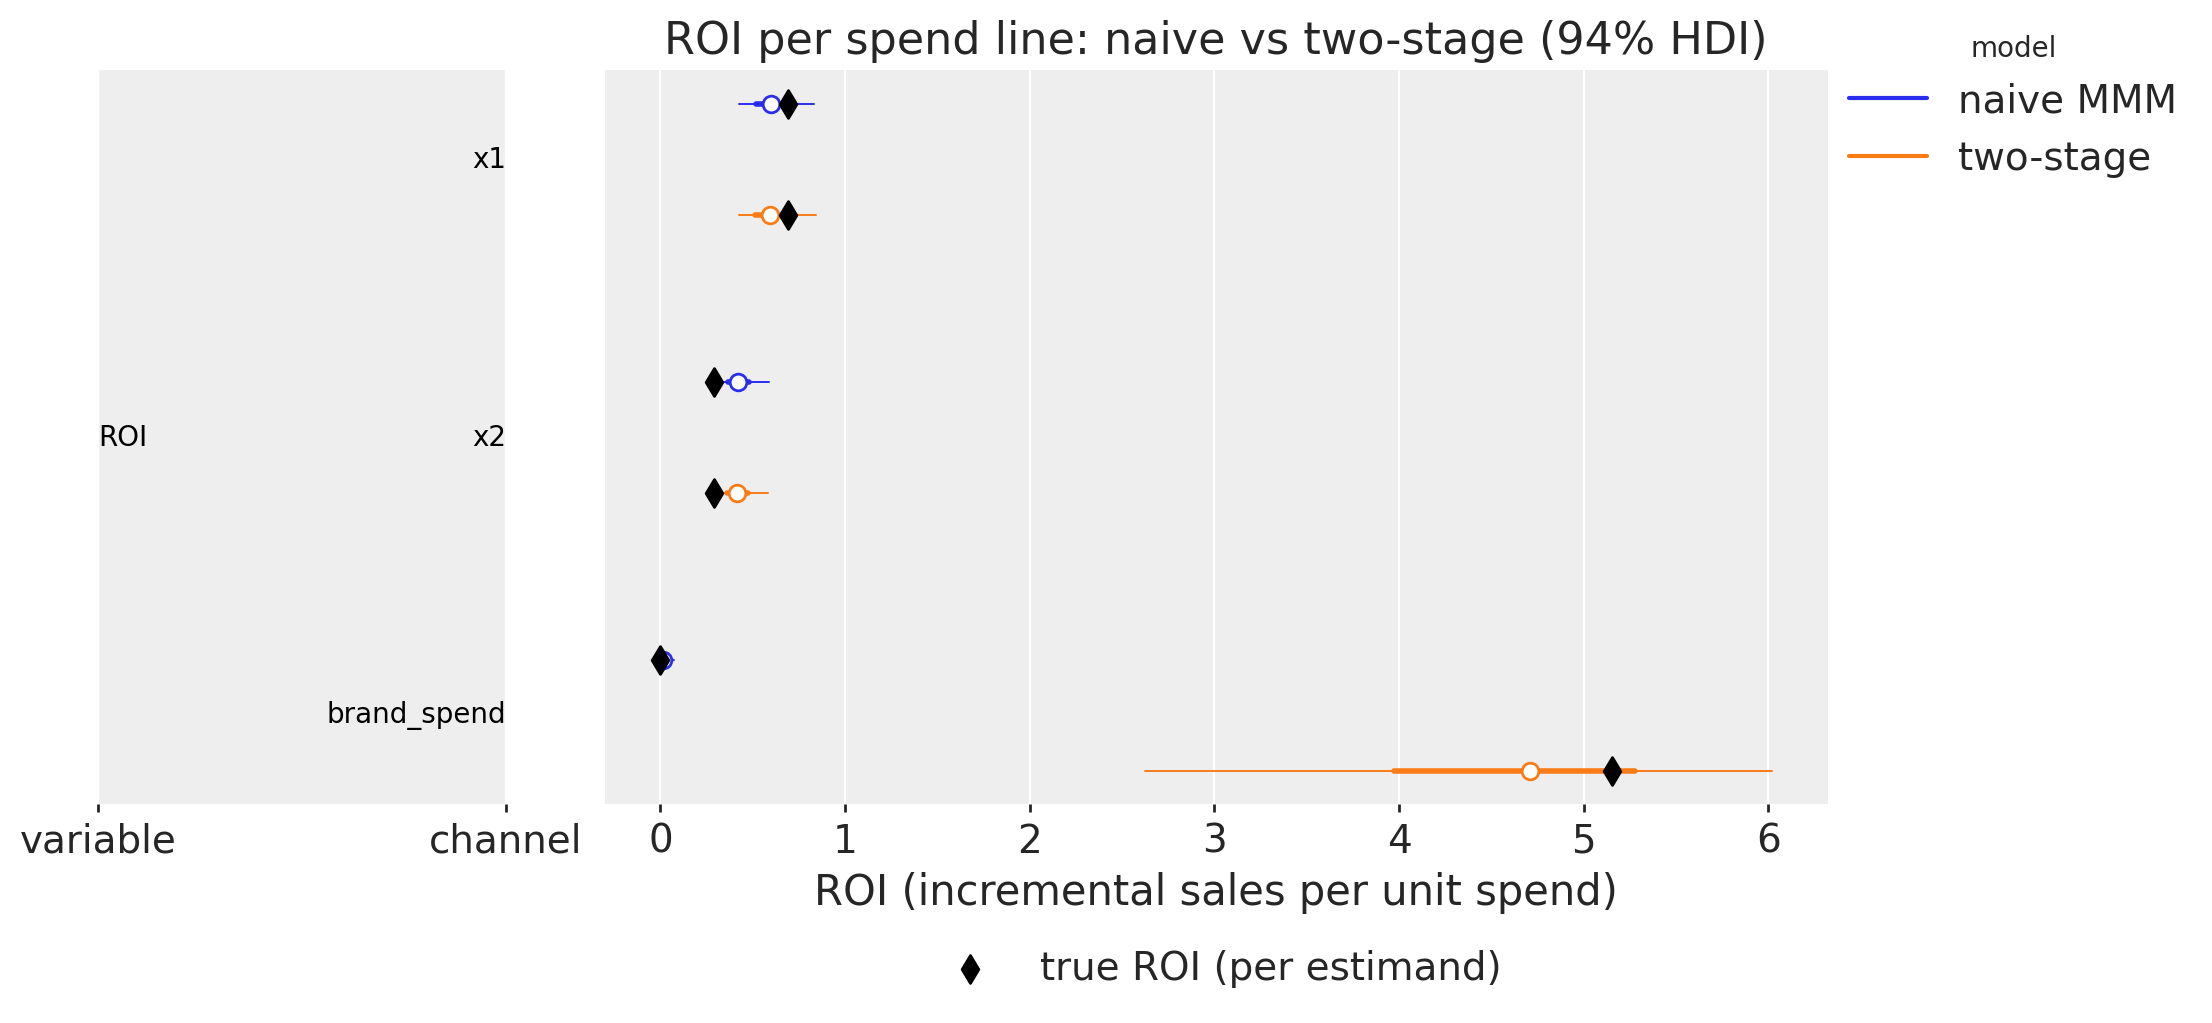

In [43]:
roi_two_stage = xr.concat(
    [roi_stage1, roi_brand_draws.expand_dims(channel=["brand_spend"])],
    dim="channel",
)
roi_compare = xr.concat([roi_naive, roi_two_stage], dim="model").assign_coords(
    model=["naive MMM", "two-stage"]
)
dt = xr.DataTree.from_dict(
    {"/posterior": xr.DataTree(xr.Dataset({"ROI": roi_compare}))}
)

pc = az.plot_forest(
    dt, combined=True, point_estimate="median", figure_kwargs={"figsize": (11, 5)}
)
pc.add_legend("model")
ax = pc.viz["/"]["plot"].sel(column="forest").item()
# The two models estimate different estimands for brand: the naive model targets
# the direct short-term effect (true value 0), the two-stage model the 26-week
# multiplier (true value `true_long_term_roi`). For the performance channels both
# models target the same short-term ROI. So we mark a truth diamond per (channel,
# model) at that model's own estimand rather than one shared diamond per row.
true_roi_by_model = {
    "x1": {"naive MMM": true_roi_x1, "two-stage": true_roi_x1},
    "x2": {"naive MMM": true_roi_x2, "two-stage": true_roi_x2},
    "brand_spend": {"naive MMM": 0.0, "two-stage": true_long_term_roi},
}
first_diamond = True
for channel in naive_channels:
    pe = pc.viz["point_estimate"]["ROI"].sel(channel=channel)
    for model in roi_compare["model"].values:
        y_pos = pe.sel(model=model).item().get_offsets()[0, 1]
        ax.scatter(
            true_roi_by_model[channel][model],
            y_pos,
            color="black",
            marker="d",
            s=50,
            zorder=5,
            label="true ROI (per estimand)" if first_diamond else None,
        )
        first_diamond = False
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=1)
ax.set(
    title="ROI per spend line: naive vs two-stage (94% HDI)",
    xlabel="ROI (incremental sales per unit spend)",
);

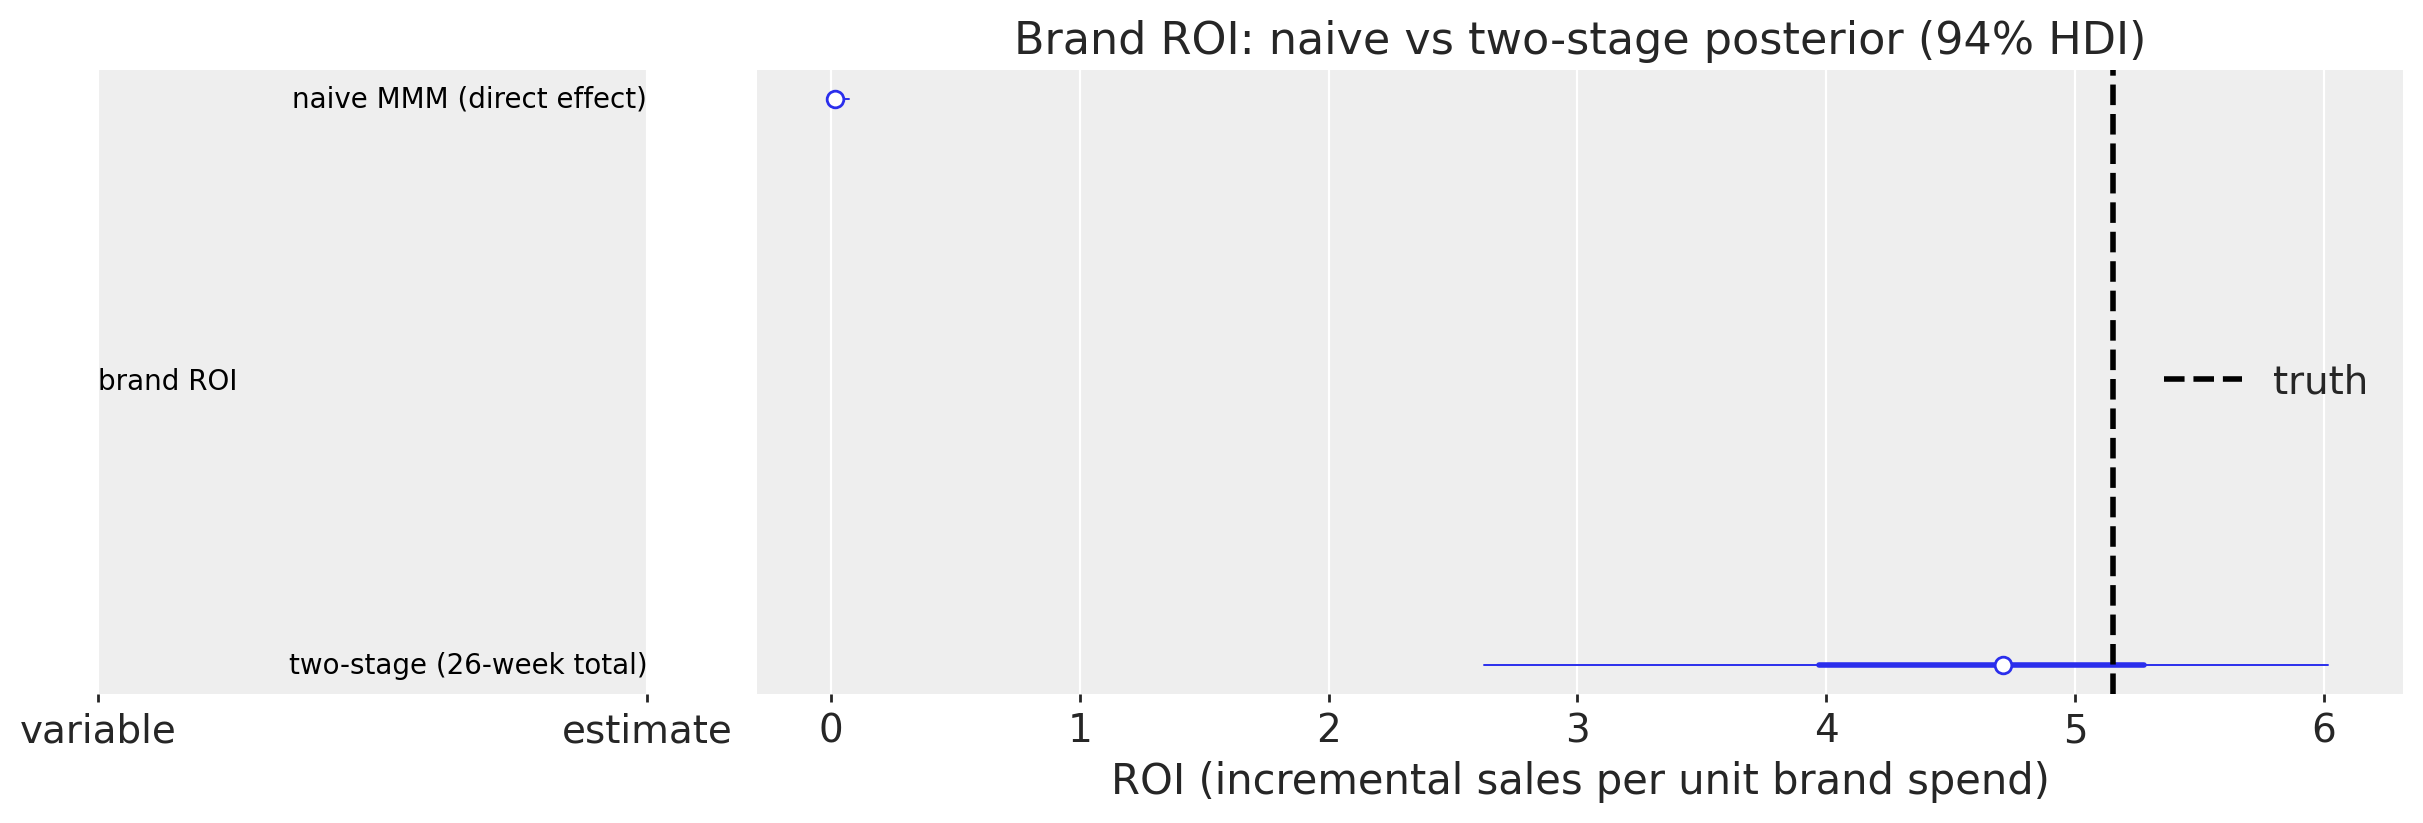

In [44]:
naive_brand_draws = roi_naive.sel(channel="brand_spend").drop_vars("channel")

brand_roi_compare = xr.concat(
    [naive_brand_draws, roi_brand_draws], dim="estimate"
).assign_coords(estimate=["naive MMM (direct effect)", "two-stage (26-week total)"])

pc = az.plot_forest(
    xr.Dataset({"brand ROI": brand_roi_compare}),
    combined=True,
    point_estimate="median",
    figure_kwargs={"figsize": (12, 4)},
)
ax = pc.viz["/"]["plot"].sel(column="forest").item()
ax.axvline(
    true_long_term_roi, color="black", linestyle="--", linewidth=2, label="truth"
)
ax.legend(loc="center right")
ax.set(
    title="Brand ROI: naive vs two-stage posterior (94% HDI)",
    xlabel="ROI (incremental sales per unit brand spend)",
);

Finally, the in-sample decomposition. We stack the steady baseline (the extracted baseline minus the brand-driven part), the brand uplift, and the short-term channel contributions; the remaining gap to observed sales is seasonality plus noise. This is a *median* decomposition: each band is a per-variable posterior median, so the components are a readable visual summary rather than a draw-wise additive breakdown (medians of parts do not sum to the median of the whole).

[Text(0.5, 1.0, 'In-sample decomposition with brand-driven baseline uplift'),
 Text(0, 0.5, 'sales ($10k)')]

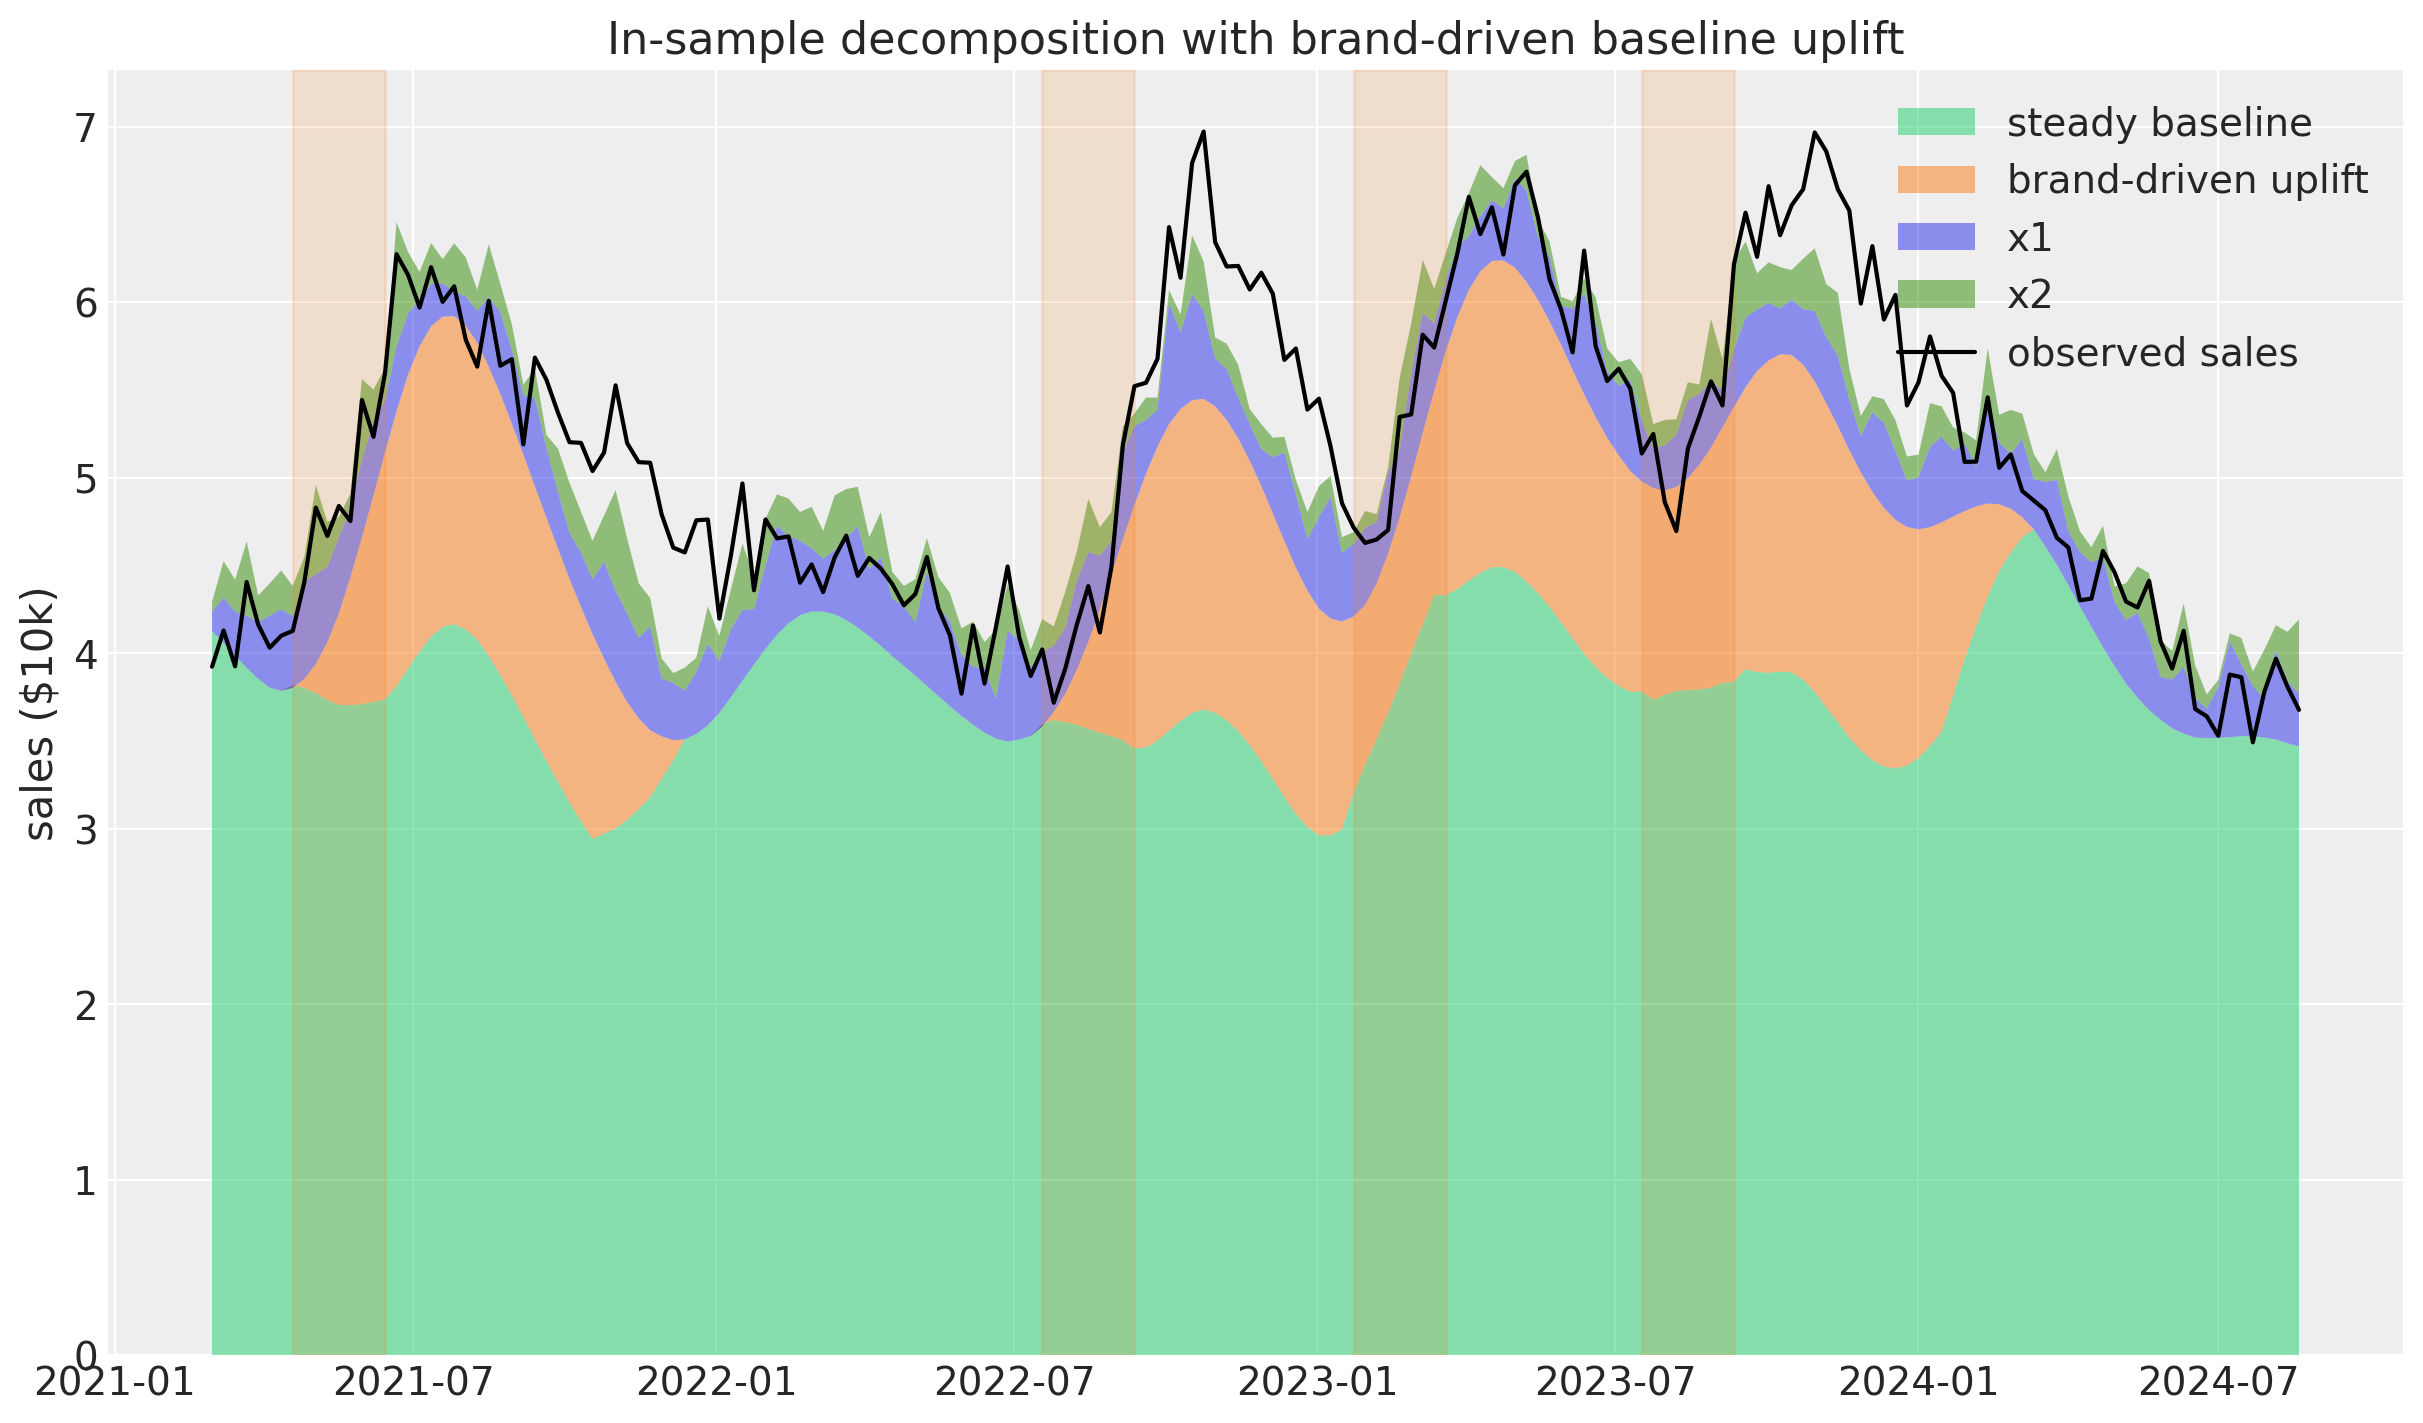

In [45]:
channel_contribution_median = (
    mmm.idata.posterior["channel_contribution_original_scale"]
    .median(dim=("chain", "draw"))
    .to_numpy()
)
steady_baseline = baseline_median.to_numpy() - brand_contribution_median.to_numpy()

components = np.vstack(
    [
        steady_baseline,
        brand_contribution_median.to_numpy(),
        channel_contribution_median[:, 0],
        channel_contribution_median[:, 1],
    ]
)

fig, ax = plt.subplots(figsize=(12, 7))
ax.stackplot(
    df["date"],
    components,
    labels=["steady baseline", "brand-driven uplift", "x1", "x2"],
    colors=["C7", "C1", "C0", "C2"],
    alpha=0.5,
)
ax.plot(df["date"], df["y"], color="black", linewidth=1.5, label="observed sales")
shade_flights(ax)
ax.legend(loc="upper right")
ax.set(
    title="In-sample decomposition with brand-driven baseline uplift",
    ylabel="sales ($10k)",
)

```{admonition} Reading the two ROI columns
:class: tip
The naive and two-stage columns answer *different questions*. The naive number is the direct short-term effect, and for brand media it is honestly close to zero. The two-stage number is the total effect transmitted through the funnel over 26 weeks. The failure mode in practice is not computing the naive number, it is *misreading* it as the total effect and cutting the brand budget accordingly.
```

## Pitfall Made Concrete: Plug-In vs Mixed Uncertainty

The headline interval already carries Stage-1 uncertainty, because we built it by mixing VARX refits across baseline draws. It is worth seeing explicitly what the shortcut would have cost. The *plug-in* multiplier from earlier (conditioned on the single median baseline) ignores Stage-1 estimation error, so its credible interval is narrower than an honest one. Below we put the two intervals side by side, and then trace the individual baseline-draw refits to show exactly where the extra width comes from.

plug-in 94% HDI width 1.95 vs mixed 3.98 (mixed is 2.0x wider)


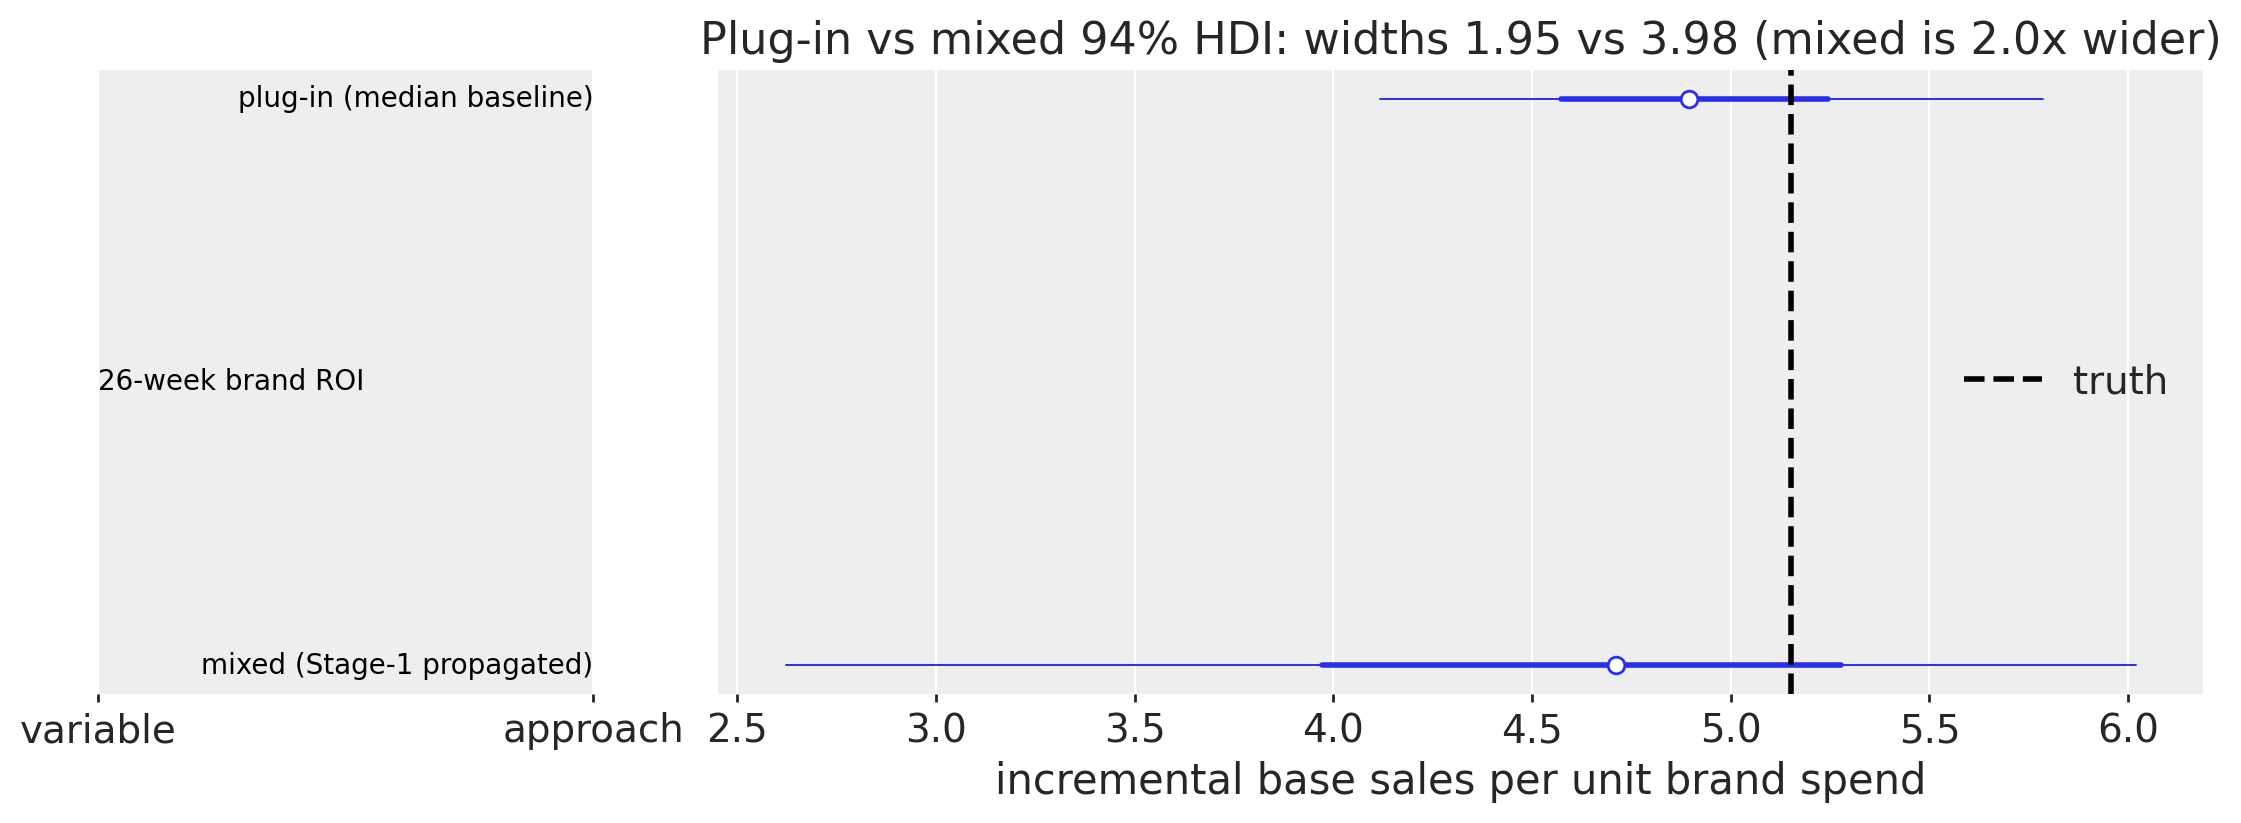

In [46]:
# Both posteriors are already computed (no refitting needed here): the plug-in
# from the single median-baseline fit, the mixed from the baseline-draw refits.
roi_brand_plugin = (
    cum_multiplier_plugin.sel(response="baseline", exog="brand_spend", horizon=horizon)
    .drop_vars(["response", "exog", "horizon"])
    .assign_coords(chain=np.arange(4), draw=np.arange(1_000))
)
plugin_hdi = az.hdi(roi_brand_plugin, prob=0.94)

roi_uncertainty = xr.concat(
    [roi_brand_plugin, roi_brand_draws], dim="approach"
).assign_coords(approach=["plug-in (median baseline)", "mixed (Stage-1 propagated)"])

pc = az.plot_forest(
    xr.Dataset({"26-week brand ROI": roi_uncertainty}),
    combined=True,
    point_estimate="median",
    figure_kwargs={"figsize": (11, 4)},
)
ax = pc.viz["/"]["plot"].sel(column="forest").item()
ax.axvline(
    true_long_term_roi, color="black", linestyle="--", linewidth=2, label="truth"
)
ax.legend(loc="center right")
plugin_width = float(
    plugin_hdi.sel(ci_bound="upper") - plugin_hdi.sel(ci_bound="lower")
)
mixed_width = float(
    roi_brand_hdi.sel(ci_bound="upper") - roi_brand_hdi.sel(ci_bound="lower")
)

print(
    f"plug-in 94% HDI width {plugin_width:.2f} vs mixed {mixed_width:.2f} "
    f"(mixed is {mixed_width / plugin_width:.1f}x wider)"
)
ax.set(
    title=(
        f"Plug-in vs mixed 94% HDI: widths {plugin_width:.2f} vs {mixed_width:.2f} "
        f"(mixed is {mixed_width / plugin_width:.1f}x wider)"
    ),
    xlabel="incremental base sales per unit brand spend",
);

The figure below traces where the extra width comes from. It overlays the plug-in cumulative-multiplier band (median line and 94% HDI, conditioned on the median Stage-1 baseline), the mixed band (Stage-1 uncertainty propagated), the median multiplier curves from each individual baseline-draw refit, and the true curve. The per-refit medians fan out beyond the narrow plug-in band and fill the wider mixed band: that fan *is* the Stage-1 contribution to uncertainty, and it is exactly what the plug-in interval leaves out.

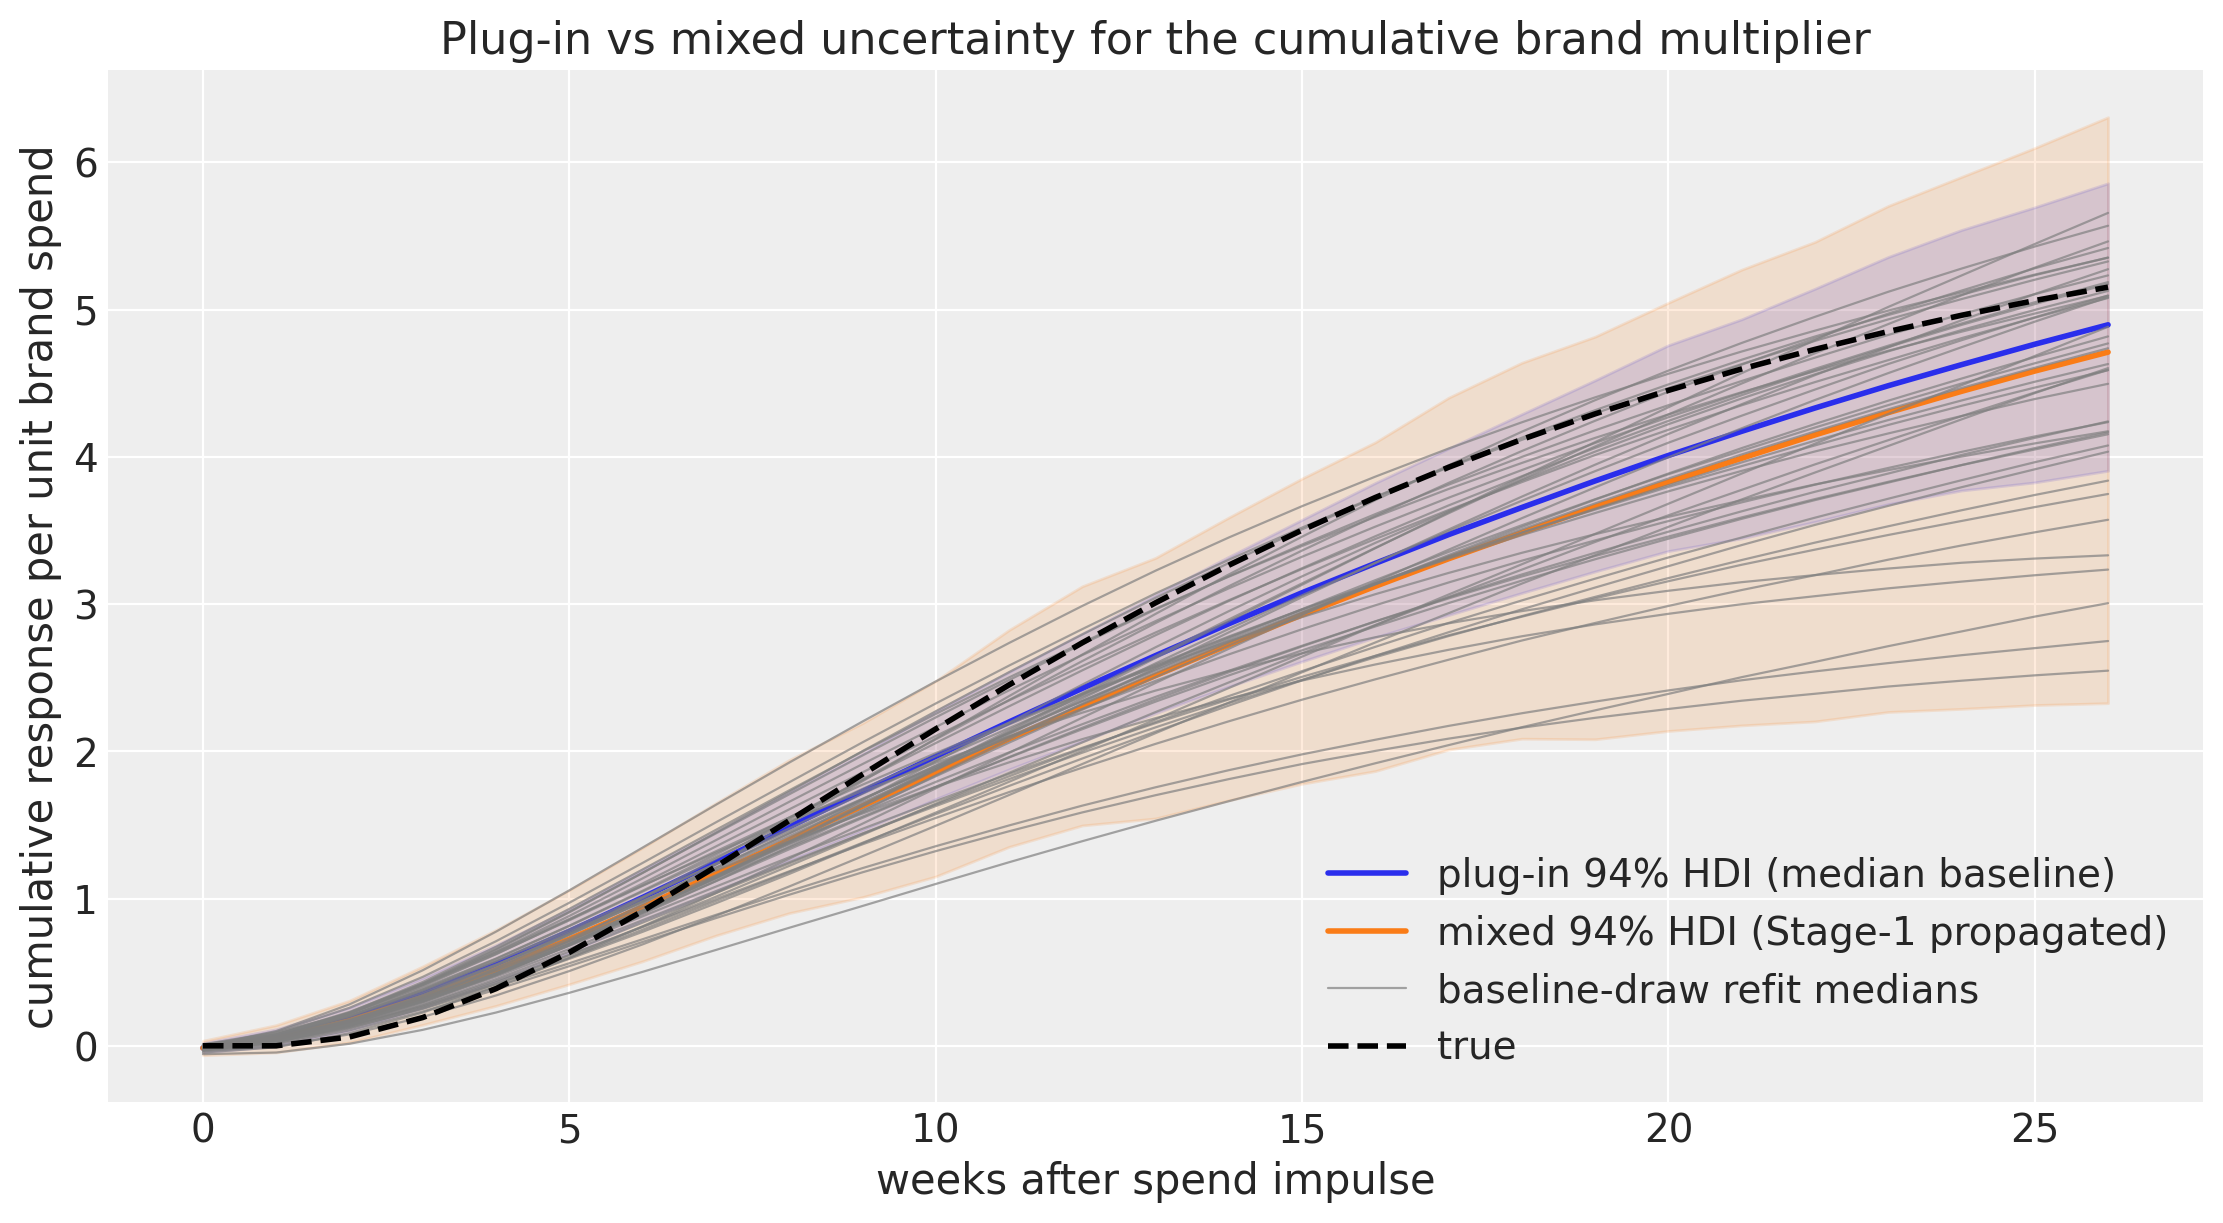

In [47]:
plugin_curve = cum_multiplier_plugin.sel(response="baseline", exog="brand_spend")
mixed_curve = cum_multiplier_mixed.sel(response="baseline", exog="brand_spend")
plugin_band = az.hdi(plugin_curve, prob=0.94)
mixed_band = az.hdi(mixed_curve, prob=0.94)

fig, ax = plt.subplots(figsize=(11, 6))
ax.fill_between(
    plugin_curve["horizon"],
    plugin_band.sel(ci_bound="lower"),
    plugin_band.sel(ci_bound="upper"),
    alpha=0.15,
    color="C0",
)
ax.plot(
    plugin_curve["horizon"],
    plugin_curve.median(dim=("chain", "draw")),
    color="C0",
    linewidth=2,
    label="plug-in 94% HDI (median baseline)",
)
ax.fill_between(
    mixed_curve["horizon"],
    mixed_band.sel(ci_bound="lower"),
    mixed_band.sel(ci_bound="upper"),
    alpha=0.15,
    color="C1",
)
ax.plot(
    mixed_curve["horizon"],
    mixed_curve.median(dim=("chain", "draw")),
    color="C1",
    linewidth=2,
    label="mixed 94% HDI (Stage-1 propagated)",
)
for i, curve in sensitivity_curves.items():
    ax.plot(
        curve["horizon"],
        curve,
        color="0.5",
        linewidth=0.8,
        alpha=0.7,
        label="baseline-draw refit medians" if i == 0 else None,
    )
ax.plot(
    np.arange(horizon + 1),
    true_curves["baseline"],
    color="black",
    linestyle="--",
    linewidth=2,
    label="true",
)
ax.legend(loc="lower right")
ax.set(
    title="Plug-in vs mixed uncertainty for the cumulative brand multiplier",
    xlabel="weeks after spend impulse",
    ylabel="cumulative response per unit brand spend",
);

The comparison makes the cost of the shortcut concrete: the mixed 94% interval is markedly wider than the plug-in one (the two widths and their ratio are printed with the figure), and the individual baseline-draw refit medians fan out across the mixed band rather than sitting inside the plug-in one. The qualitative conclusion is unchanged (a large, positive long-run brand multiplier, with the truth inside the interval), but the honest headline is the wider *mixed* interval we reported, and quoting the plug-in interval instead would overstate precision by ignoring Stage-1 error. When even the mixed interval is not enough (heavier Stage-1 uncertainty, or feedback between the stages), the next step is a joint model in which the funnel equations and the MMM are estimated together (see {ref}`mmm_funnel_mueffect` for a step in that direction).

## Assumptions, Caveats, and Extensions

- **Mediation completeness.** The workflow credits brand only through the measured mindset metrics and the baseline. If brand marketing works through additional unmeasured paths, the total effect is underestimated. Choose tracking metrics that cover the funnel your category actually has.
- **Exogeneity of brand spend.** The causal reading of the dynamic multiplier requires that flights do not respond to weekly demand or awareness shocks. Annual planning calendars usually satisfy this; performance-triggered brand boosts would not, and would require identification arguments beyond this notebook.
- **The baseline is a residual.** Anything omitted from Stage 1 (price, distribution, promotions, competitor actions) lands in the baseline. If such a driver correlates with the flight calendar, the VARX will misattribute it to brand. Include known drivers as controls in Stage 1 or as variables in Stage 2.
- **Unit roots and cointegration.** With genuinely integrated series, the levels VAR should be replaced (or at least cross-checked) with a VECM as in Cain (2022). The stationarity checks in the appendix are the guardrail.
- **Calibration.** Brand lift studies (search or survey lift) can anchor the spend-to-awareness link, in the same spirit as the sales lift tests of {ref}`mmm_lift_test`.

### Key Takeaways

1. A standard MMM estimates the *direct short-term* effect of brand media, which is typically near zero. That number is correct and, on its own, misleading.
2. A time-varying intercept turns the MMM baseline from a nuisance into a measurable quantity that contains the accumulated brand effect.
3. A Bayesian VARX on {baseline, brand metrics} with brand spend exogenous recovers the long-run transmission with full posterior uncertainty, and needs no structural identification for the planner-set spend input.
4. Report the horizon convention explicitly, and decompose in-sample sales by convolving the spend path with the multiplier rather than multiplying total spend by the truncated cumulative multiplier. The two coincide only when every flight has a full window of runway before the sample ends, as they happen to here.
5. Two-stage inference understates uncertainty if you plug in a Stage-1 point estimate; propagate it by mixing VARX refits across Stage-1 baseline draws (as the headline here does) and report that wider interval.

### References

- Cain, P. M. (2022). "Modelling short- and long-term marketing effects in the consumer purchase journey." *International Journal of Research in Marketing*, 39(1), 96-116.
- O'Sullivan, R. (2025). [Capturing the long-term causal effect of brand marketing](https://medium.com/@raz1470/capturing-the-long-term-causal-effect-of-brand-marketing-bc577621a627).
- Oulton, N. / 1749.io. [Measuring Marketing Effectiveness Over the Long-Term](https://1749.io/learn/f/measuring-marketing-effectiveness-over-the-long-term).
- Dekimpe, M. G., & Hanssens, D. M. (1999). "Sustained spending and persistent response: A new look at long-term marketing profitability." *Journal of Marketing Research*, 36(4), 397-412.

## Appendix: Stationarity Diagnostics for the VARX

The Stage-2 specification hinges on a question the main flow deferred: **are these series stationary?** The tests below run on the `varx_df` frame and the `endog_vars` list assembled in the Stage-2 preparation section.

A VAR in levels assumes the system fluctuates around a stable mean to which it eventually reverts. If instead the series are *integrated* (they contain a unit root, so shocks never die out), a levels regression among them can produce arbitrarily high $R^2$ and significant coefficients between series that are causally unrelated (the classic *spurious regression* problem) unless the series are cointegrated, in which case the right tool is a vector error correction model (VECM). Since the long-run multiplier we are after is built entirely from level relationships, getting this diagnosis wrong either invalidates the estimate (spurious levels VAR) or throws the estimand away (differencing). We therefore run three complementary tests.

**Unit-root pretests, jointly.** Two complementary tests do the per-series work, and they mirror each other. The *augmented Dickey-Fuller* (ADF) test takes non-stationarity as its null: it regresses the differenced series on its lagged level and lagged differences, and a statistic far enough below the critical value rejects the unit root, declaring the series stationary. *KPSS* reverses the burden of proof, taking stationarity as its null, so there a *large* statistic is the evidence of a unit root. Run together they give a two-by-two verdict grid: ADF rejects and KPSS does not means confidently stationary; ADF fails to reject and KPSS rejects means confidently integrated; both rejecting, or neither, means the sample is too short or the series too persistent for a clean verdict, which is the most common outcome with three or four years of weekly marketing data.

That bookkeeping is exactly what `integration_order` does. It runs both tests at each differencing level $d = 0, 1, \ldots$, stops for a series once the joint verdict comes back stationary, and reports a `joint_status` per level together with `d_max`, the highest integration order found across the series. That single number is what the levels-VAR decision actually turns on. One weakness survives the wrapper and matters here: against *persistent-but-stationary* alternatives (autoregressive roots near one, exactly what a brand funnel produces) ADF has notoriously low power in short samples, so a failure to reject is weak evidence of a unit root.

In [48]:
integration = integration_order(varx_df, variables=endog_vars)
print(
    f"d_max = {integration.d_max}, inconclusive: {integration.inconclusive or 'none'}"
)
integration.table

d_max = 1, inconclusive: none


adf_stat  adf_pvalue  adf_lags  adf_reject  kpss_stat  \
variable      d                                                          
baseline      0 -1.615897    0.474881         6       False   0.207791   
              1 -4.102946    0.000958         5        True   0.092214   
awareness     0 -2.396891    0.142616        12       False   0.149520   
              1 -5.495557    0.000002        13        True   0.070449   
consideration 0 -2.058936    0.261344         9       False   0.174994   
              1 -4.805085    0.000053         8        True   0.113926   

                 kpss_pvalue  kpss_lags  kpss_reject  kpss_pvalue_bounded  \
variable      d                                                             
baseline      0          0.1          9        False                 True   
              1          0.1          8        False                 True   
awareness     0          0.1          9        False                 True   
              1          0.1          7        False                 True   
consideration 0          0.1          9        False                 True   
              1          0.1          8        False                 True   

                 joint_status  
variable      d                
baseline      0  inconclusive  
              1    stationary  
awareness     0  inconclusive  
              1    stationary  
consideration 0  inconclusive  
              1    stationary

**Johansen cointegration test.** While ADF and KPSS interrogate each series on its own, the Johansen trace test looks at the *system*: it estimates the cointegration rank $r$, the number of independent stationary linear combinations of the three series. The table reports a sequence of nested hypotheses ($r \le 0$, $r \le 1$, $r \le 2$); read it top-down and stop at the first hypothesis you cannot reject. Rank 0 with integrated series means no stable level relationships (a levels VAR would be spurious); an intermediate rank means cointegration (fit a VECM); rejecting at *every* rank means the system is full-rank stationary, and a **VAR in levels** is directly valid.

In [49]:
johansen_test(varx_df[endog_vars]).table

,trace_stat,trace_crit,trace_reject,maxeig_stat,maxeig_crit,maxeig_reject
r,,,,,,
0,224.287842,29.7961,True,151.954186,21.1314,True
1,72.333656,15.4943,True,62.035468,14.2639,True
2,10.298188,3.8415,True,10.298188,3.8415,True


The verdicts are mixed, and that is realistic. Every series in our simulation is stationary by construction (all autoregressive roots are below one), yet at $d = 0$ the `joint_status` column reads `inconclusive` for all three: ADF fails to reject a unit root, KPSS fails to reject stationarity, and we land squarely in the ambiguous cell of the grid above. ADF only rejects after one difference, so the reported `d_max` is 1. Read that as a statement about the tests rather than about the data. ADF drives the stopping rule and has little power against persistent-but-stationary series in a three-and-a-half-year sample, so `d_max = 1` is what the procedure returns when it cannot see mean reversion we know is there; and the ADF regression is in any case misspecified for series driven by an exogenous input like the flight schedule. KPSS, for its part, is not marginal: every statistic sits well below its 10% critical value, and `kpss_pvalue_bounded` marks the reported $0.10$ as the top of the tabulated range, so the true p-value is at least that.

The empty `inconclusive` list is not a clean bill of health either. It flags only variables still non-stationary at `max_order`, or where the two tests actively *conflict* at the level the search stopped on. A level that is `inconclusive` because neither test rejects never reaches it. The ambiguity lives in the `joint_status` column, which is why the table is worth reading rather than just its headline order.

The Johansen test breaks the tie: it rejects at every rank, which means the system is best treated as full-rank stationary, so a **VAR in levels** is directly appropriate. It is worth being honest that Johansen is not a clean referee either, since we run it on the endogenous columns alone and it therefore inherits the same omitted-exogenous-input misspecification we just held against ADF. It agrees with what we know to be true of the simulation, which is reassuring but not independent evidence.

With real data, expect this ambiguity to be the rule. If the tests do point to integrated series linked by a cointegrating relationship, the textbook answer is a vector error correction model (VECM), which is exactly the road Cain (2022) takes; impulso does not currently ship a VECM, and a levels VAR with a Minnesota prior (which shrinks toward random-walk behavior) is a common pragmatic substitute under high persistence. What you should *not* do is difference the series, since differencing destroys the level relationships that the long-run multiplier is made of.


In [50]:
%load_ext watermark
%watermark -n -u -v -iv -w -p pymc_marketing,impulso

Last updated: Wed, 05 Aug 2026

Python implementation: CPython
Python version       : 3.14.2
IPython version      : 9.15.0

pymc_marketing: 1.0.0.dev0
impulso       : 0.0.12

arviz         : 1.2.0
graphviz      : 0.21
impulso       : 0.0.12
matplotlib    : 3.10.9
numpy         : 2.4.6
pandas        : 2.3.3
pymc          : 6.0.1
pymc_extras   : 0.12.2.dev1+gee8cc37df
pymc_marketing: 1.0.0.dev0
pytensor      : 3.0.7
tqdm          : 4.68.4
xarray        : 2026.4.0

Watermark: 2.6.0

